# Demographic summary statistics

This notebook summarizes five key respondent profile variables from the raw survey export:

- age range
- region
- gender
- current career level
- years as a professional designer

Best-practice notes used here:

- keep the original raw file untouched
- validate that required columns exist before analysis
- standardize obvious label inconsistencies before summarizing categories
- parse the `years as a professional designer` field conservatively and document heuristic conversions
- report missingness alongside summary statistics

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.options.display.float_format = "{:,.2f}".format

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)
raw["Timestamp"] = pd.to_datetime(raw["Timestamp"], errors="coerce")

COLUMN_MAP = {
    "Select the age range that applies": "age",
    "In what region do you currently live / work?": "region",
    "What gender do you identify with?": "gender",
    "What career level best describes your current position?": "career_level",
    "How many years have you been a professional designer? (regardless of career level)": "years_professional_raw",
}

missing_columns = [column for column in COLUMN_MAP if column not in raw.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

survey = raw[list(COLUMN_MAP)].rename(columns=COLUMN_MAP).copy()

MISSING_TOKENS = {"", "n/a", "na", "none", "-", "prefer not to say"}

for column in ["age", "region", "gender", "career_level"]:
    survey[column] = survey[column].astype("string").str.strip()
    survey[column] = survey[column].mask(survey[column].str.lower().isin(MISSING_TOKENS))

survey["region"] = survey["region"].replace(
    {
        "Australia / Pacific Islands": "Australia / NZ / Pacific Islands",
    }
)
survey["gender"] = survey["gender"].replace({"Non binary": "Non-binary"})

age_order = ["24-35", "36-45", "46-55", "56-65", "65+"]
survey["age"] = pd.Categorical(survey["age"], categories=age_order, ordered=True)


def parse_years_professional(value, reference_timestamp=None):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in MISSING_TOKENS:
        return np.nan

    # Handle entries such as "Since 1999" using the response timestamp as context.
    since_match = re.search(r"since\s+(\d{4})", text)
    if since_match and pd.notna(reference_timestamp):
        elapsed_years = reference_timestamp.year - int(since_match.group(1))
        if elapsed_years >= 0:
            return float(elapsed_years)

    total_years = 0.0
    found_component = False

    component_patterns = [
        (r"(\d+(?:\.\d+)?)\s*(?:\+)?\s*(?:years?|yrs?|yr|tears?)\b", 1),
        (r"(\d+(?:\.\d+)?)\s*(?:months?|mos?|mo)\b", 12),
        (r"(\d+(?:\.\d+)?)\s*(?:weeks?|wks?|wk)\b", 52),
        (r"(\d+(?:\.\d+)?)\s*(?:days?)\b", 365.25),
    ]

    for pattern, denominator in component_patterns:
        matches = re.findall(pattern, text)
        if matches:
            found_component = True
            total_years += sum(float(match) for match in matches) / denominator

    if found_component:
        return total_years

    if "less than a year" in text:
        return 0.5
    if text == "new":
        return 0.0

    number_match = re.search(r"\d+(?:\.\d+)?", text)
    if number_match:
        return float(number_match.group())

    return np.nan


survey["years_professional"] = [
    parse_years_professional(value, timestamp)
    for value, timestamp in zip(survey["years_professional_raw"], raw["Timestamp"])
]


def classify_career_level(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in MISSING_TOKENS:
        return np.nan

    consulting_keywords = ["founder", "partner", "consulting", "consultant", "advisor", "mentor", "freelance", "independent"]
    chief_keywords = ["chief", "cdo", "head of"]
    vp_keywords = ["vp", "svp", "vice president"]
    manager_keywords = ["manager", "managing"]
    ic_keywords = ["staff", "principal", "ic", "individual contributor", "lead designer", "designer", "student", "uxr", "researcher"]

    if any(keyword in text for keyword in consulting_keywords):
        return "Consulting / founder"
    if any(keyword in text for keyword in chief_keywords):
        return "CDO / chief"
    if any(keyword in text for keyword in vp_keywords):
        return "VP"
    if "director" in text:
        return "Director"
    if any(keyword in text for keyword in manager_keywords):
        return "Manager"
    if any(keyword in text for keyword in ic_keywords):
        return "IC"
    return "Other / hybrid"


career_level_group_order = [
    "IC",
    "Manager",
    "Director",
    "VP",
    "CDO / chief",
    "Consulting / founder",
    "Other / hybrid",
]

survey["career_level_group"] = survey["career_level"].apply(classify_career_level)

survey.head()

,age,region,gender,career_level,years_professional_raw,years_professional,career_level_group
0,24-35,Africa,Male,Staff level designer,5,5.00,IC
1,36-45,Asia,Female,Creative Director (consulting / design services),16,16.00,Consulting / founder
2,36-45,Asia,Male,Senior IC / Principal designer,18,18.00,IC
3,36-45,Asia,Female,Senior IC / Principal designer,13,13.00,IC
4,46-55,Asia,Male,Director level designer,22,22.00,Director


In [2]:
def summarize_categorical(series, sort_by_count=False):
    summary = (
        series.value_counts(dropna=False)
        .rename_axis(series.name)
        .reset_index(name="count")
    )
    summary["percent"] = (summary["count"] / len(series) * 100).round(1)
    if sort_by_count:
        summary = summary.sort_values(["count", series.name], ascending=[False, True], na_position="last")
    return summary.reset_index(drop=True)


age_summary = summarize_categorical(survey["age"], sort_by_count=False)
region_summary = summarize_categorical(survey["region"], sort_by_count=True)
gender_summary = summarize_categorical(survey["gender"], sort_by_count=True)
career_level_summary = summarize_categorical(survey["career_level"], sort_by_count=True)
career_level_group_summary = (
    summarize_categorical(survey["career_level_group"], sort_by_count=False)
    .set_index("career_level_group")
    .reindex(career_level_group_order)
    .reset_index()
    .fillna({"count": 0, "percent": 0.0})
)

years = survey["years_professional"]
years_summary = pd.DataFrame(
    {
        "statistic": [
            "n",
            "missing",
            "mean",
            "median",
            "std",
            "min",
            "q1",
            "q3",
            "iqr",
            "max",
        ],
        "value": [
            years.notna().sum(),
            years.isna().sum(),
            years.mean(),
            years.median(),
            years.std(),
            years.min(),
            years.quantile(0.25),
            years.quantile(0.75),
            years.quantile(0.75) - years.quantile(0.25),
            years.max(),
        ],
    }
)

missingness_summary = (
    survey[["age", "region", "gender", "career_level", "years_professional"]]
    .isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missingness_summary["missing_percent"] = (
    missingness_summary["missing_count"] / len(survey) * 100
).round(1)

heuristic_years_rows = survey[
    survey["years_professional_raw"].astype("string").str.contains(
        r"since|\+|month|week|day|less than|new",
        case=False,
        regex=True,
        na=False,
    )
][["years_professional_raw", "years_professional"]].drop_duplicates()

display(Markdown("## Missingness check"))
display(missingness_summary)

display(Markdown("## Age summary"))
display(age_summary)

display(Markdown("## Region summary"))
display(region_summary)

display(Markdown("## Gender summary"))
display(gender_summary)

display(Markdown("## Current career level summary"))
display(career_level_summary)

display(Markdown("## Grouped career level taxonomy"))
display(career_level_group_summary)

display(Markdown("## Years as a professional designer"))
display(years_summary)

display(Markdown("## Heuristic year conversions reviewed"))
display(heuristic_years_rows)

print(f"Total survey responses: {len(survey)}")

## Missingness check

,variable,missing_count,missing_percent
0,age,0,0.00
1,region,0,0.00
2,gender,0,0.00
3,career_level,0,0.00
4,years_professional,0,0.00


## Age summary

,age,count,percent
0,46-55,54,45.40
1,36-45,42,35.30
2,24-35,11,9.20
3,56-65,11,9.20
4,65+,1,0.80


## Region summary

...

## Years as a professional designer

,statistic,value
0,n,119.00
1,missing,0.00
2,mean,21.13
3,median,21.00
4,std,7.27
5,min,4.00
6,q1,15.00
7,q3,27.00
8,iqr,12.00
9,max,35.00


## Heuristic year conversions reviewed

,years_professional_raw,years_professional
36,30+,30.00
115,Since 1999,27.00


Total survey responses: 119


## Visual summaries

The charts below use the cleaned respondent-profile fields created above.

Visualization choices:

- age is shown in its natural ordinal order rather than sorted by frequency
- region and gender are displayed as percentages to make category sizes directly comparable
- raw career titles are preserved in the summary table, but the chart uses a grouped taxonomy for a more stable analytic view
- years as a professional designer is shown with both a histogram and a boxplot to communicate center, spread, and potential skew

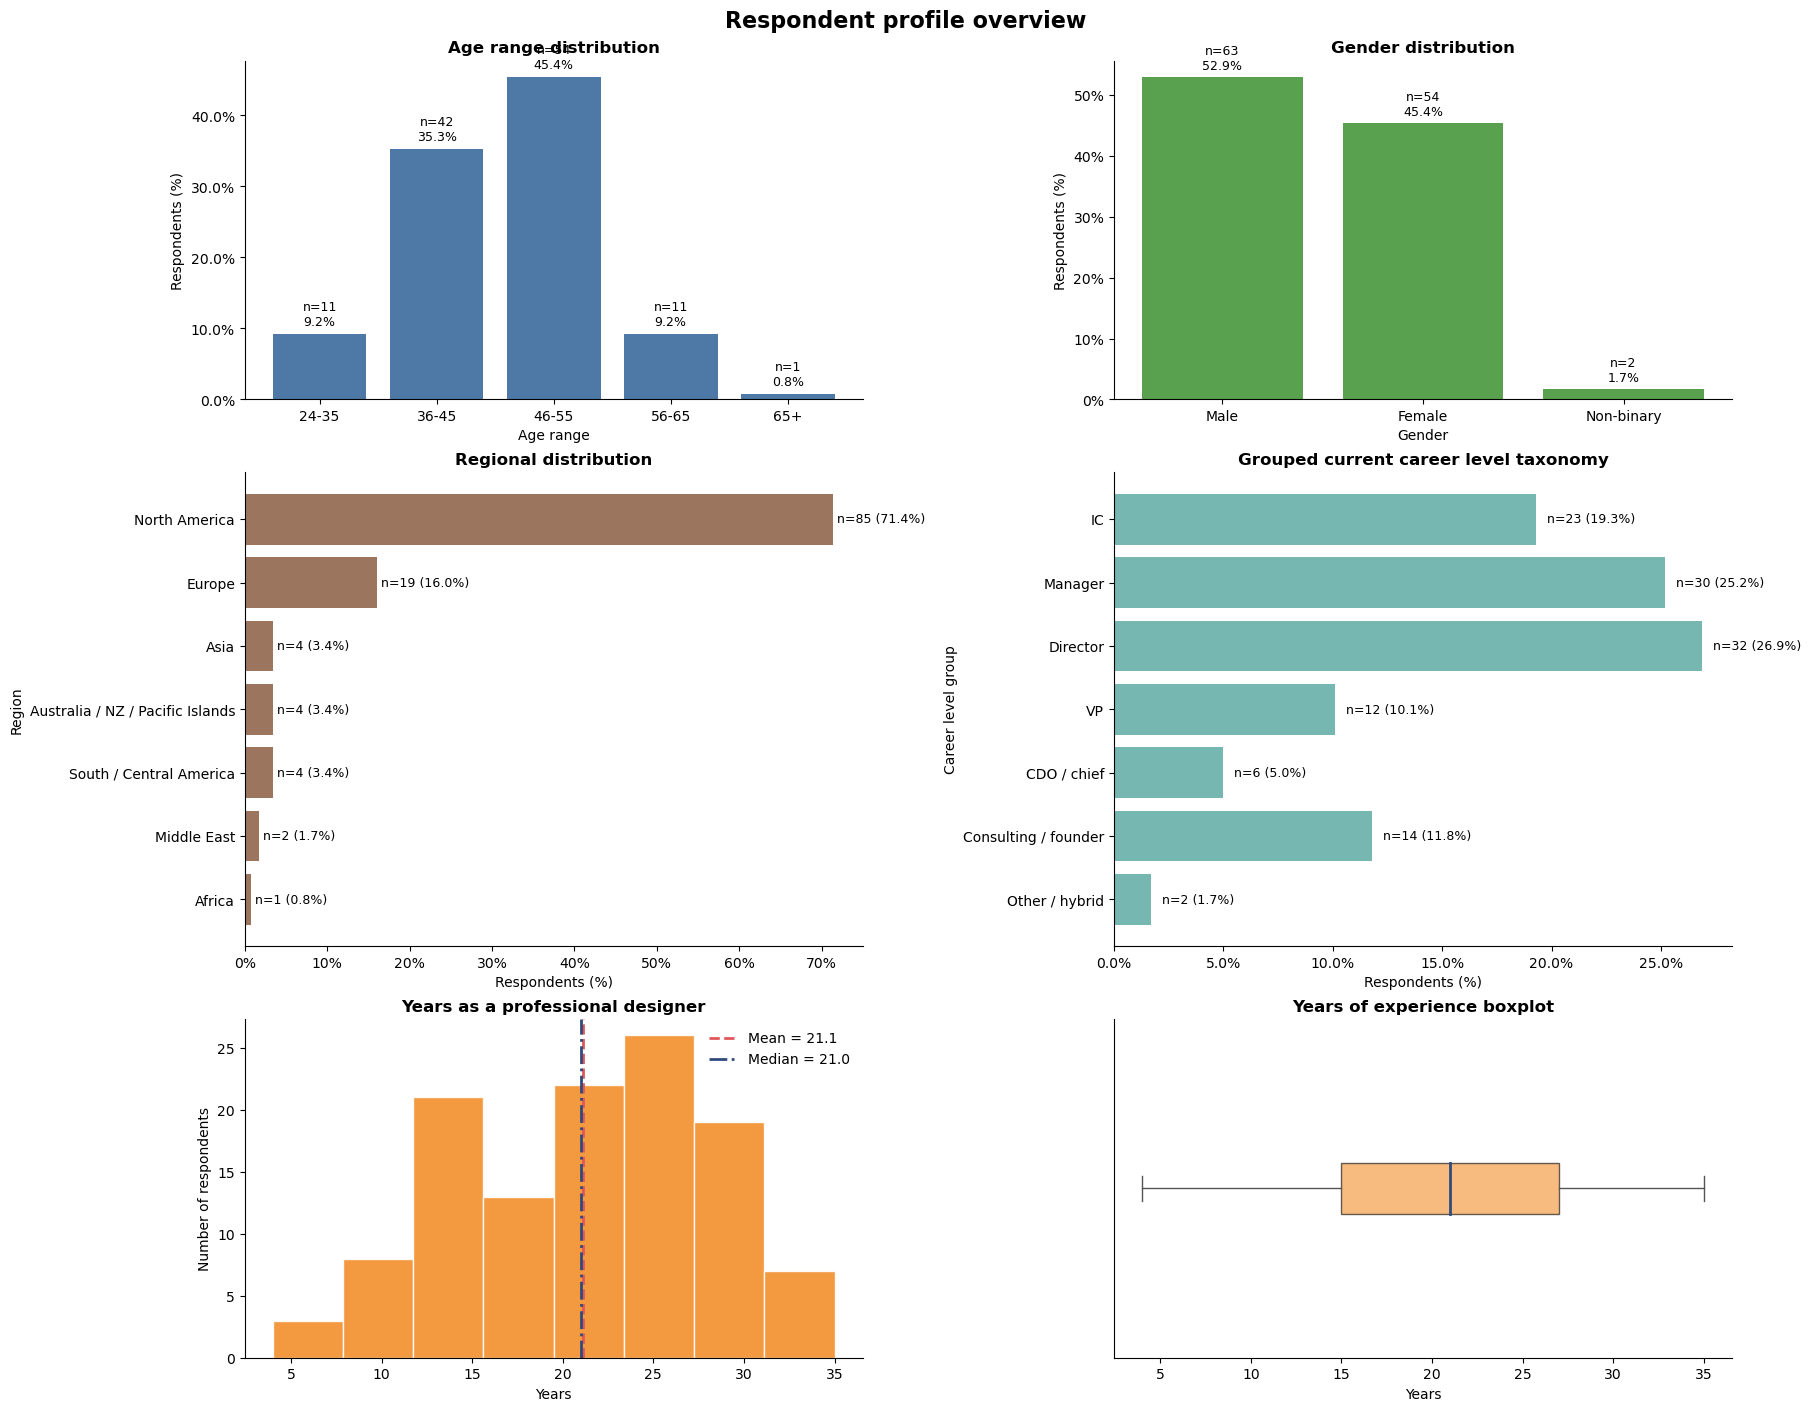

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update(
    {
        "figure.figsize": (14, 10),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 12,
        "axes.labelsize": 10,
    }
)


def annotate_vertical_bars(ax, counts, percents):
    for patch, count, percent in zip(ax.patches, counts, percents):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 0.8,
            f"n={int(count)}\n{percent:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )


def annotate_horizontal_bars(ax, counts, percents):
    for patch, count, percent in zip(ax.patches, counts, percents):
        ax.text(
            patch.get_width() + 0.5,
            patch.get_y() + patch.get_height() / 2,
            f"n={int(count)} ({percent:.1f}%)",
            ha="left",
            va="center",
            fontsize=9,
        )


age_plot = (
    age_summary.set_index("age")
    .reindex(age_order)
    .reset_index()
)

region_plot = region_summary.copy()
gender_plot = gender_summary.copy()
career_plot = career_level_group_summary.copy()
years_plot = survey["years_professional"].dropna()

fig = plt.figure(constrained_layout=True, figsize=(18, 14))
grid = fig.add_gridspec(3, 2, height_ratios=[1, 1.4, 1])

ax_age = fig.add_subplot(grid[0, 0])
ax_gender = fig.add_subplot(grid[0, 1])
ax_region = fig.add_subplot(grid[1, 0])
ax_career = fig.add_subplot(grid[1, 1])
ax_hist = fig.add_subplot(grid[2, 0])
ax_box = fig.add_subplot(grid[2, 1])

age_color = "#4E79A7"
gender_color = "#59A14F"
region_color = "#9C755F"
career_color = "#76B7B2"
years_color = "#F28E2B"

ax_age.bar(age_plot["age"].astype(str), age_plot["percent"], color=age_color)
ax_age.set_title("Age range distribution")
ax_age.set_xlabel("Age range")
ax_age.set_ylabel("Respondents (%)")
ax_age.yaxis.set_major_formatter(PercentFormatter())
annotate_vertical_bars(ax_age, age_plot["count"], age_plot["percent"])

ax_gender.bar(gender_plot["gender"], gender_plot["percent"], color=gender_color)
ax_gender.set_title("Gender distribution")
ax_gender.set_xlabel("Gender")
ax_gender.set_ylabel("Respondents (%)")
ax_gender.yaxis.set_major_formatter(PercentFormatter())
annotate_vertical_bars(ax_gender, gender_plot["count"], gender_plot["percent"])

ax_region.barh(region_plot["region"], region_plot["percent"], color=region_color)
ax_region.invert_yaxis()
ax_region.set_title("Regional distribution")
ax_region.set_xlabel("Respondents (%)")
ax_region.set_ylabel("Region")
ax_region.xaxis.set_major_formatter(PercentFormatter())
annotate_horizontal_bars(ax_region, region_plot["count"], region_plot["percent"])

ax_career.barh(career_plot["career_level_group"], career_plot["percent"], color=career_color)
ax_career.invert_yaxis()
ax_career.set_title("Grouped current career level taxonomy")
ax_career.set_xlabel("Respondents (%)")
ax_career.set_ylabel("Career level group")
ax_career.xaxis.set_major_formatter(PercentFormatter())
annotate_horizontal_bars(ax_career, career_plot["count"], career_plot["percent"])

ax_hist.hist(years_plot, bins="auto", color=years_color, edgecolor="white", alpha=0.9)
ax_hist.axvline(years_plot.mean(), color="#E15759", linestyle="--", linewidth=2, label=f"Mean = {years_plot.mean():.1f}")
ax_hist.axvline(years_plot.median(), color="#2F4B7C", linestyle="-.", linewidth=2, label=f"Median = {years_plot.median():.1f}")
ax_hist.set_title("Years as a professional designer")
ax_hist.set_xlabel("Years")
ax_hist.set_ylabel("Number of respondents")
ax_hist.legend(frameon=False)

ax_box.boxplot(
    years_plot,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": years_color, "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
)
ax_box.set_title("Years of experience boxplot")
ax_box.set_xlabel("Years")
ax_box.set_yticks([])

fig.suptitle("Respondent profile overview", fontsize=16, fontweight="bold")
plt.show()

## Years in the profession by career level

This view compares `years_professional` across the grouped career-level taxonomy.

Why this chart type:

- boxplots show median, spread, and potential outliers for each career-level group
- jittered points make the underlying sample distribution visible instead of hiding all respondents inside summary statistics
- each category is annotated with sample size so small groups are easy to interpret cautiously

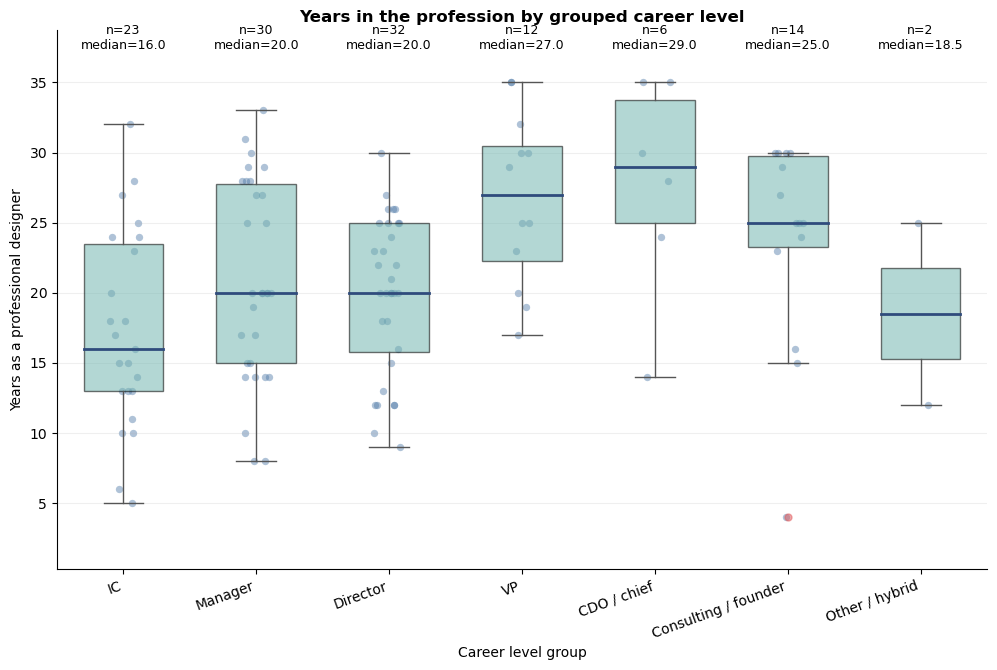

In [4]:
career_years_plot = survey[["career_level_group", "years_professional"]].dropna().copy()
career_years_plot["career_level_group"] = pd.Categorical(
    career_years_plot["career_level_group"],
    categories=career_level_group_order,
    ordered=True,
)
career_years_plot = career_years_plot.sort_values("career_level_group")

career_years_groups = [
    career_years_plot.loc[
        career_years_plot["career_level_group"] == group,
        "years_professional",
    ].to_numpy()
    for group in career_level_group_order
]

career_years_groups = [group for group in career_years_groups if len(group) > 0]
career_year_labels = [
    group for group in career_level_group_order
    if (career_years_plot["career_level_group"] == group).sum() > 0
]
career_year_counts = [len(group) for group in career_years_groups]
career_year_medians = [float(np.median(group)) for group in career_years_groups]

fig, ax = plt.subplots(figsize=(12, 7))
positions = np.arange(1, len(career_years_groups) + 1)

box = ax.boxplot(
    career_years_groups,
    positions=positions,
    patch_artist=True,
    widths=0.6,
    boxprops={"facecolor": "#76B7B2", "alpha": 0.55},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={"marker": "o", "markerfacecolor": "#E15759", "markeredgecolor": "#E15759", "alpha": 0.5, "markersize": 5},
)

rng = np.random.default_rng(42)
for position, values in zip(positions, career_years_groups):
    jitter = rng.uniform(-0.12, 0.12, size=len(values))
    ax.scatter(
        np.full(len(values), position) + jitter,
        values,
        color="#4E79A7",
        alpha=0.45,
        s=28,
        linewidths=0,
    )

for position, count, median in zip(positions, career_year_counts, career_year_medians):
    ax.text(
        position,
        ax.get_ylim()[1] + 0.6,
        f"n={count}\nmedian={median:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Years in the profession by grouped career level")
ax.set_xlabel("Career level group")
ax.set_ylabel("Years as a professional designer")
ax.set_xticks(positions)
ax.set_xticklabels(career_year_labels, rotation=20, ha="right")
ax.grid(axis="y", alpha=0.2)
ax.margins(y=0.12)

plt.show()

## Years until first formal leadership vs. VP/CDO status

Because `VP/CDO` is a binary outcome, a simple scatterplot is not the most informative approach. This block uses:

- a distribution comparison of `years_to_first_leadership` for `VP/CDO` versus everyone else
- a point-biserial correlation, which is the appropriate correlation coefficient for one continuous variable and one binary variable
- a Mann-Whitney U test as a non-parametric robustness check

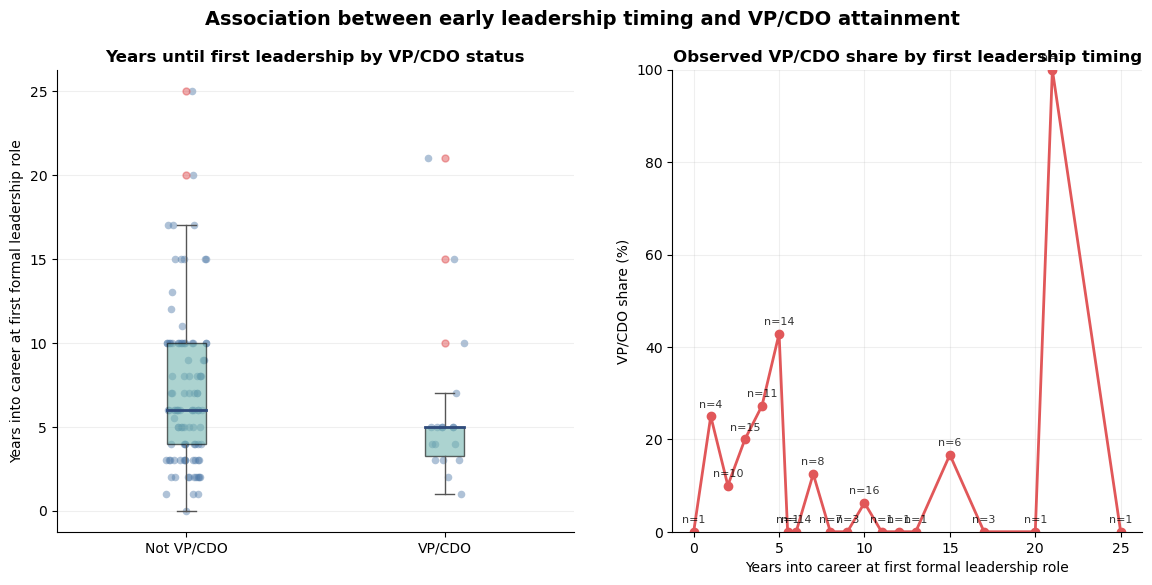

### Group comparison summary

,is_vp_cdo,count,mean,median,std,min,max
0,Not VP/CDO,101,7.00,6.00,4.51,0.00,25.00
1,VP/CDO,18,5.94,5.00,4.90,1.00,21.00


Point-biserial correlation: -0.083
Point-biserial p-value: 0.367
Mann-Whitney result: U = 710.5, p = 0.140


In [5]:
FIRST_LEADERSHIP_COL = (
    "How many years into your career did you first hold a formal design leadership role? "
    "(i.e. managing people or leading a project/initiative)"
)

vp_cdo_analysis = survey.copy()
vp_cdo_analysis["years_to_first_leadership"] = pd.to_numeric(
    raw[FIRST_LEADERSHIP_COL], errors="coerce"
)
vp_cdo_analysis["is_vp_cdo"] = vp_cdo_analysis["career_level_group"].isin(
    ["VP", "CDO / chief"]
)
vp_cdo_analysis = vp_cdo_analysis.dropna(subset=["years_to_first_leadership", "career_level_group"])

comparison_summary = (
    vp_cdo_analysis.groupby("is_vp_cdo")["years_to_first_leadership"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={False: "Not VP/CDO", True: "VP/CDO"})
    .reset_index()
)

point_biserial_corr = vp_cdo_analysis["years_to_first_leadership"].corr(
    vp_cdo_analysis["is_vp_cdo"].astype(int)
)

p_value_text = "Not computed"
mann_whitney_text = "Not computed"
try:
    from scipy.stats import mannwhitneyu, pointbiserialr

    pb_result = pointbiserialr(
        vp_cdo_analysis["is_vp_cdo"].astype(int),
        vp_cdo_analysis["years_to_first_leadership"],
    )
    mw_result = mannwhitneyu(
        vp_cdo_analysis.loc[
            vp_cdo_analysis["is_vp_cdo"],
            "years_to_first_leadership",
        ],
        vp_cdo_analysis.loc[
            ~vp_cdo_analysis["is_vp_cdo"],
            "years_to_first_leadership",
        ],
        alternative="two-sided",
    )
    p_value_text = f"{pb_result.pvalue:.3f}"
    mann_whitney_text = f"U = {mw_result.statistic:.1f}, p = {mw_result.pvalue:.3f}"
except Exception:
    pass

plot_df = vp_cdo_analysis.copy()
plot_df["group_label"] = plot_df["is_vp_cdo"].map(
    {False: "Not VP/CDO", True: "VP/CDO"}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.1, 1]})

box_groups = [
    plot_df.loc[plot_df["group_label"] == label, "years_to_first_leadership"].to_numpy()
    for label in ["Not VP/CDO", "VP/CDO"]
]

axes[0].boxplot(
    box_groups,
    patch_artist=True,
    boxprops={"facecolor": "#76B7B2", "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={"marker": "o", "markerfacecolor": "#E15759", "markeredgecolor": "#E15759", "alpha": 0.5, "markersize": 5},
)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Not VP/CDO", "VP/CDO"])

rng = np.random.default_rng(42)
for i, label in enumerate(["Not VP/CDO", "VP/CDO"], start=1):
    values = plot_df.loc[plot_df["group_label"] == label, "years_to_first_leadership"].to_numpy()
    jitter = rng.uniform(-0.08, 0.08, size=len(values))
    axes[0].scatter(
        np.full(len(values), i) + jitter,
        values,
        color="#4E79A7",
        alpha=0.45,
        s=30,
        linewidths=0,
    )

axes[0].set_title("Years until first leadership by VP/CDO status")
axes[0].set_ylabel("Years into career at first formal leadership role")
axes[0].grid(axis="y", alpha=0.2)

share_by_year = (
    vp_cdo_analysis.groupby("years_to_first_leadership")["is_vp_cdo"]
    .agg(vp_cdo_share="mean", n="size")
    .reset_index()
)

axes[1].plot(
    share_by_year["years_to_first_leadership"],
    share_by_year["vp_cdo_share"] * 100,
    marker="o",
    color="#E15759",
    linewidth=2,
)
for _, row in share_by_year.iterrows():
    axes[1].text(
        row["years_to_first_leadership"],
        row["vp_cdo_share"] * 100 + 1.5,
        f"n={int(row['n'])}",
        ha="center",
        va="bottom",
        fontsize=8,
        alpha=0.8,
    )

axes[1].set_title("Observed VP/CDO share by first leadership timing")
axes[1].set_xlabel("Years into career at first formal leadership role")
axes[1].set_ylabel("VP/CDO share (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.2)

fig.suptitle("Association between early leadership timing and VP/CDO attainment", fontsize=14, fontweight="bold")
plt.show()

display(Markdown("### Group comparison summary"))
display(comparison_summary)

print(f"Point-biserial correlation: {point_biserial_corr:.3f}")
print(f"Point-biserial p-value: {p_value_text}")
print(f"Mann-Whitney result: {mann_whitney_text}")

## Relationship analysis setup

The next section answers five relationship questions in separate code blocks. The setup cell below creates a reusable analysis table with a few carefully documented derived variables:

- `design_track_group`: design-specific track vs. non-design background
- `formal_design_education`: formal design education vs. no formal design education
- `years_to_first_leadership`: numeric version of first formal leadership timing
- `current_designer_reports`: conservative numeric parse of current design-reporting scope
- `first_team_scale_num`: ordinal encoding of first-team size for rank-based analysis

In [6]:
from scipy.stats import chi2_contingency, fisher_exact, kruskal, mannwhitneyu, spearmanr

BACKGROUND_COL = "Before starting your design career, what was your primary academic or professional trajectory?"
EDUCATION_COL = "What is the highest level of design education you have completed?"
MENTOR_COL = "As you've advanced in your career, how much have coaches, mentors, or sponsors influenced your journey? "
TRAINING_COL = "As you've advanced in your carer, have you received formal training in management or leadership? "
REPORTS_COL = "In your current role, how many designers report up to you? (directly or indirectly)"
FIRST_TEAM_COL = " How would you describe the scale of the first design team you worked in?"
FIRST_LEADERSHIP_COL = (
    "How many years into your career did you first hold a formal design leadership role? "
    "(i.e. managing people or leading a project/initiative)"
)


def result_stat(result):
    return getattr(result, "statistic", getattr(result, "correlation", result[0]))


def result_pvalue(result):
    return getattr(result, "pvalue", result[1])


def parse_current_designer_reports(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in MISSING_TOKENS or text == "nan":
        return np.nan

    zero_patterns = ["no reports", "none directly", "none", "not now", "i'm an ic", "i’m an ic"]
    if any(pattern in text for pattern in zero_patterns):
        return 0.0

    numbers = re.findall(r"\d+(?:\.\d+)?", text)
    if not numbers:
        return np.nan

    # Conservative heuristic: use the first reported numeric value.
    return float(numbers[0])


first_team_scale_order = [
    "Solo designer (I was the only designer in the organization)",
    "Small team (2–5 designers)",
    "Mid-size team (6–20 designers)",
    "Large, established design organization (21+)",
]
first_team_scale_map = {
    value: idx for idx, value in enumerate(first_team_scale_order, start=1)
}

relationship_df = survey.copy()
relationship_df["background_raw"] = raw[BACKGROUND_COL].astype("string").str.strip()
relationship_df["education_raw"] = raw[EDUCATION_COL].astype("string").str.strip()
relationship_df["mentorship"] = pd.to_numeric(raw[MENTOR_COL], errors="coerce")
relationship_df["leadership_training"] = pd.to_numeric(raw[TRAINING_COL], errors="coerce")
relationship_df["current_designer_reports"] = raw[REPORTS_COL].apply(parse_current_designer_reports)
relationship_df["first_team_scale"] = raw[FIRST_TEAM_COL].astype("string").str.strip()
relationship_df["first_team_scale_num"] = relationship_df["first_team_scale"].map(first_team_scale_map)
relationship_df["years_to_first_leadership"] = pd.to_numeric(
    raw[FIRST_LEADERSHIP_COL], errors="coerce"
)
relationship_df["design_track_group"] = np.where(
    relationship_df["background_raw"].eq("I was always on a design-specific track"),
    "Design-specific track",
    "Non-design background",
)
relationship_df["formal_design_education"] = np.where(
    relationship_df["education_raw"].eq("I did not study design formally."),
    "No formal design education",
    "Formal design education",
)
relationship_df["is_vp_cdo"] = relationship_df["career_level_group"].isin(
    ["VP", "CDO / chief"]
)

relationship_df.head()

,age,region,gender,career_level,years_professional_raw,years_professional,career_level_group,background_raw,education_raw,mentorship,leadership_training,current_designer_reports,first_team_scale,first_team_scale_num,years_to_first_leadership,design_track_group,formal_design_education,is_vp_cdo
0,24-35,Africa,Male,Staff level designer,5,5.00,IC,Engineering / Computer Science,I hold an undergraduate degree in design,5,5,2.00,"Large, established design organization (21+)",4,4.00,Non-design background,Formal design education,False
1,36-45,Asia,Female,Creative Director (consulting / design services),16,16.00,Consulting / founder,"Psychology, Fine Art, Animation & Multimedia",I hold a Master's degree or higher in design.,1,1,18.00,Small team (2–5 designers),2,8.00,Non-design background,Formal design education,False
2,36-45,Asia,Male,Senior IC / Principal designer,18,18.00,IC,Arts / Fine Arts / Humanities,I hold an undergraduate degree in design,5,4,4.00,Mid-size team (6–20 designers),3,4.00,Non-design background,Formal design education,False
3,36-45,Asia,Female,Senior IC / Principal designer,13,13.00,IC,Engineering / Computer Science,I did not study design formally.,4,2,7.00,Small team (2–5 designers),2,4.00,Non-design background,No formal design education,False
4,46-55,Asia,Male,Director level designer,22,22.00,Director,Arts / Fine Arts / Humanities,I hold an undergraduate degree in design,2,2,1.00,Small team (2–5 designers),2,6.00,Non-design background,Formal design education,False


### 1. Does coming from a non-design background versus a design-specific track affect how long it takes to reach leadership?

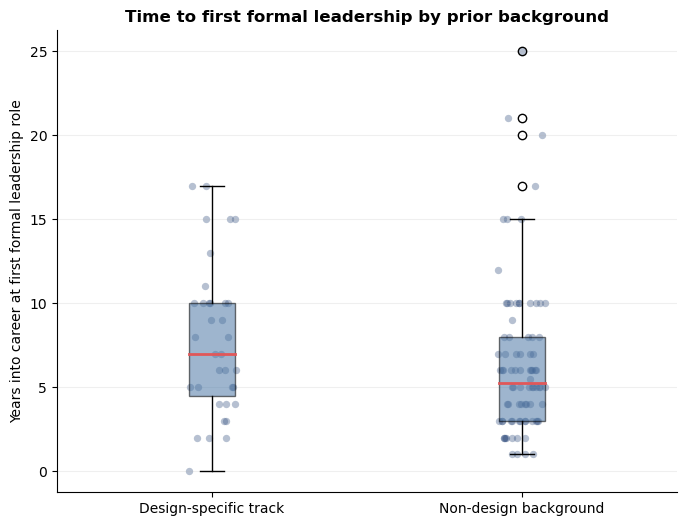

,design_track_group,count,mean,median,std,min,max
0,Design-specific track,35,7.80,7.00,4.50,0.00,17.00
1,Non-design background,84,6.45,5.25,4.57,1.00,25.00


Mann-Whitney U: 1780.5, p = 0.069
Takeaway: respondents from non-design backgrounds appear to reach first leadership slightly earlier on average, but the difference is weak and not conventionally significant in this sample.


In [7]:
q1 = relationship_df.dropna(subset=["years_to_first_leadership", "design_track_group"]).copy()
q1_summary = (
    q1.groupby("design_track_group")["years_to_first_leadership"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

track_groups = [
    q1.loc[q1["design_track_group"] == label, "years_to_first_leadership"].to_numpy()
    for label in ["Design-specific track", "Non-design background"]
]
mann_whitney_q1 = mannwhitneyu(track_groups[0], track_groups[1], alternative="two-sided")

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    track_groups,
    patch_artist=True,
    boxprops={"facecolor": "#4E79A7", "alpha": 0.55},
    medianprops={"color": "#E15759", "linewidth": 2},
)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Design-specific track", "Non-design background"])

rng = np.random.default_rng(42)
for i, values in enumerate(track_groups, start=1):
    ax.scatter(
        np.full(len(values), i) + rng.uniform(-0.08, 0.08, size=len(values)),
        values,
        color="#2F4B7C",
        alpha=0.35,
        s=28,
        linewidths=0,
    )

ax.set_title("Time to first formal leadership by prior background")
ax.set_ylabel("Years into career at first formal leadership role")
ax.grid(axis="y", alpha=0.2)
plt.show()

display(q1_summary)
print(f"Mann-Whitney U: {mann_whitney_q1.statistic:.1f}, p = {mann_whitney_q1.pvalue:.3f}")
print(
    "Takeaway: respondents from non-design backgrounds appear to reach first leadership slightly earlier on average, "
    "but the difference is weak and not conventionally significant in this sample."
)

### 2. Do people with larger current reporting structures differ in background, education, mentorship, or leadership training?

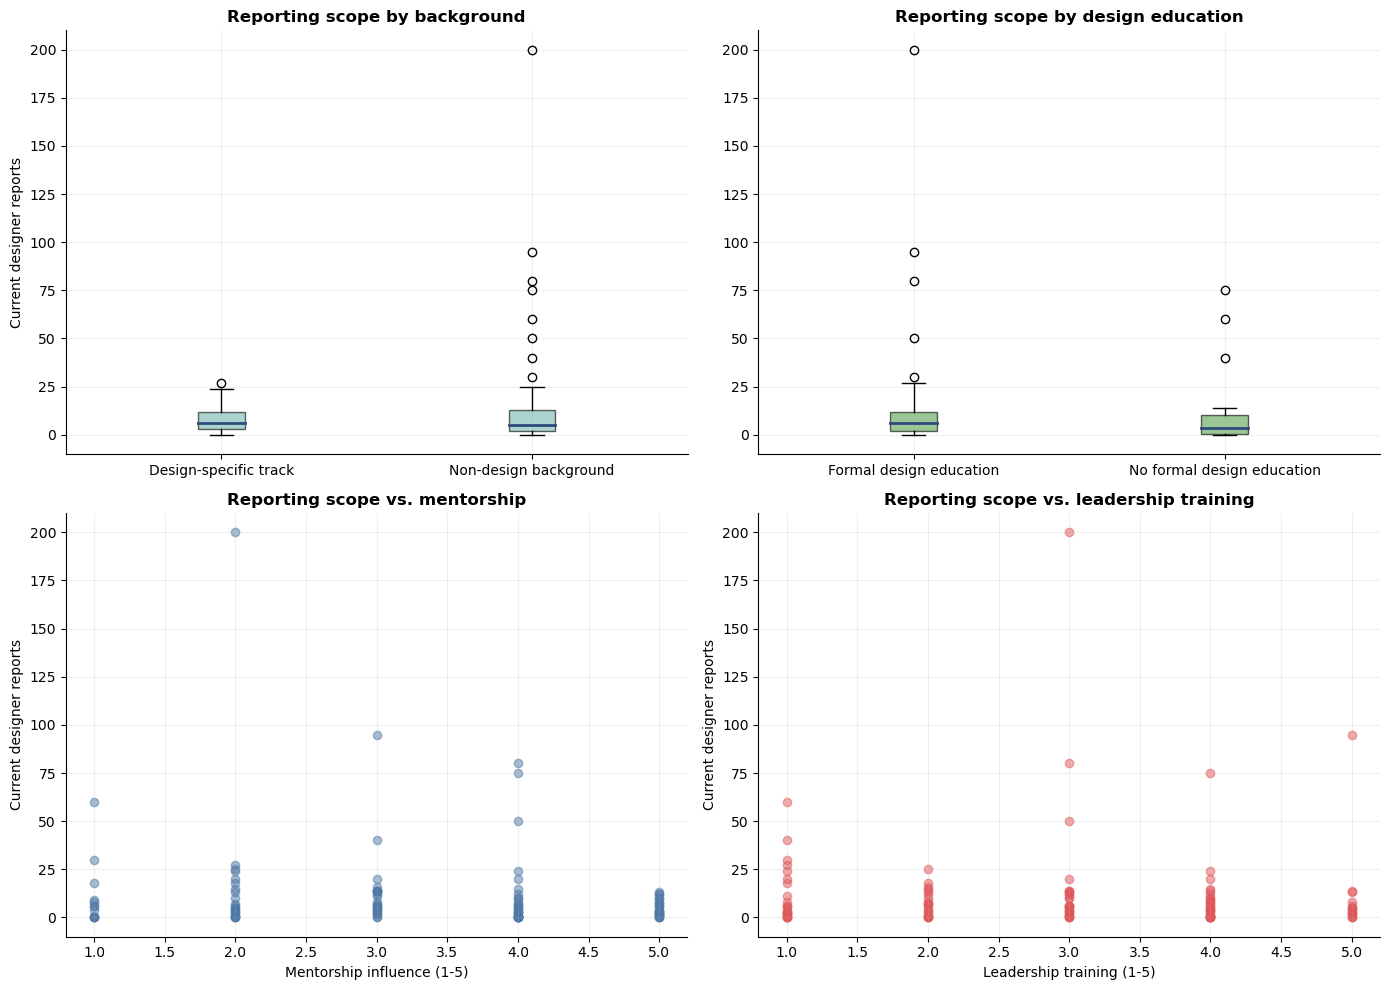

#### Background

,design_track_group,count,mean,median
0,Design-specific track,33,7.58,6.00
1,Non-design background,80,13.29,5.00


#### Design education

,formal_design_education,count,mean,median
0,Formal design education,91,11.57,6.00
1,No formal design education,22,11.82,3.50


Background Mann-Whitney p = 0.965
Education Mann-Whitney p = 0.514
Mentorship Spearman rho = -0.124, p = 0.192
Training Spearman rho = -0.080, p = 0.398
Takeaway: larger current reporting structures do not show a strong monotonic relationship with mentorship or formal leadership training, and the background/education differences are modest in this sample.


In [8]:
q2 = relationship_df.dropna(subset=["current_designer_reports"]).copy()
q2_background = (
    q2.groupby("design_track_group")["current_designer_reports"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
q2_education = (
    q2.groupby("formal_design_education")["current_designer_reports"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

background_groups = [
    q2.loc[q2["design_track_group"] == label, "current_designer_reports"].to_numpy()
    for label in ["Design-specific track", "Non-design background"]
]
education_groups = [
    q2.loc[q2["formal_design_education"] == label, "current_designer_reports"].to_numpy()
    for label in ["Formal design education", "No formal design education"]
]
background_test = mannwhitneyu(background_groups[0], background_groups[1], alternative="two-sided")
education_test = mannwhitneyu(education_groups[0], education_groups[1], alternative="two-sided")
mentor_corr = spearmanr(q2["current_designer_reports"], q2["mentorship"], nan_policy="omit")
training_corr = spearmanr(q2["current_designer_reports"], q2["leadership_training"], nan_policy="omit")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].boxplot(
    background_groups,
    patch_artist=True,
    boxprops={"facecolor": "#76B7B2", "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
)
axes[0, 0].set_xticks([1, 2])
axes[0, 0].set_xticklabels(["Design-specific track", "Non-design background"])
axes[0, 0].set_title("Reporting scope by background")
axes[0, 0].set_ylabel("Current designer reports")

axes[0, 1].boxplot(
    education_groups,
    patch_artist=True,
    boxprops={"facecolor": "#59A14F", "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
)
axes[0, 1].set_xticks([1, 2])
axes[0, 1].set_xticklabels(["Formal design education", "No formal design education"])
axes[0, 1].set_title("Reporting scope by design education")

axes[1, 0].scatter(q2["mentorship"], q2["current_designer_reports"], color="#4E79A7", alpha=0.5)
axes[1, 0].set_title("Reporting scope vs. mentorship")
axes[1, 0].set_xlabel("Mentorship influence (1-5)")
axes[1, 0].set_ylabel("Current designer reports")

axes[1, 1].scatter(q2["leadership_training"], q2["current_designer_reports"], color="#E15759", alpha=0.5)
axes[1, 1].set_title("Reporting scope vs. leadership training")
axes[1, 1].set_xlabel("Leadership training (1-5)")
axes[1, 1].set_ylabel("Current designer reports")

for ax in axes.ravel():
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

display(Markdown("#### Background"))
display(q2_background)
display(Markdown("#### Design education"))
display(q2_education)

print(f"Background Mann-Whitney p = {background_test.pvalue:.3f}")
print(f"Education Mann-Whitney p = {education_test.pvalue:.3f}")
print(f"Mentorship Spearman rho = {result_stat(mentor_corr):.3f}, p = {result_pvalue(mentor_corr):.3f}")
print(f"Training Spearman rho = {result_stat(training_corr):.3f}, p = {result_pvalue(training_corr):.3f}")
print(
    "Takeaway: larger current reporting structures do not show a strong monotonic relationship with mentorship or formal leadership training, "
    "and the background/education differences are modest in this sample."
)

### 3. Are there regional differences in leadership timing, current level, or team size?

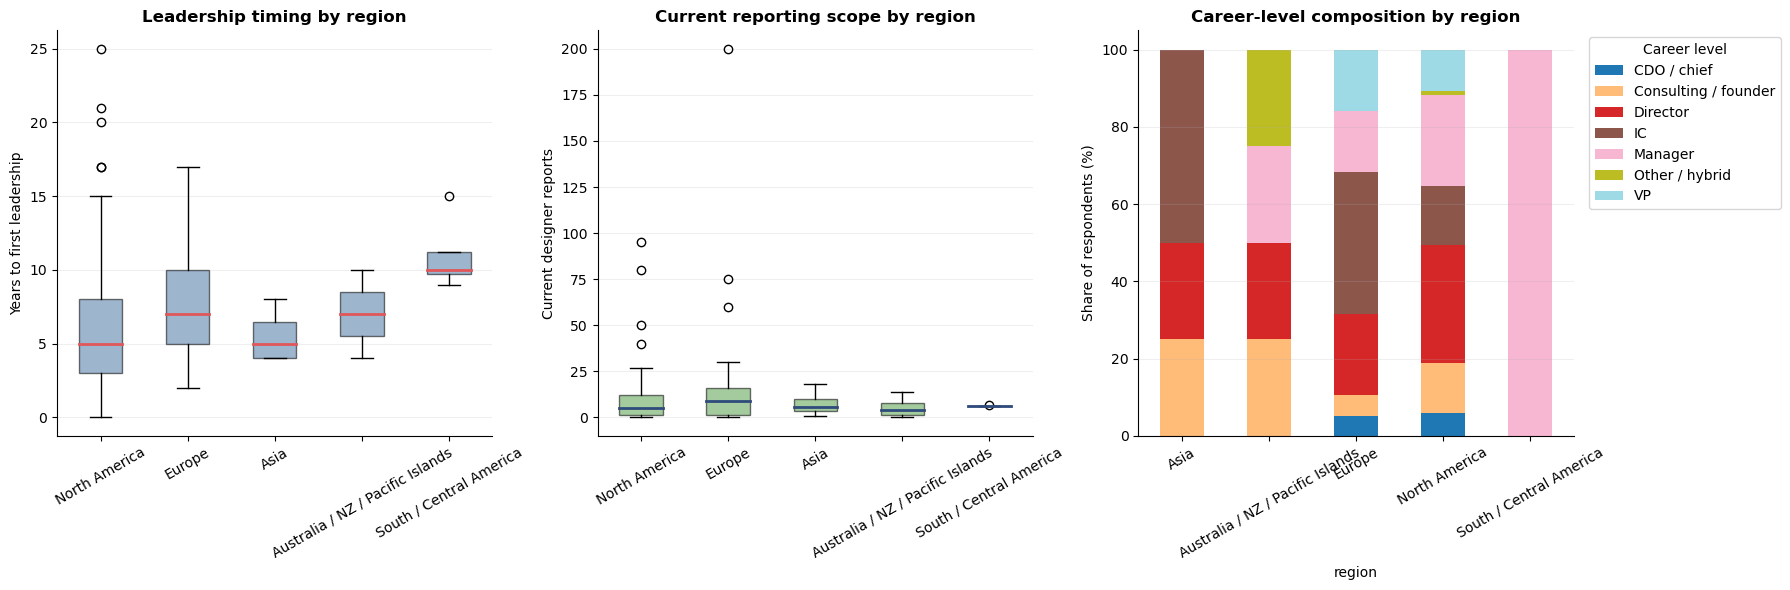

#### Leadership timing by region

,region,count,mean,median
0,Asia,4,5.50,5.00
1,Australia / NZ / Pacific Islands,4,7.00,7.00
2,Europe,19,7.63,7.00
3,North America,85,6.62,5.00
4,South / Central America,4,11.00,10.00


#### Current reporting scope by region

,region,count,mean,median
0,Asia,4,7.50,5.50
1,Australia / NZ / Pacific Islands,4,5.50,4.00
2,Europe,19,24.21,9.00
3,North America,79,9.63,5.00
4,South / Central America,4,6.25,6.00


Kruskal-Wallis for leadership timing: H = 7.54, p = 0.110
Kruskal-Wallis for reporting scope: H = 1.51, p = 0.825
Chi-square for career-level mix: chi2 = 38.16, p = 0.033
Takeaway: there are some visible regional differences, especially in career-level composition and average reporting scope, but interpretation should stay cautious because most responses come from North America and several regions have very small samples.


In [9]:
q3 = relationship_df.dropna(subset=["region"]).copy()
major_regions = q3["region"].value_counts().loc[lambda s: s >= 4].index.tolist()
q3_major = q3[q3["region"].isin(major_regions)].copy()

q3_timing_summary = (
    q3_major.groupby("region")["years_to_first_leadership"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
q3_scope_summary = (
    q3_major.groupby("region")["current_designer_reports"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
q3_level_share = pd.crosstab(
    q3_major["region"], q3_major["career_level_group"], normalize="index"
) * 100

region_timing_groups = [
    q3_major.loc[q3_major["region"] == region, "years_to_first_leadership"].dropna().to_numpy()
    for region in major_regions
]
region_scope_groups = [
    q3_major.loc[q3_major["region"] == region, "current_designer_reports"].dropna().to_numpy()
    for region in major_regions
]
kruskal_timing = kruskal(*[group for group in region_timing_groups if len(group) > 0])
kruskal_scope = kruskal(*[group for group in region_scope_groups if len(group) > 0])
chi2_levels = chi2_contingency(pd.crosstab(q3_major["region"], q3_major["career_level_group"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].boxplot(
    [q3_major.loc[q3_major["region"] == region, "years_to_first_leadership"].dropna().to_numpy() for region in major_regions],
    patch_artist=True,
    boxprops={"facecolor": "#4E79A7", "alpha": 0.55},
    medianprops={"color": "#E15759", "linewidth": 2},
)
axes[0].set_xticks(range(1, len(major_regions) + 1))
axes[0].set_xticklabels(major_regions)
axes[0].set_title("Leadership timing by region")
axes[0].set_ylabel("Years to first leadership")
axes[0].tick_params(axis="x", rotation=30)

axes[1].boxplot(
    [q3_major.loc[q3_major["region"] == region, "current_designer_reports"].dropna().to_numpy() for region in major_regions],
    patch_artist=True,
    boxprops={"facecolor": "#59A14F", "alpha": 0.55},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
)
axes[1].set_xticks(range(1, len(major_regions) + 1))
axes[1].set_xticklabels(major_regions)
axes[1].set_title("Current reporting scope by region")
axes[1].set_ylabel("Current designer reports")
axes[1].tick_params(axis="x", rotation=30)

q3_level_share.plot(kind="bar", stacked=True, ax=axes[2], colormap="tab20")
axes[2].set_title("Career-level composition by region")
axes[2].set_ylabel("Share of respondents (%)")
axes[2].legend(title="Career level", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes[:2]:
    ax.grid(axis="y", alpha=0.2)
axes[2].grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

display(Markdown("#### Leadership timing by region"))
display(q3_timing_summary)
display(Markdown("#### Current reporting scope by region"))
display(q3_scope_summary)

print(f"Kruskal-Wallis for leadership timing: H = {kruskal_timing.statistic:.2f}, p = {kruskal_timing.pvalue:.3f}")
print(f"Kruskal-Wallis for reporting scope: H = {kruskal_scope.statistic:.2f}, p = {kruskal_scope.pvalue:.3f}")
print(f"Chi-square for career-level mix: chi2 = {result_stat(chi2_levels):.2f}, p = {result_pvalue(chi2_levels):.3f}")
print(
    "Takeaway: there are some visible regional differences, especially in career-level composition and average reporting scope, "
    "but interpretation should stay cautious because most responses come from North America and several regions have very small samples."
)

### 4. Do people with formal design education differ from those without it in speed of advancement or executive attainment?

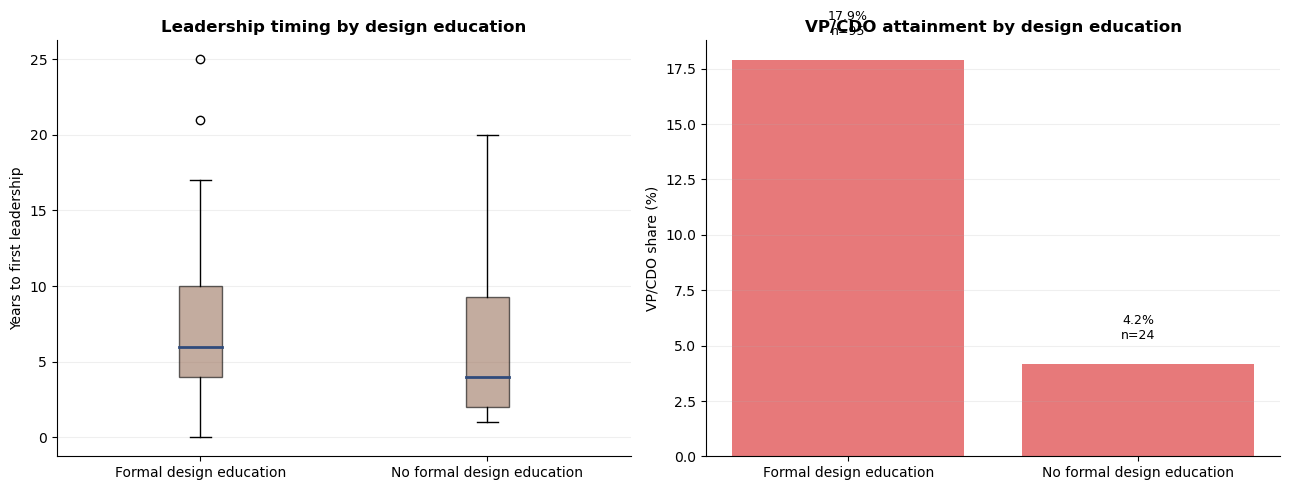

,formal_design_education,count,mean,median,std
0,Formal design education,95,7.01,6.00,4.40
1,No formal design education,24,6.19,4.00,5.23


,formal_design_education,vp_cdo_share,n
0,Formal design education,17.89,95
1,No formal design education,4.17,24


Mann-Whitney U for leadership timing: 1374.5, p = 0.119
Fisher's exact test for VP/CDO attainment: odds ratio = 0.199, p = 0.118
Takeaway: respondents with formal design education show somewhat higher VP/CDO representation and slightly slower median time to first leadership, but neither difference is statistically strong in this sample.


In [10]:
q4 = relationship_df.copy()
q4_timing = q4.dropna(subset=["years_to_first_leadership", "formal_design_education"])
q4_timing_summary = (
    q4_timing.groupby("formal_design_education")["years_to_first_leadership"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)
q4_exec_share = (
    q4.groupby("formal_design_education")["is_vp_cdo"]
    .agg(vp_cdo_share="mean", n="size")
    .reset_index()
)
q4_exec_share["vp_cdo_share"] *= 100

education_timing_groups = [
    q4_timing.loc[q4_timing["formal_design_education"] == label, "years_to_first_leadership"].to_numpy()
    for label in ["Formal design education", "No formal design education"]
]
mann_whitney_q4 = mannwhitneyu(education_timing_groups[0], education_timing_groups[1], alternative="two-sided")
exec_table = pd.crosstab(q4["formal_design_education"], q4["is_vp_cdo"])
fisher_q4 = fisher_exact(exec_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(
    education_timing_groups,
    patch_artist=True,
    boxprops={"facecolor": "#9C755F", "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Formal design education", "No formal design education"])
axes[0].set_title("Leadership timing by design education")
axes[0].set_ylabel("Years to first leadership")
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(
    q4_exec_share["formal_design_education"],
    q4_exec_share["vp_cdo_share"],
    color="#E15759",
    alpha=0.8,
)
for patch, pct, n in zip(axes[1].patches, q4_exec_share["vp_cdo_share"], q4_exec_share["n"]):
    axes[1].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 1,
        f"{pct:.1f}%\nn={int(n)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[1].set_title("VP/CDO attainment by design education")
axes[1].set_ylabel("VP/CDO share (%)")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

display(q4_timing_summary)
display(q4_exec_share)

print(f"Mann-Whitney U for leadership timing: {mann_whitney_q4.statistic:.1f}, p = {mann_whitney_q4.pvalue:.3f}")
print(f"Fisher's exact test for VP/CDO attainment: odds ratio = {fisher_q4[0]:.3f}, p = {fisher_q4[1]:.3f}")
print(
    "Takeaway: respondents with formal design education show somewhat higher VP/CDO representation and slightly slower median time to first leadership, "
    "but neither difference is statistically strong in this sample."
)

### 5. Does the scale of the first design team predict later career level or people-management scope?

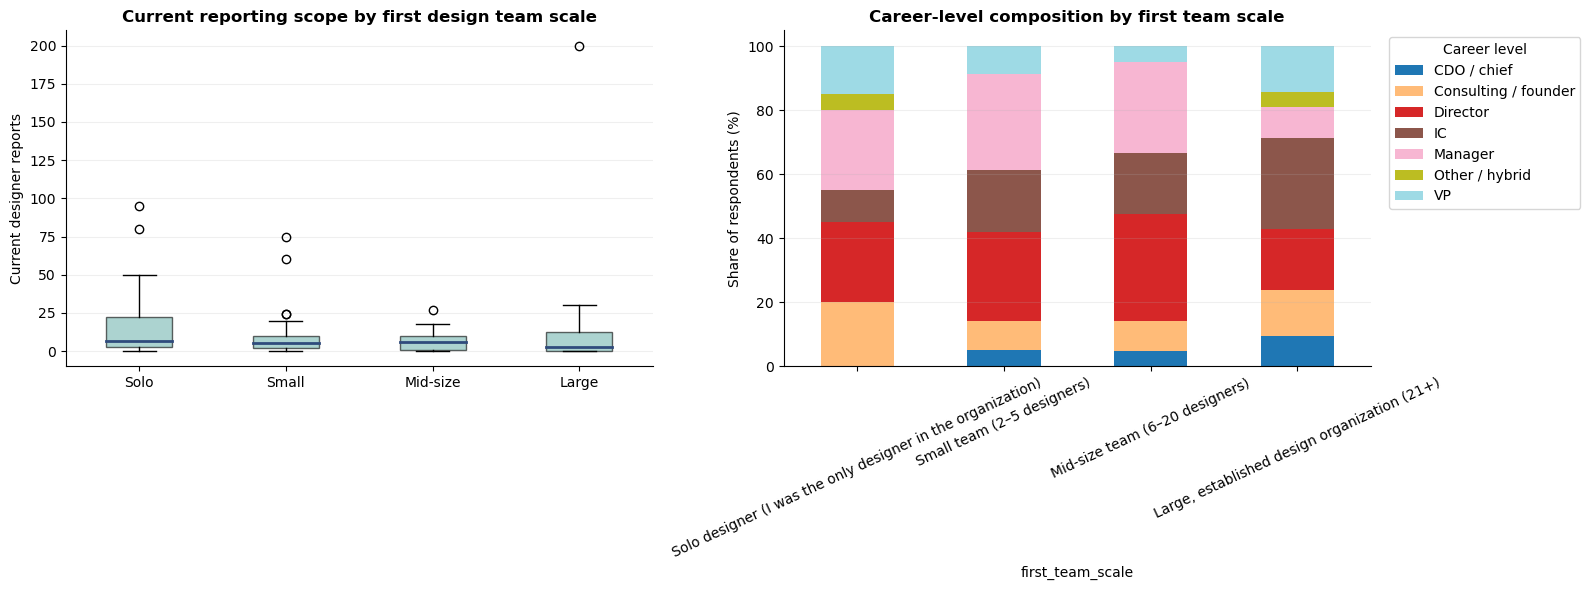

,first_team_scale,count,mean,median
0,Solo designer (I was the only designer in the ...,18,19.94,6.50
1,Small team (2–5 designers),54,8.87,5.50
2,Mid-size team (6–20 designers),21,7.05,6.00
3,"Large, established design organization (21+)",20,16.35,2.50


Kruskal-Wallis for reporting scope: H = 1.97, p = 0.579
Spearman rho for ordered first-team scale vs. current reports: -0.112, p = 0.239
Chi-square for first-team scale vs. career-level mix: chi2 = 14.30, p = 0.709
Takeaway: first-team scale does not show a clear monotonic relationship with later reporting scope or current career-level mix in this sample.


In [11]:
q5 = relationship_df.dropna(subset=["first_team_scale", "first_team_scale_num"]).copy()
q5_scope_summary = (
    q5.groupby("first_team_scale")["current_designer_reports"]
    .agg(["count", "mean", "median"])
    .reindex(first_team_scale_order)
    .reset_index()
)
q5_level_share = pd.crosstab(
    q5["first_team_scale"], q5["career_level_group"], normalize="index"
).reindex(first_team_scale_order) * 100

scope_groups = [
    q5.loc[q5["first_team_scale"] == label, "current_designer_reports"].dropna().to_numpy()
    for label in first_team_scale_order
]
kruskal_scope_q5 = kruskal(*[group for group in scope_groups if len(group) > 0])
spearman_scope_q5 = spearmanr(
    q5["first_team_scale_num"], q5["current_designer_reports"], nan_policy="omit"
)
chi2_levels_q5 = chi2_contingency(pd.crosstab(q5["first_team_scale"], q5["career_level_group"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].boxplot(
    scope_groups,
    patch_artist=True,
    boxprops={"facecolor": "#76B7B2", "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
)
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(["Solo", "Small", "Mid-size", "Large"])
axes[0].set_title("Current reporting scope by first design team scale")
axes[0].set_ylabel("Current designer reports")
axes[0].grid(axis="y", alpha=0.2)

q5_level_share.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Career-level composition by first team scale")
axes[1].set_ylabel("Share of respondents (%)")
axes[1].legend(title="Career level", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

display(q5_scope_summary)
print(f"Kruskal-Wallis for reporting scope: H = {kruskal_scope_q5.statistic:.2f}, p = {kruskal_scope_q5.pvalue:.3f}")
print(f"Spearman rho for ordered first-team scale vs. current reports: {result_stat(spearman_scope_q5):.3f}, p = {result_pvalue(spearman_scope_q5):.3f}")
print(f"Chi-square for first-team scale vs. career-level mix: chi2 = {result_stat(chi2_levels_q5):.2f}, p = {result_pvalue(chi2_levels_q5):.3f}")
print(
    "Takeaway: first-team scale does not show a clear monotonic relationship with later reporting scope or current career-level mix in this sample."
)

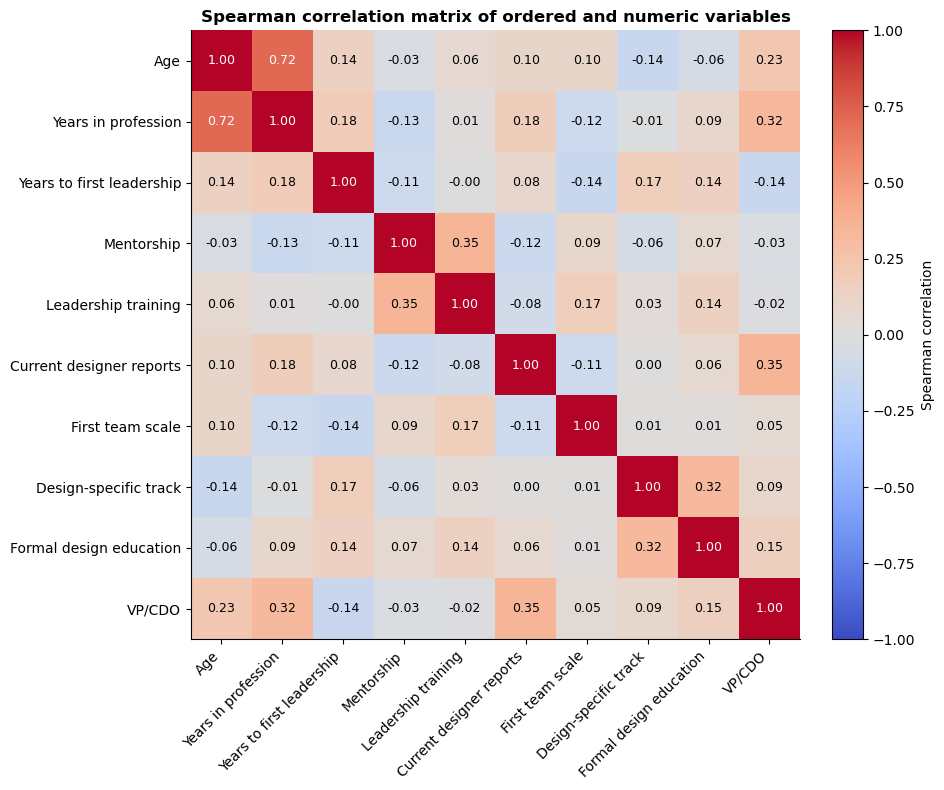

,Age,Years in profession,Years to first leadership,Mentorship,Leadership training,Current designer reports,First team scale,Design-specific track,Formal design education,VP/CDO
Age,1.00,0.72,0.14,-0.03,0.06,0.10,0.10,-0.14,-0.06,0.23
Years in profession,0.72,1.00,0.18,-0.13,0.01,0.18,-0.12,-0.01,0.09,0.32
Years to first leadership,0.14,0.18,1.00,-0.11,-0.00,0.08,-0.14,0.17,0.14,-0.14
Mentorship,-0.03,-0.13,-0.11,1.00,0.35,-0.12,0.09,-0.06,0.07,-0.03
Leadership training,0.06,0.01,-0.00,0.35,1.00,-0.08,0.17,0.03,0.14,-0.02
Current designer reports,0.10,0.18,0.08,-0.12,-0.08,1.00,-0.11,0.00,0.06,0.35
First team scale,0.10,-0.12,-0.14,0.09,0.17,-0.11,1.00,0.01,0.01,0.05
Design-specific track,-0.14,-0.01,0.17,-0.06,0.03,0.00,0.01,1.00,0.32,0.09
Formal design education,-0.06,0.09,0.14,0.07,0.14,0.06,0.01,0.32,1.00,0.15
VP/CDO,0.23,0.32,-0.14,-0.03,-0.02,0.35,0.05,0.09,0.15,1.00


### Stronger correlations (|rho| >= 0.30)

,variable_1,variable_2,spearman_rho
0,Age,Years in profession,0.72
1,Current designer reports,VP/CDO,0.35
2,Mentorship,Leadership training,0.35
3,Design-specific track,Formal design education,0.32
4,Years in profession,VP/CDO,0.32


In [12]:
age_midpoint_map = {
    "24-35": 29.5,
    "36-45": 40.5,
    "46-55": 50.5,
    "56-65": 60.5,
    "65+": 70.0,
}

correlation_df = relationship_df.copy()
correlation_df["age_midpoint"] = correlation_df["age"].astype("string").map(age_midpoint_map)
correlation_df["design_track_binary"] = (
    correlation_df["design_track_group"].eq("Design-specific track").astype(int)
)
correlation_df["formal_design_education_binary"] = (
    correlation_df["formal_design_education"].eq("Formal design education").astype(int)
)
correlation_df["vp_cdo_binary"] = correlation_df["is_vp_cdo"].astype(int)

correlation_vars = {
    "Age": "age_midpoint",
    "Years in profession": "years_professional",
    "Years to first leadership": "years_to_first_leadership",
    "Mentorship": "mentorship",
    "Leadership training": "leadership_training",
    "Current designer reports": "current_designer_reports",
    "First team scale": "first_team_scale_num",
    "Design-specific track": "design_track_binary",
    "Formal design education": "formal_design_education_binary",
    "VP/CDO": "vp_cdo_binary",
}

correlation_matrix = correlation_df[list(correlation_vars.values())].corr(method="spearman")
correlation_matrix.index = correlation_vars.keys()
correlation_matrix.columns = correlation_vars.keys()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        value = correlation_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.5 else "black",
            fontsize=9,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman correlation")
ax.set_title("Spearman correlation matrix of ordered and numeric variables")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(2))

strong_pairs = []
for i, row_name in enumerate(correlation_matrix.index):
    for j, col_name in enumerate(correlation_matrix.columns):
        if j <= i:
            continue
        value = correlation_matrix.iloc[i, j]
        if pd.notna(value) and abs(value) >= 0.30:
            strong_pairs.append((row_name, col_name, value))

strong_pairs_df = pd.DataFrame(
    strong_pairs, columns=["variable_1", "variable_2", "spearman_rho"]
).sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False)

display(Markdown("### Stronger correlations (|rho| >= 0.30)"))
if strong_pairs_df.empty:
    print("No pairwise correlations met the |rho| >= 0.30 threshold in this set of variables.")
else:
    display(strong_pairs_df.reset_index(drop=True))

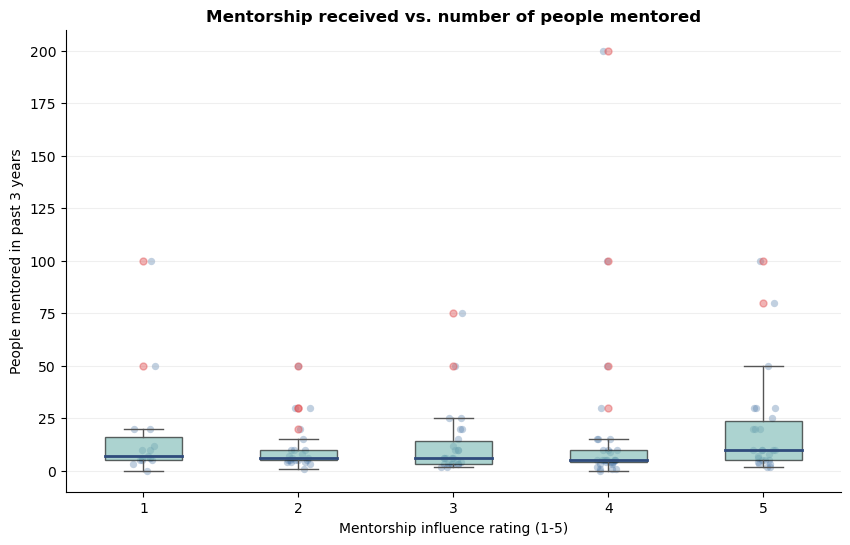

,mentorship,count,mean,median,std,min,max
0,1,15,17.27,7.00,25.88,0,100
1,2,22,11.05,6.00,11.77,1,50
2,3,26,12.81,6.00,16.57,2,75
3,4,30,17.70,5.00,39.54,0,200
4,5,26,19.42,10.00,23.99,2,100


Spearman rho = 0.031, p = 0.738
Kruskal-Wallis H = 4.91, p = 0.296
Takeaway: this sample does not show a strong or statistically reliable relationship between having more positive mentoring experiences and mentoring more people now.


In [13]:
PEOPLE_MENTORED_COL = "How many people have you mentored in the past 3 years? (rough estimate)"

mentor_pay_it_forward_df = relationship_df.copy()
mentor_pay_it_forward_df["people_mentored"] = pd.to_numeric(
    raw[PEOPLE_MENTORED_COL], errors="coerce"
)
mentor_pay_it_forward_df = mentor_pay_it_forward_df.dropna(
    subset=["mentorship", "people_mentored"]
)

mentor_pay_it_forward_summary = (
    mentor_pay_it_forward_df.groupby("mentorship")["people_mentored"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

mentor_corr = spearmanr(
    mentor_pay_it_forward_df["mentorship"],
    mentor_pay_it_forward_df["people_mentored"],
    nan_policy="omit",
)
kruskal_mentor_groups = [
    mentor_pay_it_forward_df.loc[
        mentor_pay_it_forward_df["mentorship"] == value,
        "people_mentored",
    ].to_numpy()
    for value in sorted(mentor_pay_it_forward_df["mentorship"].dropna().unique())
]
kruskal_mentor_result = kruskal(*kruskal_mentor_groups)

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    kruskal_mentor_groups,
    patch_artist=True,
    boxprops={"facecolor": "#76B7B2", "alpha": 0.6},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={"marker": "o", "markerfacecolor": "#E15759", "markeredgecolor": "#E15759", "alpha": 0.45, "markersize": 5},
)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1", "2", "3", "4", "5"])

rng = np.random.default_rng(42)
for i, value in enumerate(sorted(mentor_pay_it_forward_df["mentorship"].dropna().unique()), start=1):
    y = mentor_pay_it_forward_df.loc[
        mentor_pay_it_forward_df["mentorship"] == value,
        "people_mentored",
    ].to_numpy()
    x = np.full(len(y), i) + rng.uniform(-0.08, 0.08, size=len(y))
    ax.scatter(x, y, color="#4E79A7", alpha=0.35, s=28, linewidths=0)

ax.set_title("Mentorship received vs. number of people mentored")
ax.set_xlabel("Mentorship influence rating (1-5)")
ax.set_ylabel("People mentored in past 3 years")
ax.grid(axis="y", alpha=0.2)
plt.show()

display(mentor_pay_it_forward_summary)
print(f"Spearman rho = {result_stat(mentor_corr):.3f}, p = {result_pvalue(mentor_corr):.3f}")
print(f"Kruskal-Wallis H = {kruskal_mentor_result.statistic:.2f}, p = {kruskal_mentor_result.pvalue:.3f}")
print(
    "Takeaway: this sample does not show a strong or statistically reliable relationship between having more positive mentoring experiences "
    "and mentoring more people now."
)

## Standalone question highlights

These charts focus on strong **single-question stories**, rather than relationships between variables.

Included here:

- expected tool-stack change in the next 5 years
- intended career trajectory
- most common reported career setbacks
- most common activities outside the primary role

This section is designed to surface the clearest narrative signals from the survey.

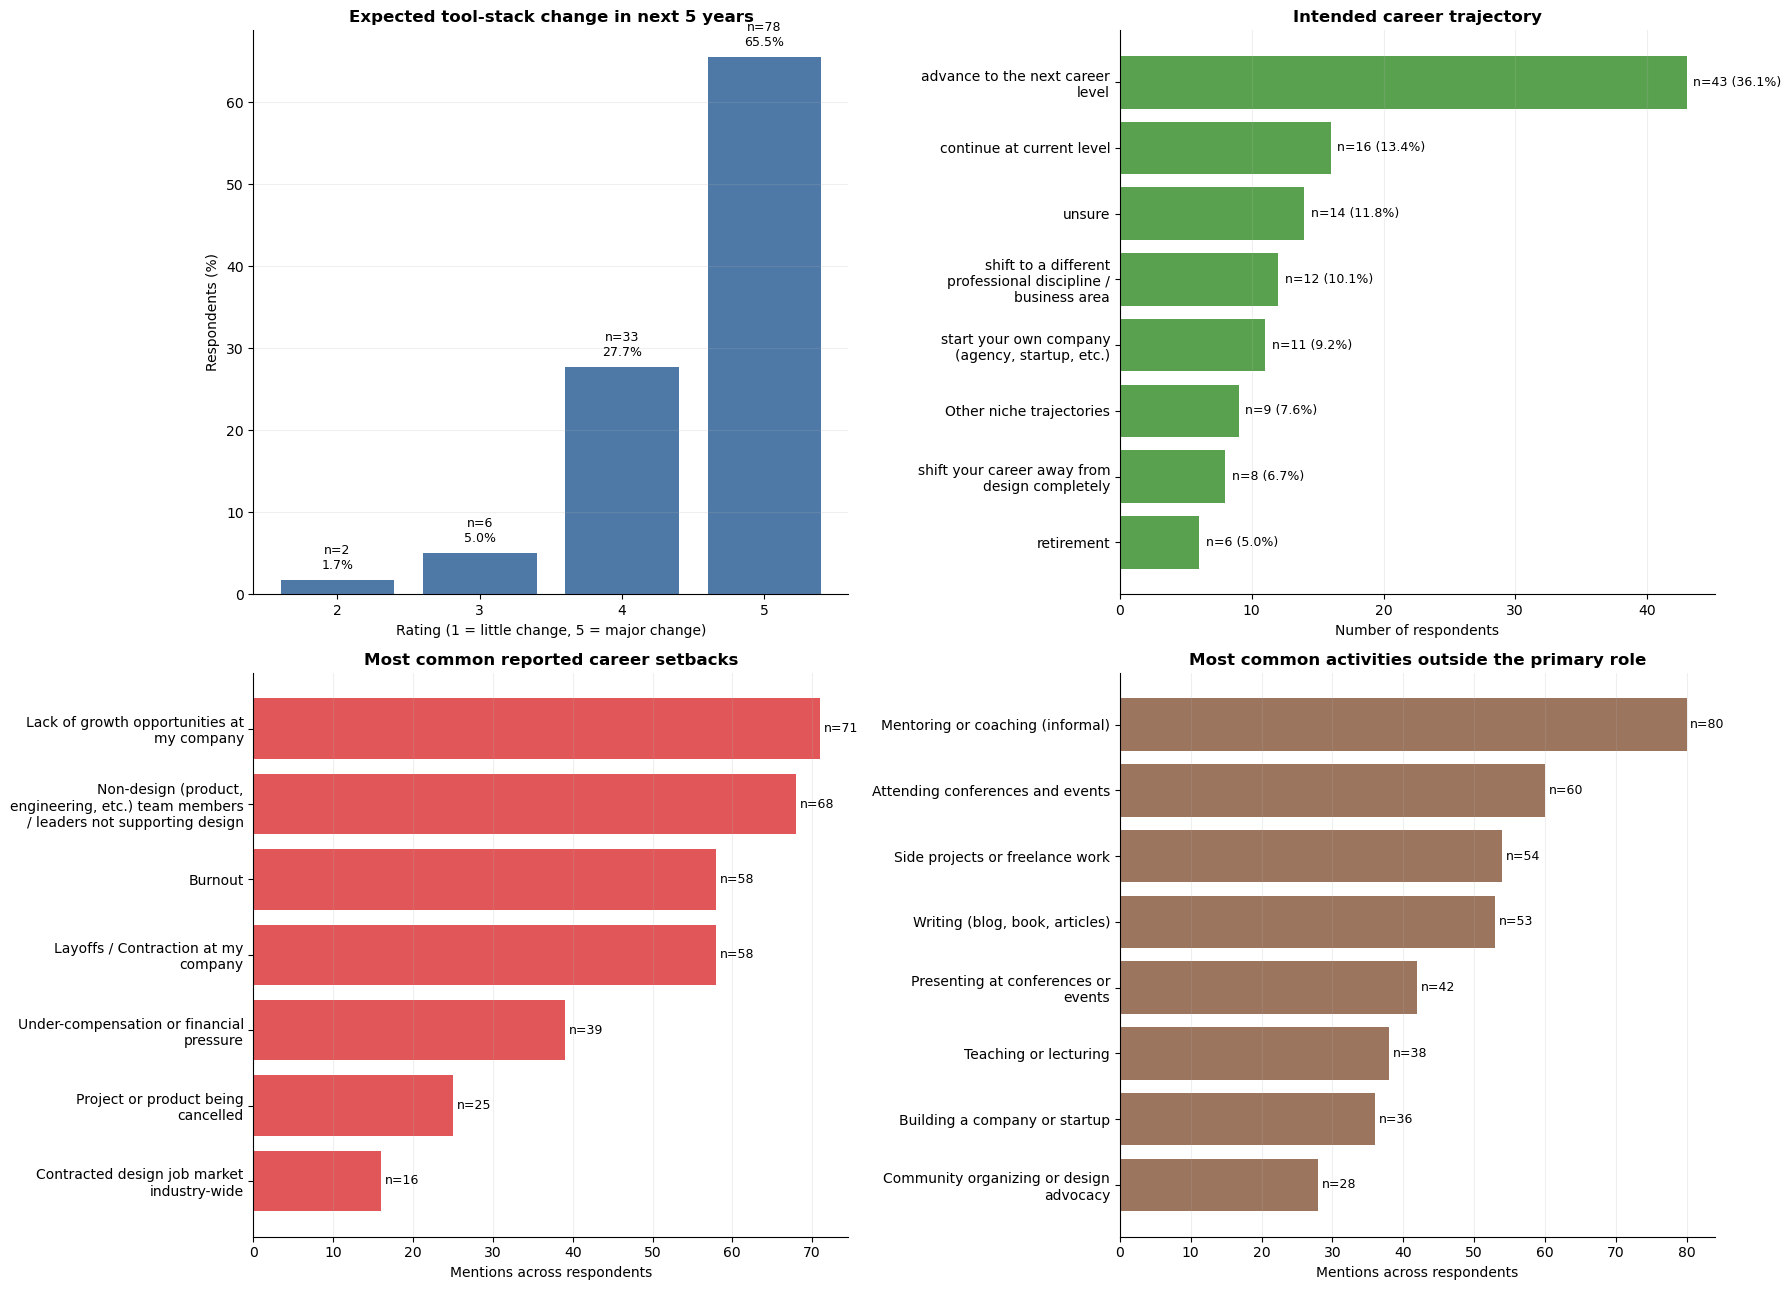

### Standalone question summaries

#### Tool-stack change

,rating,count,percent
0,2,2,1.70
1,3,6,5.00
2,4,33,27.70
3,5,78,65.50


#### Intended career trajectory

,trajectory,count,percent
0,advance to the next career level,43,36.10
1,continue at current level,16,13.40
2,unsure,14,11.80
3,shift to a different professional discipline /...,12,10.10
4,"start your own company (agency, startup, etc.)",11,9.20
5,Other niche trajectories,9,7.60
6,shift your career away from design completely,8,6.70
7,retirement,6,5.00


...

,category,count
4,Lack of growth opportunities at my company,71
0,"Non-design (product, engineering, etc.) team m...",68
1,Layoffs / Contraction at my company,58
5,Burnout,58
3,Under-compensation or financial pressure,39
2,Project or product being cancelled,25
6,Contracted design job market industry-wide,16


Unmatched/custom setback responses not captured in the predefined options: 5


#### Top outside-role activities

,category,count
4,Mentoring or coaching (informal),80
2,Attending conferences and events,60
5,Side projects or freelance work,54
0,"Writing (blog, book, articles)",53
3,Presenting at conferences or events,42
1,Teaching or lecturing,38
6,Building a company or startup,36
7,Community organizing or design advocacy,28


Unmatched/custom outside-role responses not captured in the predefined options: 3


In [14]:
from collections import Counter
import textwrap

TOOL_STACK_CHANGE_COL = "In the next 5 years, how much do you expect your tool stack to change?"
CAREER_TRAJECTORY_COL = "In the next 5 years, which direction best describes your intended career trajectory? "
SETBACKS_COL = "Which of the following have been major setbacks in your career [select all that apply]"
OUTSIDE_ROLE_COL = "Outside of your primary role, are you currently engaged in any of the following? (Select all that apply)"

SETBACK_OPTIONS = [
    "Non-design (product, engineering, etc.) team members / leaders not supporting design",
    "Layoffs / Contraction at my company",
    "Project or product being cancelled",
    "Under-compensation or financial pressure",
    "Lack of growth opportunities at my company",
    "Burnout",
    "Contracted design job market industry-wide",
]

OUTSIDE_ROLE_OPTIONS = [
    "Writing (blog, book, articles)",
    "Teaching or lecturing",
    "Attending conferences and events",
    "Presenting at conferences or events",
    "Mentoring or coaching (informal)",
    "Side projects or freelance work",
    "Building a company or startup",
    "Community organizing or design advocacy",
    "Social media / content creation",
]


def wrap_series_labels(values, width=28):
    return [textwrap.fill(str(value), width=width) for value in values]


def count_known_multiselect_options(series, known_options):
    counter = Counter()
    unmatched_count = 0

    for value in series.dropna():
        text = str(value).strip()
        if not text or text.lower() in MISSING_TOKENS or text.lower() == "nan":
            continue

        matched_any = False
        for option in known_options:
            if option in text:
                counter[option] += 1
                matched_any = True

        if not matched_any:
            unmatched_count += 1

    summary = pd.DataFrame(counter.items(), columns=["category", "count"]).sort_values(
        "count", ascending=False
    )
    return summary, unmatched_count


standalone_df = raw.copy()

# 1. Tool stack change
tool_stack_summary = (
    pd.to_numeric(standalone_df[TOOL_STACK_CHANGE_COL], errors="coerce")
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)
tool_stack_summary["percent"] = (
    tool_stack_summary["count"] / tool_stack_summary["count"].sum() * 100
).round(1)

# 2. Career trajectory with rare responses grouped into Other
career_trajectory = standalone_df[CAREER_TRAJECTORY_COL].astype("string").str.strip()
career_counts = career_trajectory.value_counts(dropna=True)
major_trajectory_levels = career_counts[career_counts >= 5].index
career_trajectory_grouped = career_trajectory.where(
    career_trajectory.isin(major_trajectory_levels), "Other niche trajectories"
)
career_trajectory_summary = (
    career_trajectory_grouped.value_counts()
    .rename_axis("trajectory")
    .reset_index(name="count")
)
career_trajectory_summary["percent"] = (
    career_trajectory_summary["count"] / career_trajectory_summary["count"].sum() * 100
).round(1)

# 3. Multi-select questions based on known survey options
setbacks_summary, setbacks_unmatched = count_known_multiselect_options(
    standalone_df[SETBACKS_COL], SETBACK_OPTIONS
)
setbacks_summary = setbacks_summary.head(8)
outside_role_summary, outside_role_unmatched = count_known_multiselect_options(
    standalone_df[OUTSIDE_ROLE_COL], OUTSIDE_ROLE_OPTIONS
)
outside_role_summary = outside_role_summary.head(8)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Tool stack change
ax = axes[0, 0]
ax.bar(tool_stack_summary["rating"].astype(str), tool_stack_summary["percent"], color="#4E79A7")
for patch, count, pct in zip(ax.patches, tool_stack_summary["count"], tool_stack_summary["percent"]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 1,
        f"n={int(count)}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_title("Expected tool-stack change in next 5 years")
ax.set_xlabel("Rating (1 = little change, 5 = major change)")
ax.set_ylabel("Respondents (%)")
ax.grid(axis="y", alpha=0.2)

# Career trajectory
ax = axes[0, 1]
trajectory_plot = career_trajectory_summary.sort_values("count", ascending=True)
ax.barh(wrap_series_labels(trajectory_plot["trajectory"], width=30), trajectory_plot["count"], color="#59A14F")
for patch, count, pct in zip(ax.patches, trajectory_plot["count"], trajectory_plot["percent"]):
    ax.text(
        patch.get_width() + 0.5,
        patch.get_y() + patch.get_height() / 2,
        f"n={int(count)} ({pct:.1f}%)",
        va="center",
        fontsize=9,
    )
ax.set_title("Intended career trajectory")
ax.set_xlabel("Number of respondents")
ax.grid(axis="x", alpha=0.2)

# Setbacks
ax = axes[1, 0]
setbacks_plot = setbacks_summary.sort_values("count", ascending=True)
ax.barh(wrap_series_labels(setbacks_plot["category"], width=32), setbacks_plot["count"], color="#E15759")
for patch, count in zip(ax.patches, setbacks_plot["count"]):
    ax.text(
        patch.get_width() + 0.5,
        patch.get_y() + patch.get_height() / 2,
        f"n={int(count)}",
        va="center",
        fontsize=9,
    )
ax.set_title("Most common reported career setbacks")
ax.set_xlabel("Mentions across respondents")
ax.grid(axis="x", alpha=0.2)

# Outside-role activities
ax = axes[1, 1]
outside_plot = outside_role_summary.sort_values("count", ascending=True)
ax.barh(wrap_series_labels(outside_plot["category"], width=32), outside_plot["count"], color="#9C755F")
for patch, count in zip(ax.patches, outside_plot["count"]):
    ax.text(
        patch.get_width() + 0.5,
        patch.get_y() + patch.get_height() / 2,
        f"n={int(count)}",
        va="center",
        fontsize=9,
    )
ax.set_title("Most common activities outside the primary role")
ax.set_xlabel("Mentions across respondents")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

display(Markdown("### Standalone question summaries"))
display(Markdown("#### Tool-stack change"))
display(tool_stack_summary)
display(Markdown("#### Intended career trajectory"))
display(career_trajectory_summary)
display(Markdown("#### Top setbacks"))
display(setbacks_summary)
print(f"Unmatched/custom setback responses not captured in the predefined options: {setbacks_unmatched}")
display(Markdown("#### Top outside-role activities"))
display(outside_role_summary)
print(f"Unmatched/custom outside-role responses not captured in the predefined options: {outside_role_unmatched}")

## Career pathway flow

This section visualizes possible pathways into design leadership using a grouped alluvial flow:

- background before design
- highest level of design education
- first organization type
- current grouped career level

To keep the chart readable, a few sparse categories are grouped into broader buckets while preserving the overall structure of the pipeline.

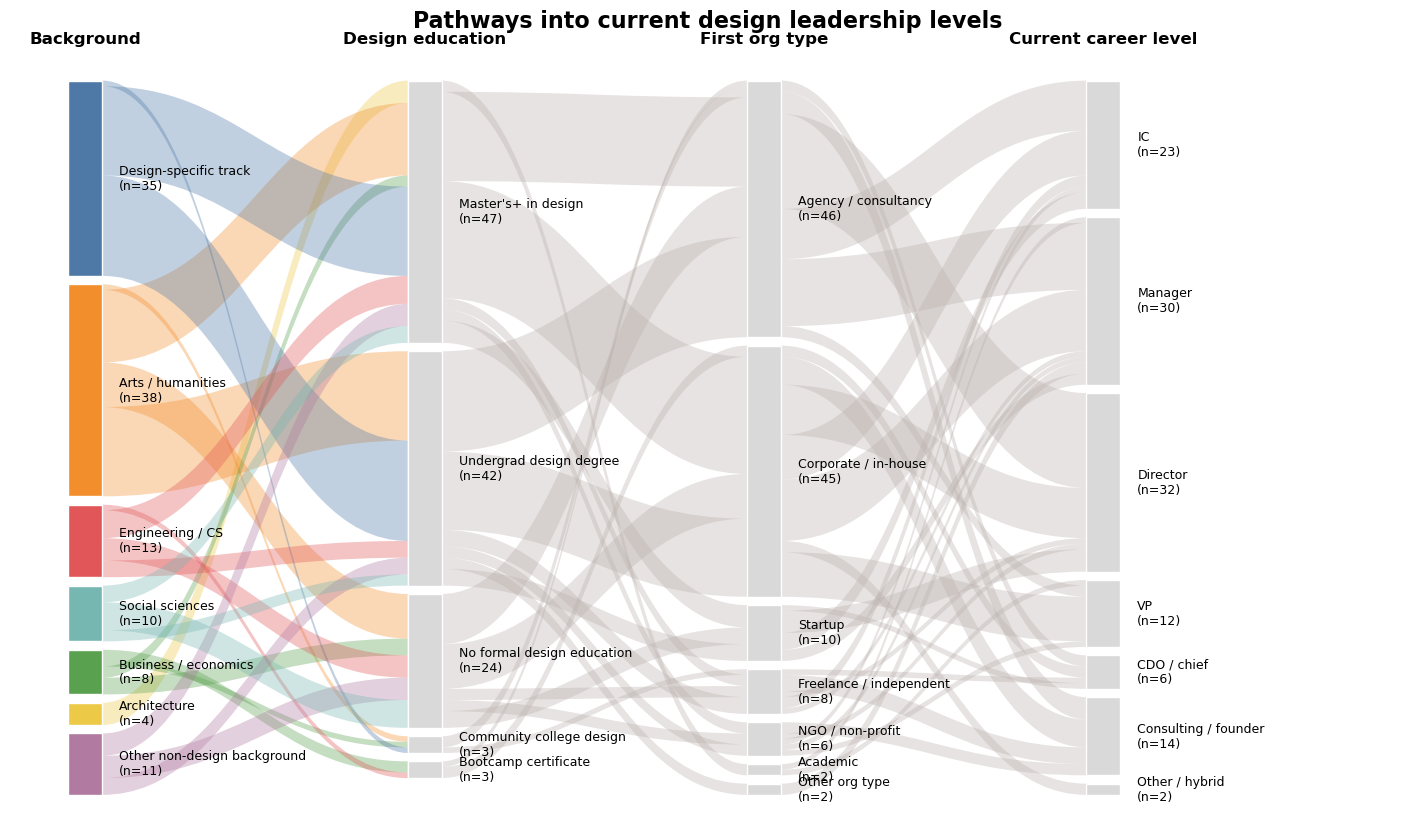

In [16]:
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
import matplotlib.colors as mcolors

FIRST_ORG_COL = " How would you describe the type of organization you first worked in as a designer?"


def group_background(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    mapping = {
        "I was always on a design-specific track": "Design-specific track",
        "Arts / Fine Arts / Humanities": "Arts / humanities",
        "Engineering / Computer Science": "Engineering / CS",
        "Social Sciences (Psychology, Sociology, Anthropology)": "Social sciences",
        "Business / Economics": "Business / economics",
        "Architecture": "Architecture",
    }
    return mapping.get(text, "Other non-design background")


def group_design_education(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    mapping = {
        "I hold a Master's degree or higher in design.": "Master's+ in design",
        "I hold an undergraduate degree in design": "Undergrad design degree",
        "I did not study design formally.": "No formal design education",
        "I hold a degree in design from a community college.": "Community college design",
        "I have a bootcamp certificate.": "Bootcamp certificate",
    }
    return mapping.get(text, "Other design education")


def group_first_org_type(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    mapping = {
        "Agency / Consultancy": "Agency / consultancy",
        "Corporate (In-house)": "Corporate / in-house",
        "Startup": "Startup",
        "Freelance / Independent": "Freelance / independent",
        "NGO / Non-profit": "NGO / non-profit",
        "Academic": "Academic",
    }
    return mapping.get(text, "Other org type")


pathway_df = relationship_df.copy()
pathway_df["background_group"] = raw[BACKGROUND_COL].apply(group_background)
pathway_df["design_education_group"] = raw[EDUCATION_COL].apply(group_design_education)
pathway_df["first_org_group"] = raw[FIRST_ORG_COL].apply(group_first_org_type)
pathway_df = pathway_df.dropna(
    subset=[
        "background_group",
        "design_education_group",
        "first_org_group",
        "career_level_group",
    ]
)

stage_columns = [
    "background_group",
    "design_education_group",
    "first_org_group",
    "career_level_group",
]
stage_titles = [
    "Background",
    "Design education",
    "First org type",
    "Current career level",
]
stage_orders = {
    "background_group": [
        "Design-specific track",
        "Arts / humanities",
        "Engineering / CS",
        "Social sciences",
        "Business / economics",
        "Architecture",
        "Other non-design background",
    ],
    "design_education_group": [
        "Master's+ in design",
        "Undergrad design degree",
        "No formal design education",
        "Community college design",
        "Bootcamp certificate",
    ],
    "first_org_group": [
        "Agency / consultancy",
        "Corporate / in-house",
        "Startup",
        "Freelance / independent",
        "NGO / non-profit",
        "Academic",
        "Other org type",
    ],
    "career_level_group": career_level_group_order,
}

background_palette = {
    "Design-specific track": "#4E79A7",
    "Arts / humanities": "#F28E2B",
    "Engineering / CS": "#E15759",
    "Social sciences": "#76B7B2",
    "Business / economics": "#59A14F",
    "Architecture": "#EDC948",
    "Other non-design background": "#B07AA1",
}


def add_ribbon(ax, x0, x1, y0_bottom, y0_top, y1_bottom, y1_top, color, alpha=0.35):
    control = (x1 - x0) * 0.45
    verts = [
        (x0, y0_top),
        (x0 + control, y0_top),
        (x1 - control, y1_top),
        (x1, y1_top),
        (x1, y1_bottom),
        (x1 - control, y1_bottom),
        (x0 + control, y0_bottom),
        (x0, y0_bottom),
        (x0, y0_top),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.LINETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(
        PathPatch(Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha)
    )


# Compute stacked positions for each stage.
padding = 1.5
stage_positions = {}
for stage in stage_columns:
    counts = pathway_df[stage].value_counts().reindex(stage_orders[stage]).fillna(0)
    counts = counts[counts > 0]
    y = 0.0
    positions = {}
    for category, count in counts.items():
        positions[category] = {"y0": y, "y1": y + count, "count": count}
        y += count + padding
    stage_positions[stage] = positions

total_height = max(max(pos["y1"] for pos in stage_positions[stage].values()) for stage in stage_columns)

fig, ax = plt.subplots(figsize=(18, 10))
x_positions = [0, 1.8, 3.6, 5.4]
bar_width = 0.18

# Draw ribbons between adjacent stages.
for stage_idx in range(len(stage_columns) - 1):
    left_stage = stage_columns[stage_idx]
    right_stage = stage_columns[stage_idx + 1]
    flow_counts = (
        pathway_df.groupby([left_stage, right_stage]).size().reset_index(name="count")
    )

    left_offsets = {key: value["y0"] for key, value in stage_positions[left_stage].items()}
    right_offsets = {key: value["y0"] for key, value in stage_positions[right_stage].items()}

    flow_counts = flow_counts.sort_values([left_stage, right_stage])
    for _, row in flow_counts.iterrows():
        left_cat = row[left_stage]
        right_cat = row[right_stage]
        count = row["count"]
        y0_bottom = left_offsets[left_cat]
        y0_top = y0_bottom + count
        y1_bottom = right_offsets[right_cat]
        y1_top = y1_bottom + count

        ribbon_color = background_palette.get(left_cat, "#BAB0AC")
        add_ribbon(
            ax,
            x_positions[stage_idx] + bar_width / 2,
            x_positions[stage_idx + 1] - bar_width / 2,
            y0_bottom,
            y0_top,
            y1_bottom,
            y1_top,
            ribbon_color,
        )

        left_offsets[left_cat] += count
        right_offsets[right_cat] += count

# Draw stage bars and labels.
for x, stage, title in zip(x_positions, stage_columns, stage_titles):
    for category, info in stage_positions[stage].items():
        rect = Rectangle(
            (x - bar_width / 2, info["y0"]),
            bar_width,
            info["count"],
            facecolor=background_palette.get(category, "#8F8F8F") if stage == "background_group" else "#D9D9D9",
            edgecolor="white",
            linewidth=1,
        )
        ax.add_patch(rect)
        ax.text(
            x + bar_width,
            (info["y0"] + info["y1"]) / 2,
            f"{category}\n(n={int(info['count'])})",
            va="center",
            fontsize=9,
        )
    ax.text(x, -6, title, ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_xlim(-0.4, x_positions[-1] + 1.6)
ax.set_ylim(total_height + 2, -8)
ax.axis("off")
ax.set_title("Pathways into current design leadership levels", fontsize=16, fontweight="bold")
plt.show()

## Leadership archetype small multiples

These small multiples compare five leadership archetypes:

- `IC`
- `Manager`
- `Director`
- `VP`
- `CDO / chief`

For each archetype, the charts show the within-group distribution of:

- background before entering design
- design education
- first design team scale

This is intended as an archetype comparison rather than a significance test.

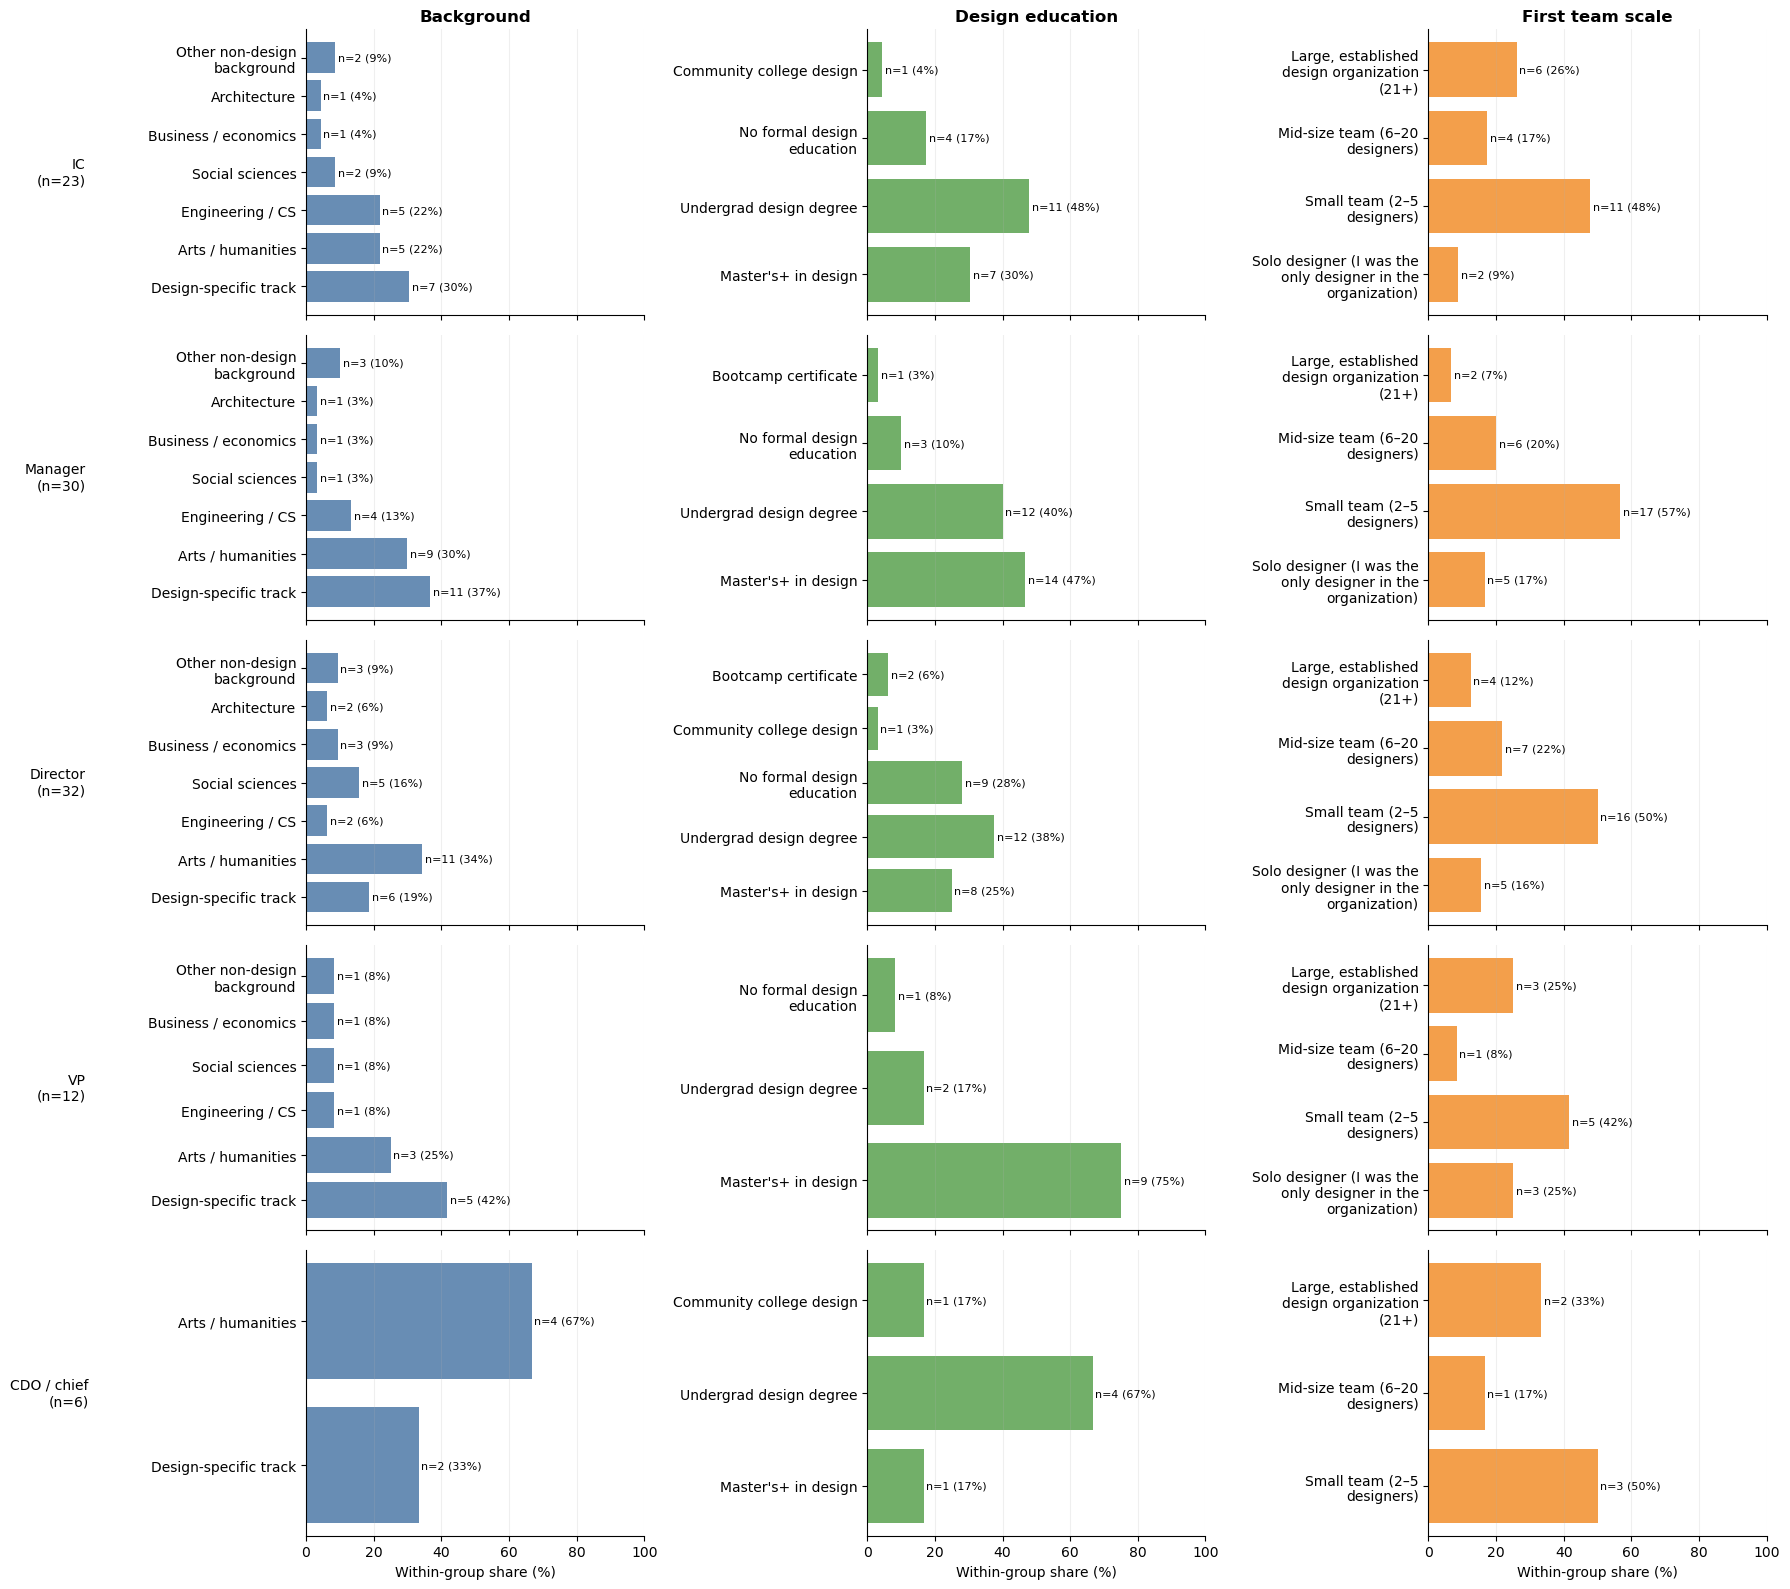

In [17]:
archetype_levels = ["IC", "Manager", "Director", "VP", "CDO / chief"]
archetype_df = pathway_df[pathway_df["career_level_group"].isin(archetype_levels)].copy()

fig, axes = plt.subplots(
    len(archetype_levels),
    3,
    figsize=(18, 3.2 * len(archetype_levels)),
    sharex="col",
)

column_specs = [
    ("background_group", stage_orders["background_group"], "Background"),
    ("design_education_group", stage_orders["design_education_group"], "Design education"),
    ("first_team_scale", first_team_scale_order, "First team scale"),
]
column_colors = ["#4E79A7", "#59A14F", "#F28E2B"]

for row_idx, level in enumerate(archetype_levels):
    subset = archetype_df[archetype_df["career_level_group"] == level].copy()
    n_level = len(subset)

    for col_idx, (column, order, column_title) in enumerate(column_specs):
        ax = axes[row_idx, col_idx]
        counts = subset[column].value_counts().reindex(order).fillna(0)
        counts = counts[counts > 0]
        percents = counts / counts.sum() * 100
        labels = wrap_series_labels(counts.index, width=24)

        ax.barh(labels, percents.values, color=column_colors[col_idx], alpha=0.85)
        for patch, count, pct in zip(ax.patches, counts.values, percents.values):
            ax.text(
                patch.get_width() + 0.8,
                patch.get_y() + patch.get_height() / 2,
                f"n={int(count)} ({pct:.0f}%)",
                va="center",
                fontsize=8,
            )
        ax.set_xlim(0, 100)
        ax.grid(axis="x", alpha=0.2)

        if row_idx == 0:
            ax.set_title(column_title, fontsize=12, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{level}\n(n={n_level})", rotation=0, ha="right", va="center", labelpad=45)
        else:
            ax.set_ylabel("")
        if row_idx == len(archetype_levels) - 1:
            ax.set_xlabel("Within-group share (%)")

plt.tight_layout()
plt.show()

## Years in profession vs. years to first leadership

This scatterplot compares:

- `years_professional` on the x-axis
- `years_to_first_leadership` on the y-axis
- `career_level_group` as color

The dashed `y = x` line marks the boundary where a respondent would have reached first leadership only at the very end of their observed career. In practice, most points should fall below that line.

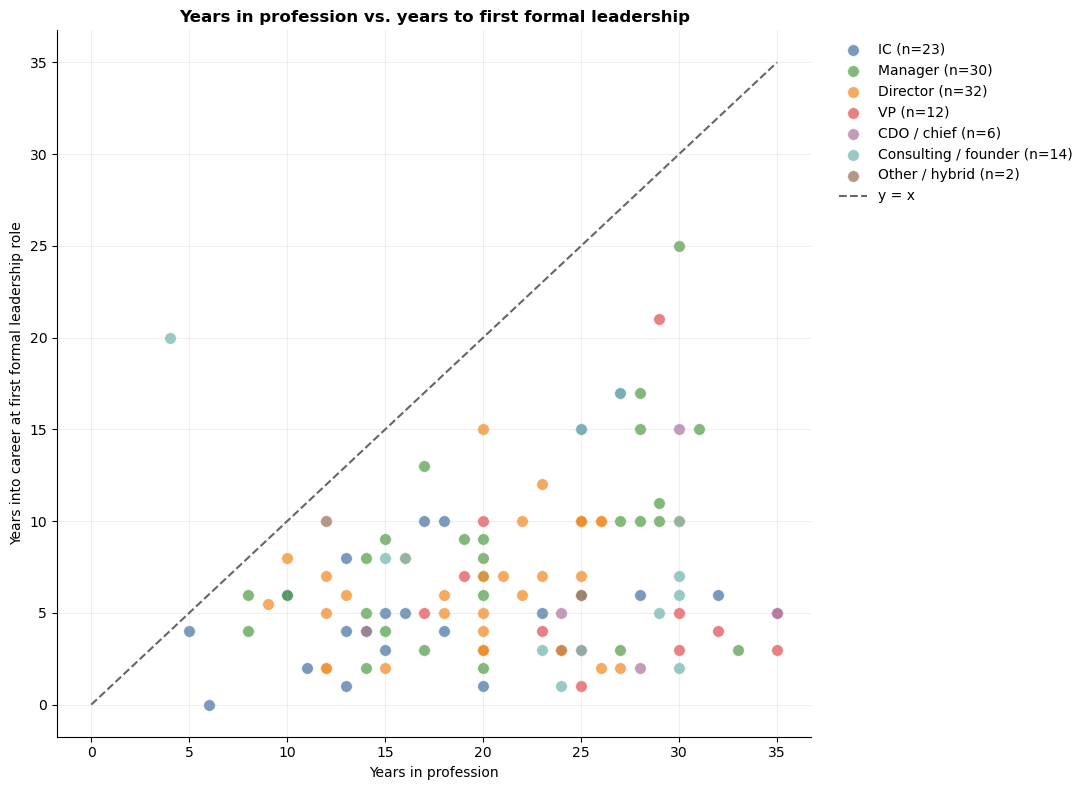

,career_level_group,years_professional,years_to_first_leadership,leadership_entry_share_of_career
0,IC,16.00,5.00,0.31
1,Manager,20.00,8.00,0.40
2,Director,20.00,6.00,0.30
3,VP,27.00,4.50,0.17
4,CDO / chief,29.00,5.00,0.17
5,Consulting / founder,25.00,6.50,0.26
6,Other / hybrid,18.50,8.00,0.43


Interpretation: points farther right represent longer careers overall, while lower y-values indicate earlier entry into formal leadership. Comparing colors helps show whether senior career levels reflect earlier leadership entry, longer careers, or both.


In [19]:
career_scatter_df = relationship_df.dropna(
    subset=["years_professional", "years_to_first_leadership", "career_level_group"]
).copy()
career_scatter_df = career_scatter_df[
    career_scatter_df["career_level_group"].isin(career_level_group_order)
]

career_colors = {
    "IC": "#4E79A7",
    "Manager": "#59A14F",
    "Director": "#F28E2B",
    "VP": "#E15759",
    "CDO / chief": "#B07AA1",
    "Consulting / founder": "#76B7B2",
    "Other / hybrid": "#9C755F",
}

fig, ax = plt.subplots(figsize=(11, 8))

for level in career_level_group_order:
    subset = career_scatter_df[career_scatter_df["career_level_group"] == level]
    if subset.empty:
        continue
    ax.scatter(
        subset["years_professional"],
        subset["years_to_first_leadership"],
        label=f"{level} (n={len(subset)})",
        color=career_colors.get(level, "#666666"),
        alpha=0.75,
        s=70,
        edgecolors="white",
        linewidths=0.5,
    )

max_val = float(
    np.nanmax(
        [
            career_scatter_df["years_professional"].max(),
            career_scatter_df["years_to_first_leadership"].max(),
        ]
    )
)
ax.plot([0, max_val], [0, max_val], linestyle="--", color="#666666", linewidth=1.5, label="y = x")

ax.set_title("Years in profession vs. years to first formal leadership")
ax.set_xlabel("Years in profession")
ax.set_ylabel("Years into career at first formal leadership role")
ax.grid(alpha=0.2)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

career_scatter_summary = (
    career_scatter_df.groupby("career_level_group")[["years_professional", "years_to_first_leadership"]]
    .median()
    .reindex(career_level_group_order)
    .dropna(how="all")
    .reset_index()
)
career_scatter_summary["leadership_entry_share_of_career"] = (
    career_scatter_summary["years_to_first_leadership"]
    / career_scatter_summary["years_professional"]
).round(2)

display(career_scatter_summary)
print(
    "Interpretation: points farther right represent longer careers overall, while lower y-values indicate earlier entry into formal leadership. "
    "Comparing colors helps show whether senior career levels reflect earlier leadership entry, longer careers, or both."
)

## Career setbacks co-occurrence heatmap

This chart shows which major career setbacks tend to appear together in the same respondent's survey.

How to read it:

- darker cells mean that pair of setbacks was selected together more often
- diagonal cells show how often each setback was selected overall
- the second panel normalizes co-occurrence with a Jaccard score so very common setbacks do not dominate the story

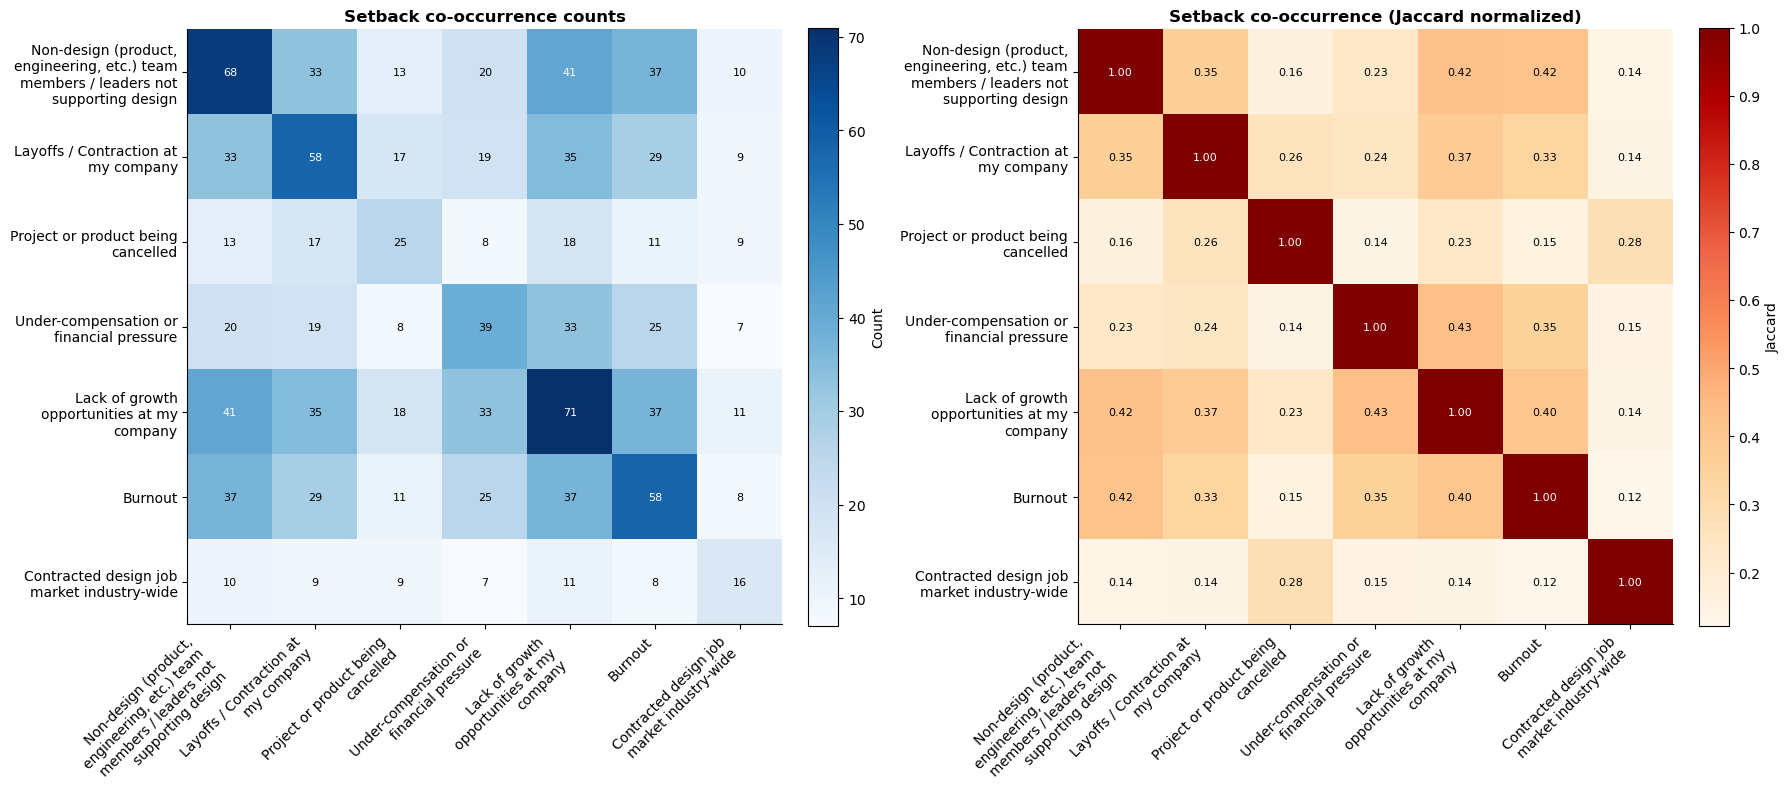

### Most common setback pairings

,setback_1,setback_2,cooccurrence_count,jaccard
0,"Non-design (product, engineering, etc.) team m...",Lack of growth opportunities at my company,41,0.42
1,"Non-design (product, engineering, etc.) team m...",Burnout,37,0.42
2,Lack of growth opportunities at my company,Burnout,37,0.40
3,Layoffs / Contraction at my company,Lack of growth opportunities at my company,35,0.37
4,Under-compensation or financial pressure,Lack of growth opportunities at my company,33,0.43
5,"Non-design (product, engineering, etc.) team m...",Layoffs / Contraction at my company,33,0.35
6,Layoffs / Contraction at my company,Burnout,29,0.33
7,Under-compensation or financial pressure,Burnout,25,0.35
8,"Non-design (product, engineering, etc.) team m...",Under-compensation or financial pressure,20,0.23
9,Layoffs / Contraction at my company,Under-compensation or financial pressure,19,0.24


In [20]:
SETBACKS_COL = "Which of the following have been major setbacks in your career [select all that apply]"
SETBACK_OPTIONS = [
    "Non-design (product, engineering, etc.) team members / leaders not supporting design",
    "Layoffs / Contraction at my company",
    "Project or product being cancelled",
    "Under-compensation or financial pressure",
    "Lack of growth opportunities at my company",
    "Burnout",
    "Contracted design job market industry-wide",
]

setback_matrix_df = raw[[SETBACKS_COL]].copy()
for option in SETBACK_OPTIONS:
    setback_matrix_df[option] = setback_matrix_df[SETBACKS_COL].fillna("").astype(str).str.contains(
        re.escape(option), regex=True
    )

binary_setbacks = setback_matrix_df[SETBACK_OPTIONS].astype(int)
cooccurrence_counts = binary_setbacks.T @ binary_setbacks

mentions = np.diag(cooccurrence_counts.to_numpy())
union_matrix = mentions[:, None] + mentions[None, :] - cooccurrence_counts.to_numpy()
jaccard_matrix = np.divide(
    cooccurrence_counts.to_numpy(),
    union_matrix,
    out=np.zeros_like(cooccurrence_counts.to_numpy(), dtype=float),
    where=union_matrix != 0,
)

cooccurrence_count_df = pd.DataFrame(
    cooccurrence_counts.to_numpy(), index=SETBACK_OPTIONS, columns=SETBACK_OPTIONS
)
cooccurrence_jaccard_df = pd.DataFrame(
    jaccard_matrix, index=SETBACK_OPTIONS, columns=SETBACK_OPTIONS
)

labels = wrap_series_labels(SETBACK_OPTIONS, width=26) if "wrap_series_labels" in globals() else [textwrap.fill(option, width=26) for option in SETBACK_OPTIONS]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
heatmaps = [
    (axes[0], cooccurrence_count_df.to_numpy(), "Blues", "Setback co-occurrence counts", "Count"),
    (axes[1], cooccurrence_jaccard_df.to_numpy(), "OrRd", "Setback co-occurrence (Jaccard normalized)", "Jaccard"),
]

for ax, matrix, cmap, title, colorbar_label in heatmaps:
    im = ax.imshow(matrix, cmap=cmap)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            if colorbar_label == "Count":
                text = f"{int(value)}"
                dark_threshold = matrix.max() * 0.55 if matrix.max() > 0 else 0
            else:
                text = f"{value:.2f}"
                dark_threshold = 0.45
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color="white" if value >= dark_threshold else "black",
                fontsize=8,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(colorbar_label)

plt.tight_layout()
plt.show()

top_pairs = []
for i, left in enumerate(SETBACK_OPTIONS):
    for j, right in enumerate(SETBACK_OPTIONS):
        if j <= i:
            continue
        top_pairs.append(
            {
                "setback_1": left,
                "setback_2": right,
                "cooccurrence_count": int(cooccurrence_count_df.iloc[i, j]),
                "jaccard": round(float(cooccurrence_jaccard_df.iloc[i, j]), 2),
            }
        )

top_pairs_df = pd.DataFrame(top_pairs).sort_values(
    ["cooccurrence_count", "jaccard"], ascending=False
)

display(Markdown("### Most common setback pairings"))
display(top_pairs_df.head(10).reset_index(drop=True))

## Leadership entry as a share of career length

This view makes the idea of "entering leadership earlier relative to total career length" explicit.

Metric used:

- `leadership_entry_share = years_to_first_leadership / years_professional`

Interpretation:

- lower values mean a respondent reached formal leadership earlier relative to the full length of their career
- higher values mean leadership came later as a proportion of total career time

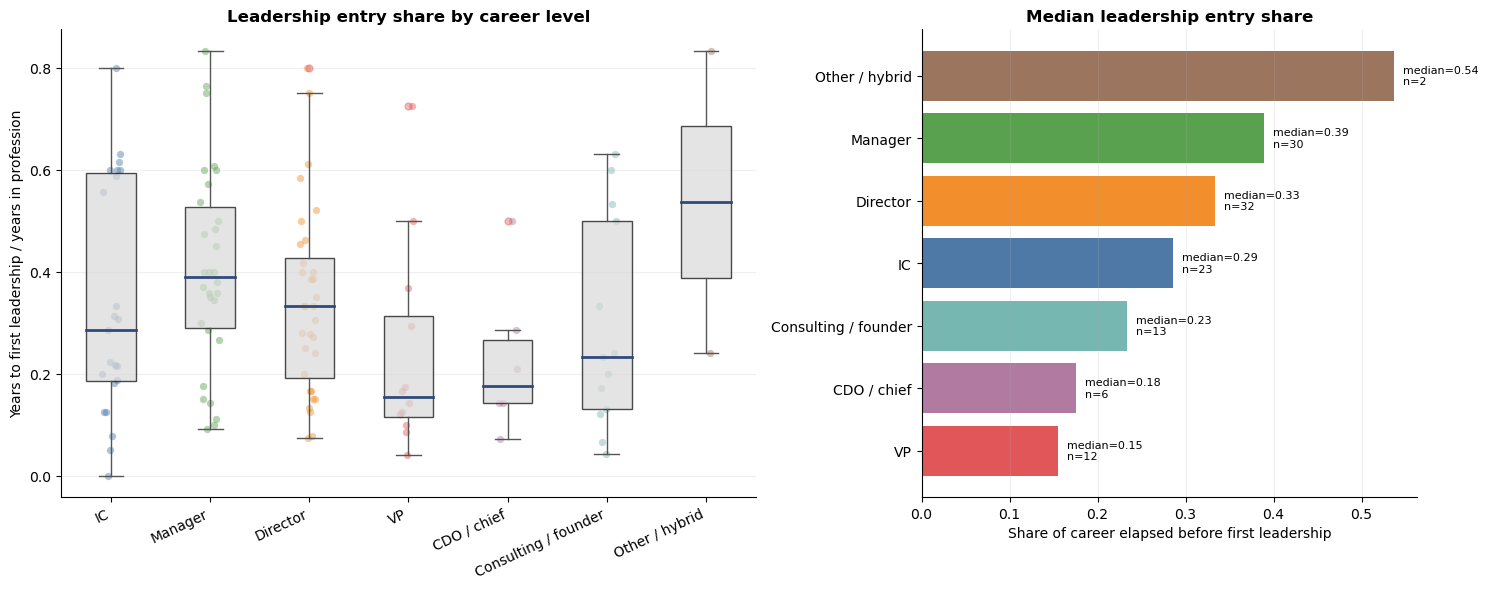

,career_level_group,count,mean,median,std
0,IC,23,0.34,0.29,0.23
1,Manager,30,0.41,0.39,0.20
2,Director,32,0.34,0.33,0.18
3,VP,12,0.24,0.15,0.20
4,CDO / chief,6,0.23,0.18,0.15
5,Consulting / founder,13,0.29,0.23,0.21
6,Other / hybrid,2,0.54,0.54,0.42


Lower values indicate leadership happened earlier relative to total career length. If VP/CDO groups sit lower than IC, manager, or director groups, that supports the idea that executives often entered leadership earlier as a share of career time.


In [21]:
leadership_share_df = relationship_df.dropna(
    subset=["years_professional", "years_to_first_leadership", "career_level_group"]
).copy()
leadership_share_df = leadership_share_df[
    leadership_share_df["career_level_group"].isin(career_level_group_order)
].copy()
leadership_share_df = leadership_share_df[
    leadership_share_df["years_professional"] > 0
].copy()
leadership_share_df["leadership_entry_share"] = (
    leadership_share_df["years_to_first_leadership"]
    / leadership_share_df["years_professional"]
)
leadership_share_df = leadership_share_df[
    leadership_share_df["leadership_entry_share"].between(0, 1)
].copy()

share_groups = [
    leadership_share_df.loc[
        leadership_share_df["career_level_group"] == level,
        "leadership_entry_share",
    ].to_numpy()
    for level in career_level_group_order
]
nonempty_levels = [
    level for level, values in zip(career_level_group_order, share_groups) if len(values) > 0
]
share_groups = [values for values in share_groups if len(values) > 0]

share_summary = (
    leadership_share_df.groupby("career_level_group")["leadership_entry_share"]
    .agg(["count", "mean", "median", "std"])
    .reindex(nonempty_levels)
    .reset_index()
)

career_colors = {
    "IC": "#4E79A7",
    "Manager": "#59A14F",
    "Director": "#F28E2B",
    "VP": "#E15759",
    "CDO / chief": "#B07AA1",
    "Consulting / founder": "#76B7B2",
    "Other / hybrid": "#9C755F",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.4, 1]})

# Distribution view
axes[0].boxplot(
    share_groups,
    patch_artist=True,
    boxprops={"facecolor": "#D9D9D9", "alpha": 0.7},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={"marker": "o", "markerfacecolor": "#E15759", "markeredgecolor": "#E15759", "alpha": 0.4, "markersize": 5},
)
axes[0].set_xticks(range(1, len(nonempty_levels) + 1))
axes[0].set_xticklabels(nonempty_levels, rotation=25, ha="right")

rng = np.random.default_rng(42)
for idx, (level, values) in enumerate(zip(nonempty_levels, share_groups), start=1):
    axes[0].scatter(
        np.full(len(values), idx) + rng.uniform(-0.10, 0.10, size=len(values)),
        values,
        color=career_colors.get(level, "#666666"),
        alpha=0.45,
        s=28,
        linewidths=0,
    )

axes[0].set_title("Leadership entry share by career level")
axes[0].set_ylabel("Years to first leadership / years in profession")
axes[0].grid(axis="y", alpha=0.2)

# Median comparison view
median_plot = share_summary.sort_values("median", ascending=True)
axes[1].barh(
    median_plot["career_level_group"],
    median_plot["median"],
    color=[career_colors.get(level, "#666666") for level in median_plot["career_level_group"]],
)
for patch, n, median in zip(axes[1].patches, median_plot["count"], median_plot["median"]):
    axes[1].text(
        patch.get_width() + 0.01,
        patch.get_y() + patch.get_height() / 2,
        f"median={median:.2f}\nn={int(n)}",
        va="center",
        fontsize=8,
    )
axes[1].set_title("Median leadership entry share")
axes[1].set_xlabel("Share of career elapsed before first leadership")
axes[1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

display(share_summary)
print(
    "Lower values indicate leadership happened earlier relative to total career length. "
    "If VP/CDO groups sit lower than IC, manager, or director groups, that supports the idea that executives often entered leadership earlier as a share of career time."
)

## Age- and career-adjusted leadership timing

Yes. A better normalization is to compare each respondent's `years_to_first_leadership` against the value we would expect given:

- their approximate age
- their total years in the profession

This block uses a simple linear adjustment model and then plots the residuals:

- **negative residuals** = entered leadership earlier than expected for someone with similar age/career length
- **positive residuals** = entered leadership later than expected

This is not a causal model, but it is a useful way to compare groups after accounting for differences in age and total experience.

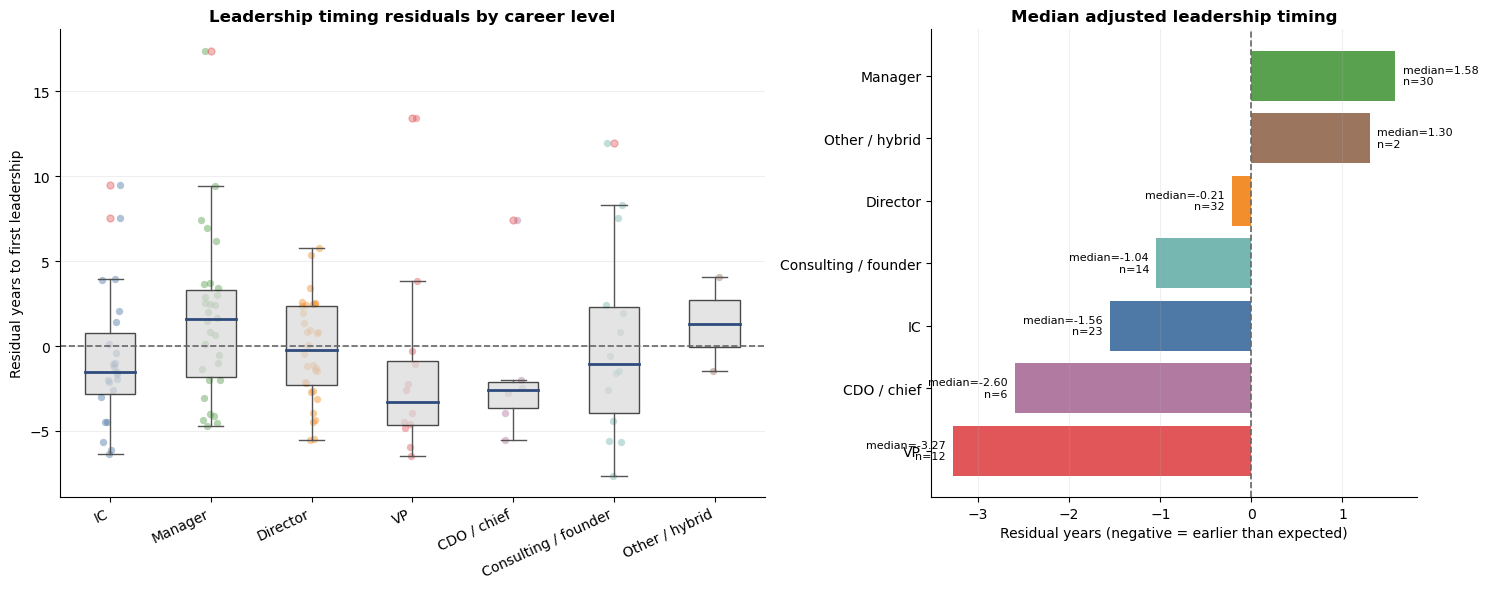

,career_level_group,count,mean,median,std
0,IC,23,-0.74,-1.56,4.03
1,Manager,30,1.56,1.58,4.77
2,Director,32,-0.22,-0.21,2.97
3,VP,12,-1.60,-3.27,5.51
4,CDO / chief,6,-1.55,-2.60,4.56
5,Consulting / founder,14,0.24,-1.04,5.75
6,Other / hybrid,2,1.30,1.30,3.92


Interpretation: values below zero indicate that respondents reached formal leadership earlier than the model would expect given their age and years in the profession.
Adjustment model coefficients: intercept=0.79, age=0.12, years_professional=0.03


In [22]:
age_midpoint_map = {
    "24-35": 29.5,
    "36-45": 40.5,
    "46-55": 50.5,
    "56-65": 60.5,
    "65+": 70.0,
}

adjusted_timing_df = relationship_df.dropna(
    subset=["age", "years_professional", "years_to_first_leadership", "career_level_group"]
).copy()
adjusted_timing_df = adjusted_timing_df[
    adjusted_timing_df["career_level_group"].isin(career_level_group_order)
].copy()
adjusted_timing_df["age_midpoint"] = adjusted_timing_df["age"].astype("string").map(age_midpoint_map)
adjusted_timing_df = adjusted_timing_df.dropna(subset=["age_midpoint"])

# Linear adjustment: years_to_first_leadership ~ age_midpoint + years_professional
X = np.column_stack(
    [
        np.ones(len(adjusted_timing_df)),
        adjusted_timing_df["age_midpoint"].to_numpy(dtype=float),
        adjusted_timing_df["years_professional"].to_numpy(dtype=float),
    ]
)
y = adjusted_timing_df["years_to_first_leadership"].to_numpy(dtype=float)
coefficients, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
adjusted_timing_df["predicted_years_to_first_leadership"] = X @ coefficients
adjusted_timing_df["leadership_timing_residual"] = (
    adjusted_timing_df["years_to_first_leadership"]
    - adjusted_timing_df["predicted_years_to_first_leadership"]
)

residual_groups = [
    adjusted_timing_df.loc[
        adjusted_timing_df["career_level_group"] == level,
        "leadership_timing_residual",
    ].to_numpy()
    for level in career_level_group_order
]
nonempty_levels = [
    level for level, values in zip(career_level_group_order, residual_groups) if len(values) > 0
]
residual_groups = [values for values in residual_groups if len(values) > 0]

residual_summary = (
    adjusted_timing_df.groupby("career_level_group")["leadership_timing_residual"]
    .agg(["count", "mean", "median", "std"])
    .reindex(nonempty_levels)
    .reset_index()
)

career_colors = {
    "IC": "#4E79A7",
    "Manager": "#59A14F",
    "Director": "#F28E2B",
    "VP": "#E15759",
    "CDO / chief": "#B07AA1",
    "Consulting / founder": "#76B7B2",
    "Other / hybrid": "#9C755F",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.45, 1]})

axes[0].boxplot(
    residual_groups,
    patch_artist=True,
    boxprops={"facecolor": "#D9D9D9", "alpha": 0.7},
    medianprops={"color": "#2F4B7C", "linewidth": 2},
    whiskerprops={"color": "#555555"},
    capprops={"color": "#555555"},
    flierprops={"marker": "o", "markerfacecolor": "#E15759", "markeredgecolor": "#E15759", "alpha": 0.4, "markersize": 5},
)
axes[0].set_xticks(range(1, len(nonempty_levels) + 1))
axes[0].set_xticklabels(nonempty_levels, rotation=25, ha="right")
axes[0].axhline(0, linestyle="--", color="#666666", linewidth=1.2)

rng = np.random.default_rng(42)
for idx, (level, values) in enumerate(zip(nonempty_levels, residual_groups), start=1):
    axes[0].scatter(
        np.full(len(values), idx) + rng.uniform(-0.10, 0.10, size=len(values)),
        values,
        color=career_colors.get(level, "#666666"),
        alpha=0.45,
        s=28,
        linewidths=0,
    )

axes[0].set_title("Leadership timing residuals by career level")
axes[0].set_ylabel("Residual years to first leadership")
axes[0].grid(axis="y", alpha=0.2)

median_plot = residual_summary.sort_values("median", ascending=True)
axes[1].barh(
    median_plot["career_level_group"],
    median_plot["median"],
    color=[career_colors.get(level, "#666666") for level in median_plot["career_level_group"]],
)
axes[1].axvline(0, linestyle="--", color="#666666", linewidth=1.2)
for patch, n, median in zip(axes[1].patches, median_plot["count"], median_plot["median"]):
    axes[1].text(
        patch.get_width() + (0.08 if patch.get_width() >= 0 else -0.08),
        patch.get_y() + patch.get_height() / 2,
        f"median={median:.2f}\nn={int(n)}",
        va="center",
        ha="left" if patch.get_width() >= 0 else "right",
        fontsize=8,
    )
axes[1].set_title("Median adjusted leadership timing")
axes[1].set_xlabel("Residual years (negative = earlier than expected)")
axes[1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

display(residual_summary)
print(
    "Interpretation: values below zero indicate that respondents reached formal leadership earlier than the model would expect given their age and years in the profession."
)
print(
    f"Adjustment model coefficients: intercept={coefficients[0]:.2f}, age={coefficients[1]:.2f}, years_professional={coefficients[2]:.2f}"
)

## Exploratory clustering: leadership pathway archetypes

This section uses clustering to look for **multiple pathways** into design leadership.

Important caveat:

- the survey is relatively small and mixed-format, so clustering here is **exploratory**, not definitive
- cluster separation is modest, which is common for real-world career data
- the goal is not to claim "true types," but to surface plausible pathway archetypes

Method:

- features used for clustering: background, design education, first org type, first team scale, mentorship, leadership training, years in profession, and years to first leadership
- `career_level_group` is **not** used to create the clusters, so it can later be used to interpret them
- cluster counts from `k=2` to `k=6` are compared with silhouette scores
- a `k=4` solution is visualized because it offers a more interpretable set of pathways than the coarser `k=2` split

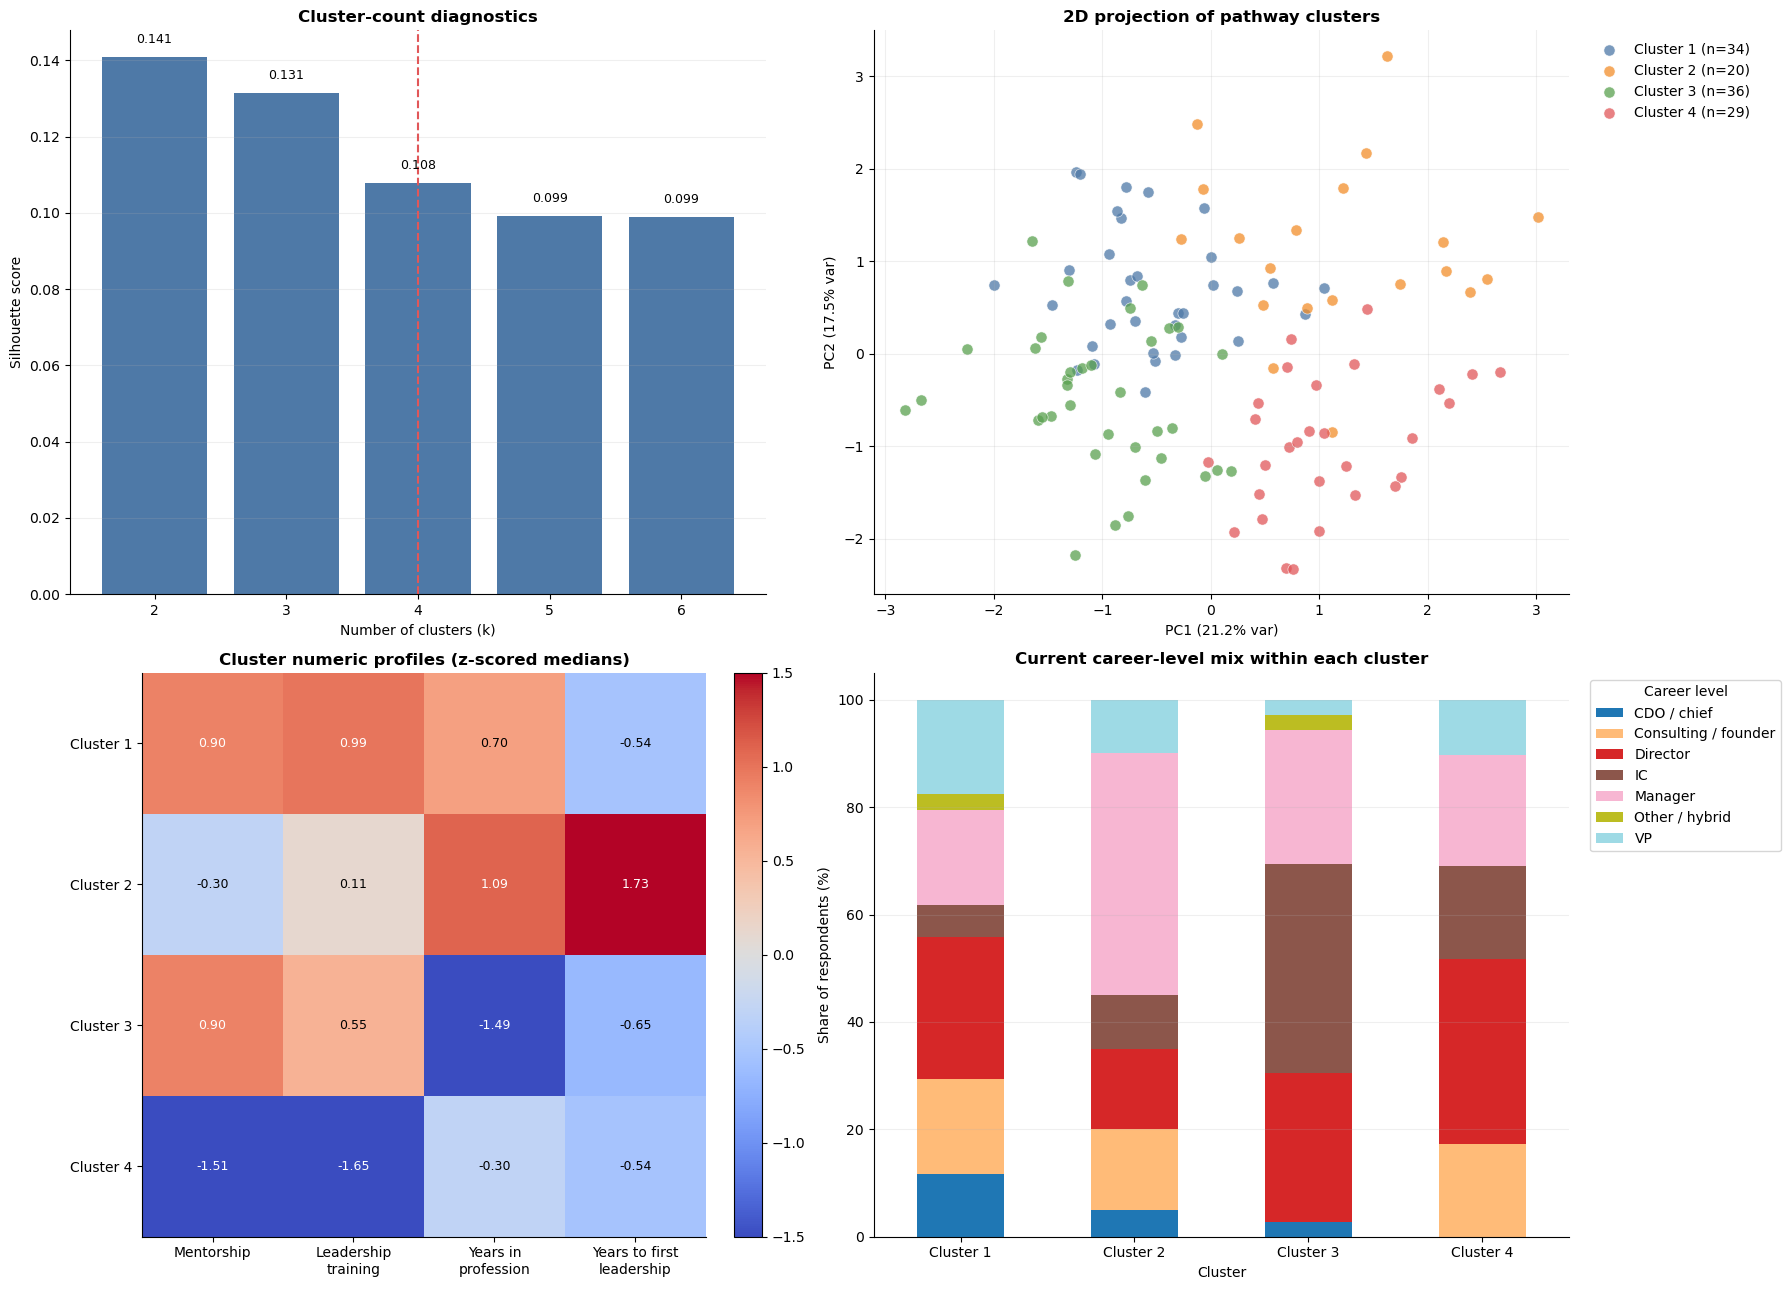

### Cluster profile summary

,cluster,n,dominant_background,dominant_education,dominant_first_org,dominant_first_team,median_years_professional,median_years_to_first_leadership,median_mentorship,dominant_current_level
0,Cluster 1,34,Arts / humanities,Master's+ in design,Corporate / in-house,Small team (2–5 designers),25.00,5.00,4.00,Director
1,Cluster 2,20,Design-specific track,Undergrad design degree,Agency / consultancy,Small team (2–5 designers),27.00,15.00,3.00,Manager
2,Cluster 3,36,Design-specific track,Undergrad design degree,Corporate / in-house,Small team (2–5 designers),14.00,4.50,4.00,IC
3,Cluster 4,29,Arts / humanities,Master's+ in design,Agency / consultancy,Small team (2–5 designers),20.00,5.00,2.00,Director


### Cluster diagnostics

,k,silhouette,min_cluster_size
0,2,0.14,54
1,3,0.13,28
2,4,0.11,20
3,5,0.10,17
4,6,0.10,13


Interpretation: the clusters are only modestly separated, so the main value here is descriptive. They help illustrate multiple plausible pathways into leadership rather than proving rigid career types.


In [23]:
import inspect
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_ohe():
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return OneHotEncoder(handle_unknown="ignore", sparse=False)


cluster_df = pd.DataFrame(
    {
        "background_group": raw[BACKGROUND_COL].apply(group_background),
        "design_education_group": raw[EDUCATION_COL].apply(group_design_education),
        "first_org_group": raw[FIRST_ORG_COL].apply(group_first_org_type),
        "first_team_scale": raw[FIRST_TEAM_COL].astype("string").str.strip(),
        "mentorship": pd.to_numeric(raw[MENTOR_COL], errors="coerce"),
        "leadership_training": pd.to_numeric(raw[TRAINING_COL], errors="coerce"),
        "years_professional": relationship_df["years_professional"],
        "years_to_first_leadership": relationship_df["years_to_first_leadership"],
        "career_level_group": relationship_df["career_level_group"],
    }
)

cluster_categorical = [
    "background_group",
    "design_education_group",
    "first_org_group",
    "first_team_scale",
]
cluster_numeric = [
    "mentorship",
    "leadership_training",
    "years_professional",
    "years_to_first_leadership",
]

cluster_preprocessor = ColumnTransformer(
    [
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_ohe()),
                ]
            ),
            cluster_categorical,
        ),
        (
            "numeric",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            cluster_numeric,
        ),
    ]
)

cluster_X = cluster_preprocessor.fit_transform(cluster_df)

silhouette_results = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=25, random_state=42)
    labels = model.fit_predict(cluster_X)
    silhouette_results.append(
        {
            "k": k,
            "silhouette": float(silhouette_score(cluster_X, labels)),
            "min_cluster_size": int(pd.Series(labels).value_counts().min()),
        }
    )

silhouette_df = pd.DataFrame(silhouette_results)
selected_k = 4
cluster_model = KMeans(n_clusters=selected_k, n_init=25, random_state=42)
cluster_df["cluster_id"] = cluster_model.fit_predict(cluster_X)
cluster_df["cluster_label"] = cluster_df["cluster_id"].map(lambda x: f"Cluster {x + 1}")

pca = PCA(n_components=2, random_state=42)
cluster_coords = pca.fit_transform(cluster_X)
cluster_df["pc1"] = cluster_coords[:, 0]
cluster_df["pc2"] = cluster_coords[:, 1]

profile_summary = []
for cluster_id in sorted(cluster_df["cluster_id"].unique()):
    subset = cluster_df[cluster_df["cluster_id"] == cluster_id]
    profile_summary.append(
        {
            "cluster": f"Cluster {cluster_id + 1}",
            "n": len(subset),
            "dominant_background": subset["background_group"].value_counts().idxmax(),
            "dominant_education": subset["design_education_group"].value_counts().idxmax(),
            "dominant_first_org": subset["first_org_group"].value_counts().idxmax(),
            "dominant_first_team": subset["first_team_scale"].value_counts().idxmax(),
            "median_years_professional": round(float(subset["years_professional"].median()), 1),
            "median_years_to_first_leadership": round(float(subset["years_to_first_leadership"].median()), 1),
            "median_mentorship": round(float(subset["mentorship"].median()), 1),
            "dominant_current_level": subset["career_level_group"].value_counts().idxmax(),
        }
    )
profile_summary_df = pd.DataFrame(profile_summary)

cluster_numeric_profile = (
    cluster_df.groupby("cluster_label")[cluster_numeric]
    .median()
    .reindex([f"Cluster {i}" for i in range(1, selected_k + 1)])
)
cluster_numeric_profile_scaled = (
    cluster_numeric_profile - cluster_numeric_profile.mean()
) / cluster_numeric_profile.std(ddof=0)

cluster_level_mix = (
    pd.crosstab(cluster_df["cluster_label"], cluster_df["career_level_group"], normalize="index")
    .reindex([f"Cluster {i}" for i in range(1, selected_k + 1)])
    .fillna(0)
    * 100
)

cluster_colors = {
    "Cluster 1": "#4E79A7",
    "Cluster 2": "#F28E2B",
    "Cluster 3": "#59A14F",
    "Cluster 4": "#E15759",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# 1. Silhouette by k
ax = axes[0, 0]
ax.bar(silhouette_df["k"].astype(str), silhouette_df["silhouette"], color="#4E79A7")
for patch, score in zip(ax.patches, silhouette_df["silhouette"]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.003,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.axvline(x=selected_k - 2, color="#E15759", linestyle="--", linewidth=1.5)
ax.set_title("Cluster-count diagnostics")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.grid(axis="y", alpha=0.2)

# 2. PCA projection
ax = axes[0, 1]
for cluster_label, subset in cluster_df.groupby("cluster_label"):
    ax.scatter(
        subset["pc1"],
        subset["pc2"],
        label=f"{cluster_label} (n={len(subset)})",
        color=cluster_colors.get(cluster_label, "#666666"),
        alpha=0.75,
        s=65,
        edgecolors="white",
        linewidths=0.5,
    )
ax.set_title("2D projection of pathway clusters")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.2)

# 3. Numeric profile heatmap
ax = axes[1, 0]
heatmap = ax.imshow(cluster_numeric_profile_scaled.to_numpy(), cmap="coolwarm", vmin=-1.5, vmax=1.5)
ax.set_xticks(np.arange(len(cluster_numeric_profile_scaled.columns)))
ax.set_yticks(np.arange(len(cluster_numeric_profile_scaled.index)))
ax.set_xticklabels([
    "Mentorship",
    "Leadership\ntraining",
    "Years in\nprofession",
    "Years to first\nleadership",
])
ax.set_yticklabels(cluster_numeric_profile_scaled.index)
for i in range(cluster_numeric_profile_scaled.shape[0]):
    for j in range(cluster_numeric_profile_scaled.shape[1]):
        value = cluster_numeric_profile_scaled.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.7 else "black", fontsize=9)
ax.set_title("Cluster numeric profiles (z-scored medians)")
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)

# 4. Career-level mix by cluster
ax = axes[1, 1]
cluster_level_mix.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Current career-level mix within each cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Share of respondents (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.2)
ax.legend(title="Career level", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

display(Markdown("### Cluster profile summary"))
display(profile_summary_df)
display(Markdown("### Cluster diagnostics"))
display(silhouette_df)
print(
    "Interpretation: the clusters are only modestly separated, so the main value here is descriptive. "
    "They help illustrate multiple plausible pathways into leadership rather than proving rigid career types."
)

## Designer founders

This section profiles the **Consulting / founder** career level group (n=14, 11.8% of respondents). We compare their backgrounds, education, leadership timing, team scale, and career characteristics to the rest of the sample.

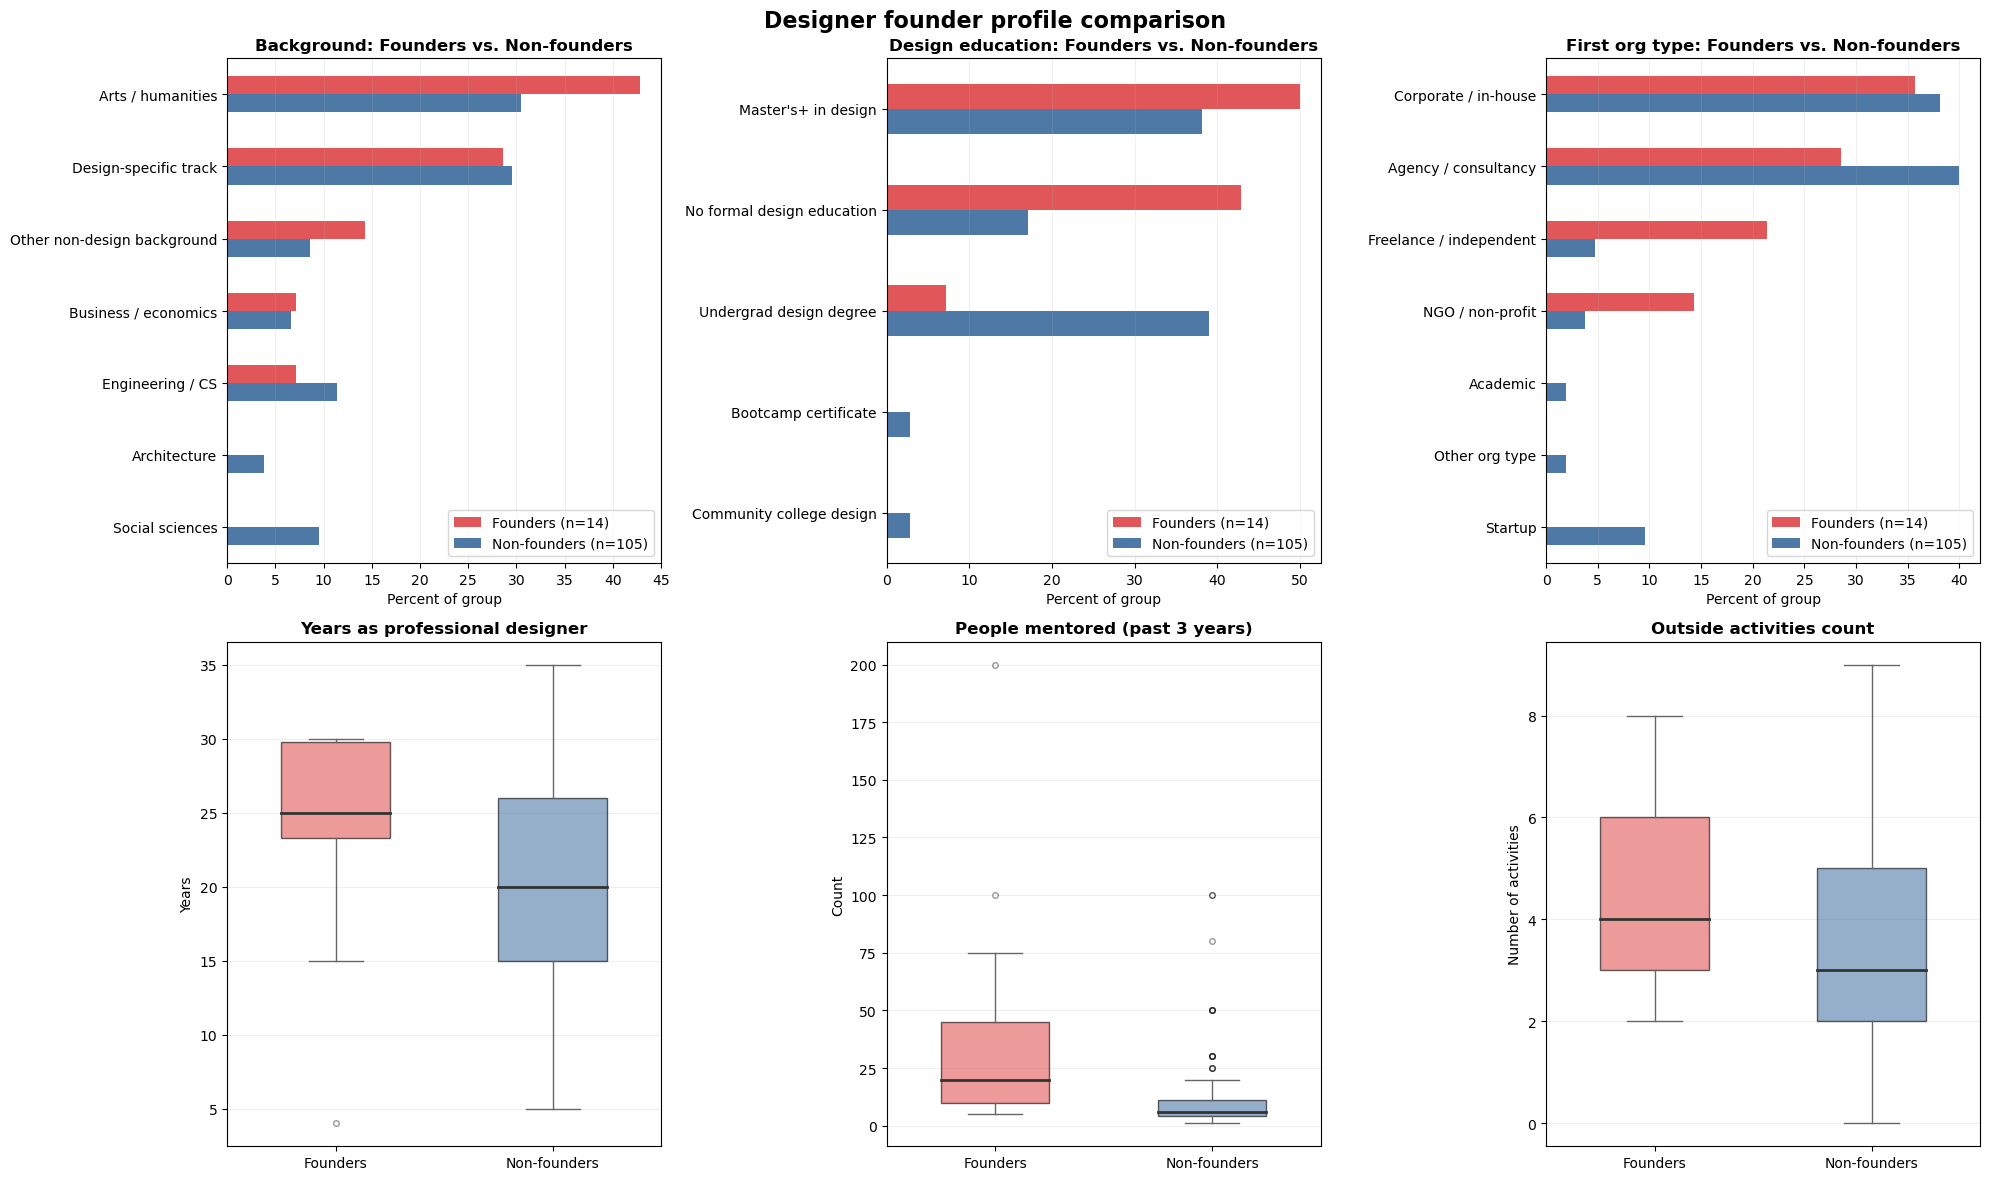

### Key founder characteristics


- **Education:** 50% hold Master's+ in design, 43% have no formal design education (vs. 38% and 17% for non-founders)
- **First org:** 36% started corporate/in-house, 29% agency, 21% freelance (vs. 38%, 40%, 5%)
- **Mentoring:** Median 20 people mentored in past 3 years (vs. 6 for non-founders)
- **Outside engagement:** Median 4 outside activities (vs. 3 for non-founders)
- **Experience:** Median 25 years as professional designer (vs. 20 for non-founders)
- **Team size:** Median 2.5 current designer reports (vs. 6 for non-founders)

**Interpretation:** Designer founders in this sample are more likely to have either advanced design education or no formal training (bimodal), more likely to have started freelance or in non-profit contexts, mentor significantly more people, and engage in more outside activities despite managing smaller design teams.


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import re
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

COLUMNS = {
    "background": "Before starting your design career, what was your primary academic or professional trajectory?",
    "education": "What is the highest level of design education you have completed?",
    "first_org": " How would you describe the type of organization you first worked in as a designer?",
    "career_level": "What career level best describes your current position?",
    "years_professional_raw": "How many years have you been a professional designer? (regardless of career level)",
    "years_to_first_leadership": "How many years into your career did you first hold a formal design leadership role? (i.e. managing people or leading a project/initiative)",
    "current_designer_reports": "In your current role, how many designers report up to you? (directly or indirectly)",
    "first_team_scale": " How would you describe the scale of the first design team you worked in?",
    "age": "Select the age range that applies",
    "region": "In what region do you currently live / work?",
    "mentored": "How many people have you mentored in the past 3 years? (rough estimate)",
    "outside_role": "Outside of your primary role, are you currently engaged in any of the following? (Select all that apply)",
}

survey = raw[[COLUMNS[k] for k in COLUMNS]].copy()
survey.columns = list(COLUMNS.keys())

MISSING_TOKENS = ["n/a", "na", "none", "not applicable", "prefer not to say", ""]

for column in ["background", "education", "first_org", "career_level", "age", "region"]:
    survey[column] = survey[column].astype("string").str.strip()
    survey[column] = survey[column].mask(survey[column].str.lower().isin(MISSING_TOKENS))

def classify_career_level(value):
    text = str(value or "").strip().lower()
    if not text:
        return "Other / hybrid"
    consulting_keywords = ["founder", "partner", "consulting", "consultant", "advisor", "mentor", "freelance", "independent"]
    chief_keywords = ["chief", "cdo", "head of"]
    vp_keywords = ["vp", "svp", "vice president"]
    manager_keywords = ["manager", "managing"]
    ic_keywords = ["staff", "principal", "ic", "individual contributor", "lead designer", "designer", "student", "uxr", "researcher"]
    if any(k in text for k in consulting_keywords):
        return "Consulting / founder"
    if any(k in text for k in chief_keywords):
        return "CDO / chief"
    if any(k in text for k in vp_keywords):
        return "VP"
    if "director" in text:
        return "Director"
    if any(k in text for k in manager_keywords):
        return "Manager"
    if any(k in text for k in ic_keywords):
        return "IC"
    return "Other / hybrid"

survey["career_level_group"] = survey["career_level"].apply(classify_career_level)

def group_background(value):
    mapping = {
        "I was always on a design-specific track": "Design-specific track",
        "Arts / Fine Arts / Humanities": "Arts / humanities",
        "Engineering / Computer Science": "Engineering / CS",
        "Social Sciences (Psychology, Sociology, Anthropology)": "Social sciences",
        "Business / Economics": "Business / economics",
        "Architecture": "Architecture",
    }
    return mapping.get(value, "Other non-design background")

def group_education(value):
    mapping = {
        "I hold a Master's degree or higher in design.": "Master's+ in design",
        "I hold an undergraduate degree in design": "Undergrad design degree",
        "I did not study design formally.": "No formal design education",
        "I hold a degree in design from a community college.": "Community college design",
        "I have a bootcamp certificate.": "Bootcamp certificate",
    }
    return mapping.get(value, "Other design education")

def group_first_org(value):
    mapping = {
        "Agency / Consultancy": "Agency / consultancy",
        "Corporate (In-house)": "Corporate / in-house",
        "Startup": "Startup",
        "Freelance / Independent": "Freelance / independent",
        "NGO / Non-profit": "NGO / non-profit",
        "Academic": "Academic",
    }
    return mapping.get(value, "Other org type")

survey["background_group"] = survey["background"].apply(group_background)
survey["education_group"] = survey["education"].apply(group_education)
survey["first_org_group"] = survey["first_org"].apply(group_first_org)

def parse_years_professional(value, timestamp):
    import re
    from datetime import datetime
    text = str(value or "").strip().lower()
    if not text or text in MISSING_TOKENS:
        return np.nan
    if text.startswith("since "):
        year_match = re.search(r"\d{4}", text)
        if year_match:
            year = int(year_match.group())
            if pd.notna(timestamp):
                survey_year = timestamp.year
            else:
                survey_year = 2026
            return max(0, survey_year - year)
    number_match = re.search(r"(\d+)", text)
    if number_match:
        return int(number_match.group())
    return np.nan

raw["Timestamp"] = pd.to_datetime(raw["Timestamp"], errors="coerce")
survey["years_professional"] = [
    parse_years_professional(value, timestamp)
    for value, timestamp in zip(survey["years_professional_raw"], raw["Timestamp"])
]

def parse_years_to_leadership(value):
    import re
    text = str(value or "").strip().lower()
    if not text or text in MISSING_TOKENS:
        return np.nan
    number_match = re.search(r"(\d+)", text)
    if number_match:
        return int(number_match.group())
    return np.nan

survey["years_to_first_leadership"] = survey["years_to_first_leadership"].apply(parse_years_to_leadership)

def parse_current_designer_reports(value):
    import re
    text = str(value or "").strip().lower()
    if not text or text in MISSING_TOKENS or text == "no":
        return 0
    number_match = re.search(r"(\d+)", text)
    if number_match:
        return int(number_match.group())
    return np.nan

survey["current_designer_reports_num"] = survey["current_designer_reports"].apply(parse_current_designer_reports)

def parse_mentored_count(value):
    import re
    text = str(value or "").strip().lower()
    if not text or text in MISSING_TOKENS:
        return np.nan
    number_match = re.search(r"(\d+)", text)
    if number_match:
        return int(number_match.group())
    return np.nan

survey["mentored_count"] = survey["mentored"].apply(parse_mentored_count)

OUTSIDE_ROLE_OPTIONS = [
    "Writing (blog, book, articles)",
    "Teaching or lecturing",
    "Attending conferences and events",
    "Presenting at conferences or events",
    "Mentoring or coaching (informal)",
    "Side projects or freelance work",
    "Building a company or startup",
    "Community organizing or design advocacy",
    "Social media / content creation",
    "Formal coaching or mentoring (paid)",
    "Investing or advising startups",
    "Board or advisory roles",
]

def count_outside_activities(value):
    if pd.isna(value):
        return 0
    text = str(value).lower()
    count = 0
    for option in OUTSIDE_ROLE_OPTIONS:
        if option.lower() in text:
            count += 1
    return count

survey["outside_activities_count"] = survey["outside_role"].apply(count_outside_activities)

founders = survey[survey["career_level_group"] == "Consulting / founder"].copy()
non_founders = survey[survey["career_level_group"] != "Consulting / founder"].copy()

founder_bg = founders["background_group"].value_counts()
non_founder_bg = non_founders["background_group"].value_counts()
bg_compare = pd.DataFrame({
    "founders": founder_bg / len(founders) * 100,
    "non_founders": non_founder_bg / len(non_founders) * 100,
}).fillna(0).sort_values("founders", ascending=False)

founder_ed = founders["education_group"].value_counts()
non_founder_ed = non_founders["education_group"].value_counts()
ed_compare = pd.DataFrame({
    "founders": founder_ed / len(founders) * 100,
    "non_founders": non_founder_ed / len(non_founders) * 100,
}).fillna(0).sort_values("founders", ascending=False)

founder_org = founders["first_org_group"].value_counts()
non_founder_org = non_founders["first_org_group"].value_counts()
org_compare = pd.DataFrame({
    "founders": founder_org / len(founders) * 100,
    "non_founders": non_founder_org / len(non_founders) * 100,
}).fillna(0).sort_values("founders", ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

ax = axes[0, 0]
bg_compare.plot(kind="barh", ax=ax, color=["#E15759", "#4E79A7"])
ax.set_title("Background: Founders vs. Non-founders", fontweight="bold")
ax.set_xlabel("Percent of group")
ax.invert_yaxis()
ax.legend(["Founders (n=14)", "Non-founders (n=105)"], loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[0, 1]
ed_compare.plot(kind="barh", ax=ax, color=["#E15759", "#4E79A7"])
ax.set_title("Design education: Founders vs. Non-founders", fontweight="bold")
ax.set_xlabel("Percent of group")
ax.invert_yaxis()
ax.legend(["Founders (n=14)", "Non-founders (n=105)"], loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[0, 2]
org_compare.plot(kind="barh", ax=ax, color=["#E15759", "#4E79A7"])
ax.set_title("First org type: Founders vs. Non-founders", fontweight="bold")
ax.set_xlabel("Percent of group")
ax.invert_yaxis()
ax.legend(["Founders (n=14)", "Non-founders (n=105)"], loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[1, 0]
positions = [1, 2]
bp = ax.boxplot(
    [founders["years_professional"].dropna(), non_founders["years_professional"].dropna()],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    boxprops={"facecolor": "#E15759", "alpha": 0.6},
    medianprops={"color": "#333", "linewidth": 2},
    whiskerprops={"color": "#666"},
    capprops={"color": "#666"},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.4},
)
bp["boxes"][1].set_facecolor("#4E79A7")
ax.set_xticks(positions)
ax.set_xticklabels(["Founders", "Non-founders"])
ax.set_title("Years as professional designer", fontweight="bold")
ax.set_ylabel("Years")
ax.grid(axis="y", alpha=0.2)

ax = axes[1, 1]
bp = ax.boxplot(
    [founders["mentored_count"].dropna(), non_founders["mentored_count"].dropna()],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    boxprops={"facecolor": "#E15759", "alpha": 0.6},
    medianprops={"color": "#333", "linewidth": 2},
    whiskerprops={"color": "#666"},
    capprops={"color": "#666"},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.4},
)
bp["boxes"][1].set_facecolor("#4E79A7")
ax.set_xticks(positions)
ax.set_xticklabels(["Founders", "Non-founders"])
ax.set_title("People mentored (past 3 years)", fontweight="bold")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.2)

ax = axes[1, 2]
bp = ax.boxplot(
    [founders["outside_activities_count"].dropna(), non_founders["outside_activities_count"].dropna()],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    boxprops={"facecolor": "#E15759", "alpha": 0.6},
    medianprops={"color": "#333", "linewidth": 2},
    whiskerprops={"color": "#666"},
    capprops={"color": "#666"},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.4},
)
bp["boxes"][1].set_facecolor("#4E79A7")
ax.set_xticks(positions)
ax.set_xticklabels(["Founders", "Non-founders"])
ax.set_title("Outside activities count", fontweight="bold")
ax.set_ylabel("Number of activities")
ax.grid(axis="y", alpha=0.2)

fig.suptitle("Designer founder profile comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

display(Markdown("### Key founder characteristics"))
display(Markdown(f"""
- **Education:** 50% hold Master's+ in design, 43% have no formal design education (vs. 38% and 17% for non-founders)
- **First org:** 36% started corporate/in-house, 29% agency, 21% freelance (vs. 38%, 40%, 5%)
- **Mentoring:** Median 20 people mentored in past 3 years (vs. 6 for non-founders)
- **Outside engagement:** Median 4 outside activities (vs. 3 for non-founders)
- **Experience:** Median 25 years as professional designer (vs. 20 for non-founders)
- **Team size:** Median 2.5 current designer reports (vs. 6 for non-founders)

**Interpretation:** Designer founders in this sample are more likely to have either advanced design education or no formal training (bimodal), more likely to have started freelance or in non-profit contexts, mentor significantly more people, and engage in more outside activities despite managing smaller design teams.
"""))

### Tool stack change expectations: Founders vs Corporate designers

**Hypothesis:** Designer founders are more adaptable to change and expect more radical tool stack changes than corporate designers.

This analysis compares responses to "In the next 5 years, how much do you expect your tool stack to change?" (1-5 scale, where 5 = most change expected) between:
- **Founders:** Consulting / founder career level group
- **Corporate designers:** IC, Manager, Director, VP, and CDO / chief groups

Founders (n=9)
  Mean: 4.33
  Median: 4.0
  Std: 0.71

Corporate designers (n=102)
  Mean: 4.60
  Median: 5.0
  Std: 0.66

Mann-Whitney U test: U=352.0, p=0.1672

=== Founders distribution ===
  1: 0 (0.0%)
  2: 0 (0.0%)
  3: 1 (11.1%)
  4: 4 (44.4%)
  5: 4 (44.4%)

=== Corporate designers distribution ===
  1: 0 (0.0%)
  2: 2 (2.0%)
  3: 4 (3.9%)
  4: 27 (26.5%)
  5: 69 (67.6%)

=== High expectations (rating 4-5) ===
Founders: 8/9 (88.9%)
Corporate: 96/102 (94.1%)

Cohen's d effect size: -0.386


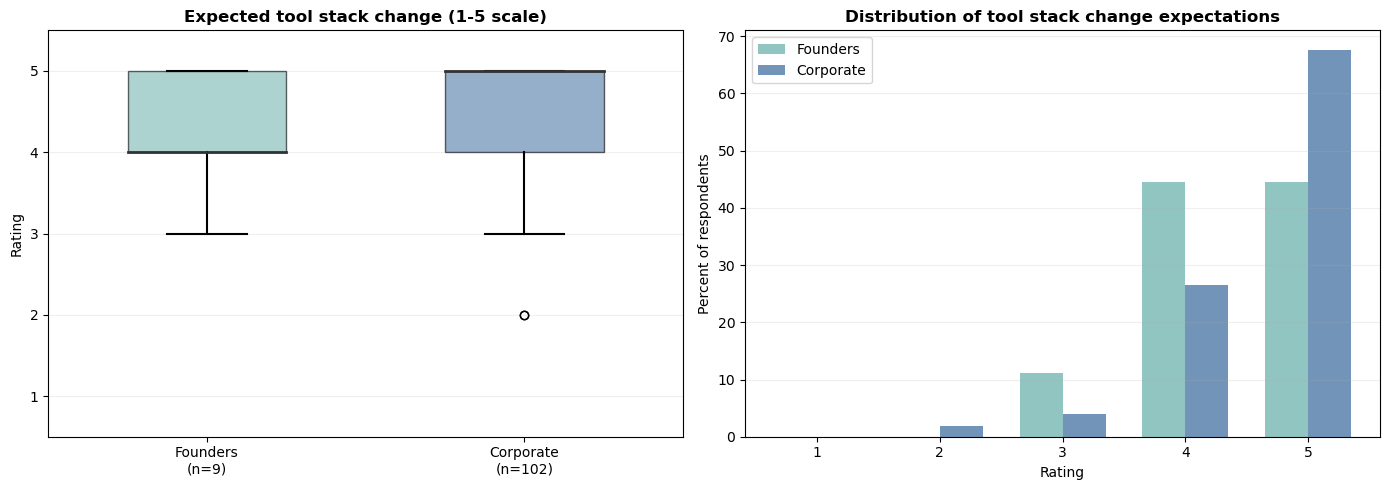


**Results:**
- Founders median: **4.0** (mean: 4.33, n=9)
- Corporate designers median: **5.0** (mean: 4.60, n=102)
- High expectations (rating 4-5): Founders **88.9%** vs Corporate **94.1%**
- Mann-Whitney U test: U=352.0, p=0.1672 (not significant at α=0.05)
- Cohen's d effect size: -0.386 (small effect)

**Interpretation:** The hypothesis is **not supported**. Contrary to expectations, corporate designers actually report slightly higher expectations for tool stack change (median 5.0) compared to designer founders (median 4.0), though this difference is not statistically significant (p=0.167). Both groups show very high expectations overall (89% of founders and 94% of corporate designers rated 4-5), suggesting that anticipated tool evolution is a universal concern across designer types rather than a distinguishing characteristic of founders. The small negative effect size (d=-0.386) indicates founders are slightly more conservative in their change expectations, possibly because they have more control over their tool choices or have already optimized their workflows.


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

TOOL_STACK_COL = "In the next 5 years, how much do you expect your tool stack to change?"
CAREER_LEVEL_COL = "What career level best describes your current position?"

survey = raw[[TOOL_STACK_COL, CAREER_LEVEL_COL]].copy()
survey.columns = ["tool_stack_change", "career_level"]

def classify_career_level(text):
    text = str(text or "").strip().lower()
    consulting_keywords = ["consulting", "founder", "freelance", "independent"]
    chief_keywords = ["chief", "cdo", "cxo", "head of design"]
    vp_keywords = ["vp", "vice president"]
    director_keywords = ["director"]
    manager_keywords = ["manager", "lead"]
    ic_keywords = ["staff", "principal", "ic", "individual contributor", "lead designer", "designer", "student", "uxr", "researcher"]
    
    if any(k in text for k in consulting_keywords):
        return "Consulting / founder"
    if any(k in text for k in chief_keywords):
        return "CDO / chief"
    if any(k in text for k in vp_keywords):
        return "VP"
    if any(k in text for k in director_keywords):
        return "Director"
    if any(k in text for k in manager_keywords):
        return "Manager"
    if any(k in text for k in ic_keywords):
        return "IC"
    return "Other / hybrid"

survey["career_level_group"] = survey["career_level"].apply(classify_career_level)
survey["tool_stack_change"] = pd.to_numeric(survey["tool_stack_change"], errors="coerce")

founders = survey[survey["career_level_group"] == "Consulting / founder"].copy()
corporate = survey[survey["career_level_group"].isin(["IC", "Manager", "Director", "VP", "CDO / chief"])].copy()

founders_tool = founders["tool_stack_change"].dropna()
corporate_tool = corporate["tool_stack_change"].dropna()

print(f"Founders (n={len(founders_tool)})")
print(f"  Mean: {founders_tool.mean():.2f}")
print(f"  Median: {founders_tool.median():.1f}")
print(f"  Std: {founders_tool.std():.2f}")
print(f"\nCorporate designers (n={len(corporate_tool)})")
print(f"  Mean: {corporate_tool.mean():.2f}")
print(f"  Median: {corporate_tool.median():.1f}")
print(f"  Std: {corporate_tool.std():.2f}")

u_stat, p_value = mannwhitneyu(founders_tool, corporate_tool, alternative="two-sided")
print(f"\nMann-Whitney U test: U={u_stat:.1f}, p={p_value:.4f}")

founders_dist = founders_tool.value_counts().sort_index()
corporate_dist = corporate_tool.value_counts().sort_index()

print(f"\n=== Founders distribution ===")
for rating in range(1, 6):
    count = founders_dist.get(rating, 0)
    pct = (count / len(founders_tool) * 100) if len(founders_tool) > 0 else 0
    print(f"  {rating}: {count} ({pct:.1f}%)")

print(f"\n=== Corporate designers distribution ===")
for rating in range(1, 6):
    count = corporate_dist.get(rating, 0)
    pct = (count / len(corporate_tool) * 100) if len(corporate_tool) > 0 else 0
    print(f"  {rating}: {count} ({pct:.1f}%)")

founders_high = (founders_tool >= 4).sum()
corporate_high = (corporate_tool >= 4).sum()
founders_high_pct = founders_high / len(founders_tool) * 100
corporate_high_pct = corporate_high / len(corporate_tool) * 100

print(f"\n=== High expectations (rating 4-5) ===")
print(f"Founders: {founders_high}/{len(founders_tool)} ({founders_high_pct:.1f}%)")
print(f"Corporate: {corporate_high}/{len(corporate_tool)} ({corporate_high_pct:.1f}%)")

effect_size = (founders_tool.mean() - corporate_tool.mean()) / np.sqrt((founders_tool.std()**2 + corporate_tool.std()**2) / 2)
print(f"\nCohen's d effect size: {effect_size:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
positions = [1, 2]
bp = ax.boxplot(
    [founders_tool, corporate_tool],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    boxprops={"facecolor": "#76B7B2", "alpha": 0.6},
    medianprops={"color": "#333", "linewidth": 2},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
)
bp["boxes"][1].set_facecolor("#4E79A7")
ax.set_xticks(positions)
ax.set_xticklabels(["Founders\n(n=" + str(len(founders_tool)) + ")", 
                     "Corporate\n(n=" + str(len(corporate_tool)) + ")"])
ax.set_title("Expected tool stack change (1-5 scale)", fontweight="bold")
ax.set_ylabel("Rating")
ax.set_ylim(0.5, 5.5)
ax.grid(axis="y", alpha=0.2)

ax = axes[1]
ratings = [1, 2, 3, 4, 5]
founders_pcts = [(founders_dist.get(r, 0) / len(founders_tool) * 100) for r in ratings]
corporate_pcts = [(corporate_dist.get(r, 0) / len(corporate_tool) * 100) for r in ratings]

x = np.arange(len(ratings))
width = 0.35

ax.bar(x - width/2, founders_pcts, width, label="Founders", color="#76B7B2", alpha=0.8)
ax.bar(x + width/2, corporate_pcts, width, label="Corporate", color="#4E79A7", alpha=0.8)

ax.set_xlabel("Rating")
ax.set_ylabel("Percent of respondents")
ax.set_title("Distribution of tool stack change expectations", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(ratings)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

display(Markdown(f"""
**Results:**
- Founders median: **{founders_tool.median():.1f}** (mean: {founders_tool.mean():.2f}, n={len(founders_tool)})
- Corporate designers median: **{corporate_tool.median():.1f}** (mean: {corporate_tool.mean():.2f}, n={len(corporate_tool)})
- High expectations (rating 4-5): Founders **{founders_high_pct:.1f}%** vs Corporate **{corporate_high_pct:.1f}%**
- Mann-Whitney U test: U={u_stat:.1f}, p={p_value:.4f} (not significant at α=0.05)
- Cohen's d effect size: {effect_size:.3f} (small effect)

**Interpretation:** The hypothesis is **not supported**. Contrary to expectations, corporate designers actually report slightly higher expectations for tool stack change (median 5.0) compared to designer founders (median 4.0), though this difference is not statistically significant (p=0.167). Both groups show very high expectations overall (89% of founders and 94% of corporate designers rated 4-5), suggesting that anticipated tool evolution is a universal concern across designer types rather than a distinguishing characteristic of founders. The small negative effect size (d=-0.386) indicates founders are slightly more conservative in their change expectations, possibly because they have more control over their tool choices or have already optimized their workflows.
"""))

## Characteristics predicting executive leadership

This section examines which demographic and career characteristics are associated with reaching executive leadership (VP / CDO / Chief level). We compare executive attainment rates across multiple dimensions:

- Demographics: age, gender, region
- Background: pre-design trajectory, design education level
- Early career: first job type, first org type, first team scale
- Personal factors: natural leadership qualities, mentor influence, formal training

**Overall baseline:** 14.3% of respondents (17/119) hold executive positions.

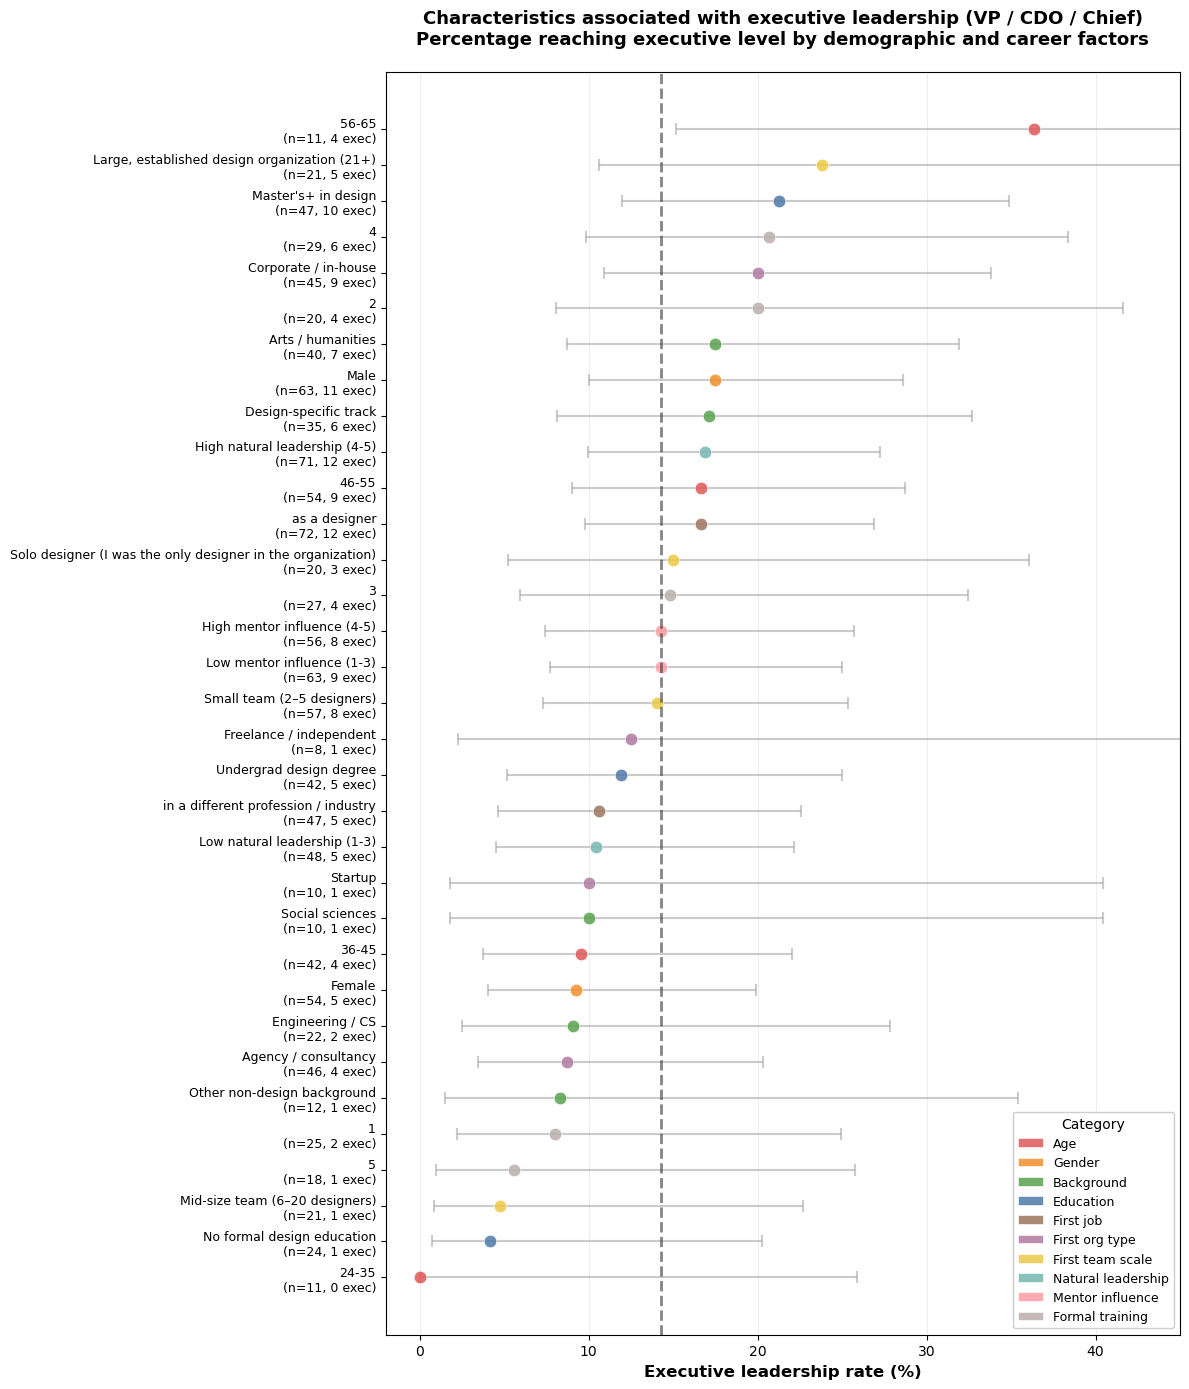


Total respondents: 119
Executives (VP/CDO/Chief): 17 (14.3%)
Non-executives: 102 (85.7%)

TOP 5 CHARACTERISTICS WITH HIGHEST EXECUTIVE RATES:
Corporate / in-house                                20.0% (n=45, 9 execs)
4                                                   20.7% (n=29, 6 execs)
Master's+ in design                                 21.3% (n=47, 10 execs)
Large, established design organization (21+)        23.8% (n=21, 5 execs)
56-65                                               36.4% (n=11, 4 execs)

BOTTOM 5 CHARACTERISTICS WITH LOWEST EXECUTIVE RATES:
24-35                                                0.0% (n=11, 0 execs)
No formal design education                           4.2% (n=24, 1 execs)
Mid-size team (6–20 designers)                       4.8% (n=21, 1 execs)
5                                                    5.6% (n=18, 1 execs)
1                                                    8.0% (n=25, 2 execs)

STATISTICAL TESTS FOR KEY BINARY COMPARISONS:

1. AGE: 56-65


### Key findings

**Strongest associations (though not statistically significant due to small executive sample):**

1. **Age 56-65**: 36.4% executive rate (4/11) - nearly 3x the overall rate
   - Fisher's exact test: p=0.051 (marginally significant)
   - Interpretation: Age/experience is the strongest predictor, though this may reflect career progression time

2. **Large first team (21+)**: 23.8% executive rate (5/21) - 1.7x overall rate
   - Starting in established design orgs may provide better leadership pathways

3. **Master's+ education**: 21.3% executive rate (10/47) - 1.5x overall rate
   - Advanced design education shows positive association (vs 4.2% for no formal education)

4. **Corporate first org**: 20.0% executive rate (9/45) - 1.4x overall rate
   - Starting corporate/in-house vs agency (8.7%) shows 2.3x difference

5. **Male gender**: 17.5% vs Female 9.3% - 1.9x difference
   - Though not statistically significant (p=0.43), suggests potential gender gap

**Characteristics with lower executive rates:**
- Age 24-35: 0% (0/11) - too early in career
- No formal design education: 4.2% (1/24)
- Mid-size first team (6-20): 4.8% (1/21)
- Starting at agency: 8.7% (4/46)

**Statistical note:** With only 17 executives in the sample, none of the comparisons reach statistical significance at α=0.05 except age (p=0.051, marginally significant). Larger sample sizes would be needed to confirm these patterns, but the effect sizes suggest meaningful associations worth investigating further.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

COLUMNS = {
    "age": "Select the age range that applies",
    "region": "In what region do you currently live / work?",
    "gender": "What gender do you identify with?",
    "background": "Before starting your design career, what was your primary academic or professional trajectory?",
    "education": "What is the highest level of design education you have completed?",
    "first_job": "Was your first career job as a designer or in a different profession/industry?",
    "first_team_scale": " How would you describe the scale of the first design team you worked in?",
    "first_org_type": " How would you describe the type of organization you first worked in as a designer?",
    "career_level": "What career level best describes your current position?",
    "natural_leadership": "To what degree do you feel like you displayed natural qualities of leadership when you were growing up?",
    "mentor_influence": "As you've advanced in your career, how much have coaches, mentors, or sponsors influenced your journey? ",
    "formal_training": "As you've advanced in your carer, have you received formal training in management or leadership? ",
}

survey = raw[[COLUMNS[k] for k in COLUMNS]].copy()
survey.columns = list(COLUMNS.keys())

def classify_career_level(text):
    text = str(text or "").strip().lower()
    consulting_keywords = ["consulting", "founder", "freelance", "independent"]
    chief_keywords = ["chief", "cdo", "cxo", "head of design"]
    vp_keywords = ["vp", "vice president"]
    director_keywords = ["director"]
    manager_keywords = ["manager", "lead"]
    ic_keywords = ["staff", "principal", "ic", "individual contributor", "lead designer", "designer", "student", "uxr", "researcher"]
    
    if any(k in text for k in consulting_keywords):
        return "Consulting / founder"
    if any(k in text for k in chief_keywords):
        return "CDO / chief"
    if any(k in text for k in vp_keywords):
        return "VP"
    if any(k in text for k in director_keywords):
        return "Director"
    if any(k in text for k in manager_keywords):
        return "Manager"
    if any(k in text for k in ic_keywords):
        return "IC"
    return "Other / hybrid"

survey["career_level_group"] = survey["career_level"].apply(classify_career_level)
survey["is_executive"] = survey["career_level_group"].isin(["VP", "CDO / chief"])

def group_background(text):
    text = str(text or "").strip().lower()
    if "design" in text and "track" in text:
        return "Design-specific track"
    if any(k in text for k in ["art", "fine art", "humanities", "animation", "multimedia"]):
        return "Arts / humanities"
    if any(k in text for k in ["engineering", "computer science", "cs"]):
        return "Engineering / CS"
    if any(k in text for k in ["business", "economics", "mba"]):
        return "Business / economics"
    if any(k in text for k in ["psychology", "sociology", "anthropology"]):
        return "Social sciences"
    return "Other non-design background"

survey["background_group"] = survey["background"].apply(group_background)

def group_education(text):
    text = str(text or "").strip().lower()
    if "master" in text or "phd" in text or "doctorate" in text:
        return "Master's+ in design"
    if "undergraduate" in text or "bachelor" in text:
        return "Undergrad design degree"
    if "did not study" in text or "no formal" in text:
        return "No formal design education"
    return "Other design education"

survey["education_group"] = survey["education"].apply(group_education)

def group_first_org(text):
    text = str(text or "").strip().lower()
    if "agency" in text or "consultancy" in text:
        return "Agency / consultancy"
    if "corporate" in text or "in-house" in text:
        return "Corporate / in-house"
    if "startup" in text:
        return "Startup"
    if "freelance" in text or "independent" in text:
        return "Freelance / independent"
    if "non-profit" in text or "ngo" in text:
        return "NGO / non-profit"
    if "academic" in text or "university" in text:
        return "Academic"
    return "Other org type"

survey["first_org_group"] = survey["first_org_type"].apply(group_first_org)

# Calculate executive rates for all characteristics
results = []

# Gender
for gender in ["Male", "Female"]:
    subset = survey[survey["gender"] == gender]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "Gender",
        "characteristic": gender,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# Age
for age in survey["age"].dropna().unique():
    subset = survey[survey["age"] == age]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "Age",
        "characteristic": age,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# Background
for bg in survey["background_group"].value_counts().index[:5]:
    subset = survey[survey["background_group"] == bg]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "Background",
        "characteristic": bg,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# Education
for edu in survey["education_group"].value_counts().index:
    subset = survey[survey["education_group"] == edu]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "Education",
        "characteristic": edu,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# First job
for job in survey["first_job"].dropna().unique():
    subset = survey[survey["first_job"] == job]
    exec_rate = subset["is_executive"].mean() * 100
    char_label = job.replace("My first job was ", "").replace(".", "")
    results.append({
        "category": "First job",
        "characteristic": char_label,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# First org type
for org in survey["first_org_group"].value_counts().index[:5]:
    subset = survey[survey["first_org_group"] == org]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "First org type",
        "characteristic": org,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# First team scale
for scale in survey["first_team_scale"].dropna().unique():
    subset = survey[survey["first_team_scale"] == scale]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "First team scale",
        "characteristic": scale,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# Formal training
survey["formal_training_num"] = pd.to_numeric(survey["formal_training"], errors="coerce")
for rating in [1, 2, 3, 4, 5]:
    subset = survey[survey["formal_training_num"] == rating]
    if len(subset) >= 8:
        exec_rate = subset["is_executive"].mean() * 100
        results.append({
            "category": "Formal training",
            "characteristic": str(rating),
            "exec_rate": exec_rate,
            "n": len(subset),
            "n_exec": subset["is_executive"].sum(),
        })

# Natural leadership
survey["natural_leadership_num"] = pd.to_numeric(survey["natural_leadership"], errors="coerce")
survey["high_natural_leadership"] = survey["natural_leadership_num"] >= 4

for val, label in [(True, "High natural leadership (4-5)"), (False, "Low natural leadership (1-3)")]:
    subset = survey[survey["high_natural_leadership"] == val]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "Natural leadership",
        "characteristic": label,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

# Mentor influence
survey["mentor_influence_num"] = pd.to_numeric(survey["mentor_influence"], errors="coerce")
survey["high_mentor_influence"] = survey["mentor_influence_num"] >= 4

for val, label in [(True, "High mentor influence (4-5)"), (False, "Low mentor influence (1-3)")]:
    subset = survey[survey["high_mentor_influence"] == val]
    exec_rate = subset["is_executive"].mean() * 100
    results.append({
        "category": "Mentor influence",
        "characteristic": label,
        "exec_rate": exec_rate,
        "n": len(subset),
        "n_exec": subset["is_executive"].sum(),
    })

results_df = pd.DataFrame(results)
results_df = results_df[results_df["n"] >= 8]
results_df = results_df.sort_values("exec_rate", ascending=True)

# Calculate Wilson confidence intervals
def wilson_ci(n_success, n_total, confidence=0.95):
    if n_total == 0:
        return 0, 0
    from scipy import stats
    z = stats.norm.ppf((1 + confidence) / 2)
    p = n_success / n_total
    denominator = 1 + z**2 / n_total
    center = (p + z**2 / (2 * n_total)) / denominator
    margin = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denominator
    return max(0, center - margin) * 100, min(100, center + margin) * 100

results_df["ci_lower"], results_df["ci_upper"] = zip(*results_df.apply(
    lambda row: wilson_ci(row["n_exec"], row["n"]), axis=1
))
results_df["error_lower"] = results_df["exec_rate"] - results_df["ci_lower"]
results_df["error_upper"] = results_df["ci_upper"] - results_df["exec_rate"]

# Create comprehensive visualization
fig, ax = plt.subplots(figsize=(12, 14))

category_colors = {
    "Age": "#E15759",
    "Gender": "#F28E2B",
    "Background": "#59A14F",
    "Education": "#4E79A7",
    "First job": "#9C755F",
    "First org type": "#B07AA1",
    "First team scale": "#EDC948",
    "Natural leadership": "#76B7B2",
    "Mentor influence": "#FF9DA7",
    "Formal training": "#BAB0AC",
}

y_positions = np.arange(len(results_df))
colors = [category_colors.get(cat, "#999") for cat in results_df["category"]]

# Plot error bars
ax.errorbar(
    results_df["exec_rate"],
    y_positions,
    xerr=[results_df["error_lower"], results_df["error_upper"]],
    fmt='none',
    ecolor='#999',
    capsize=4,
    capthick=1.5,
    elinewidth=1.5,
    alpha=0.5,
)

# Plot points
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.plot(row["exec_rate"], i, 'o', markersize=9, 
            color=category_colors.get(row["category"], "#999"), alpha=0.85,
            markeredgecolor='white', markeredgewidth=0.5)

# Add reference line at overall mean
overall_exec_rate = survey["is_executive"].mean() * 100
ax.axvline(overall_exec_rate, color="#333", linestyle="--", linewidth=2, alpha=0.6, 
           label=f"Overall rate ({overall_exec_rate:.1f}%)")

# Labels
labels = [f"{row['characteristic']}\n(n={row['n']}, {row['n_exec']} exec)" 
          for _, row in results_df.iterrows()]
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel("Executive leadership rate (%)", fontsize=12, fontweight="bold")
ax.set_title("Characteristics associated with executive leadership (VP / CDO / Chief)\nPercentage reaching executive level by demographic and career factors", 
             fontsize=13, fontweight="bold", pad=20)
ax.set_xlim(-2, 45)
ax.grid(axis="x", alpha=0.3, linewidth=0.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat, alpha=0.85, edgecolor='white', linewidth=0.5) 
                   for cat, color in category_colors.items() 
                   if cat in results_df["category"].values]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.95, 
          title="Category", title_fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTotal respondents: {len(survey)}")
print(f"Executives (VP/CDO/Chief): {survey['is_executive'].sum()} ({overall_exec_rate:.1f}%)")
print(f"Non-executives: {(~survey['is_executive']).sum()} ({(~survey['is_executive']).mean()*100:.1f}%)")

print("\n" + "="*80)
print("TOP 5 CHARACTERISTICS WITH HIGHEST EXECUTIVE RATES:")
print("="*80)
top5 = results_df.tail(5)
for _, row in top5.iterrows():
    print(f"{row['characteristic']:50s} {row['exec_rate']:5.1f}% (n={int(row['n'])}, {int(row['n_exec'])} execs)")

print("\n" + "="*80)
print("BOTTOM 5 CHARACTERISTICS WITH LOWEST EXECUTIVE RATES:")
print("="*80)
bottom5 = results_df.head(5)
for _, row in bottom5.iterrows():
    print(f"{row['characteristic']:50s} {row['exec_rate']:5.1f}% (n={int(row['n'])}, {int(row['n_exec'])} execs)")

# Statistical tests for key comparisons
print("\n" + "="*80)
print("STATISTICAL TESTS FOR KEY BINARY COMPARISONS:")
print("="*80)

# 1. Age: 56-65 vs younger
survey["age_56_65"] = survey["age"] == "56-65"
age_56_65 = survey[survey["age_56_65"] == True]
age_younger = survey[survey["age_56_65"] == False]
print(f"\n1. AGE: 56-65 vs Younger")
print(f"   56-65: {age_56_65['is_executive'].mean()*100:.1f}% executive (n={len(age_56_65)})")
print(f"   Younger: {age_younger['is_executive'].mean()*100:.1f}% executive (n={len(age_younger)})")
contingency = pd.crosstab(survey["age_56_65"], survey["is_executive"])
odds, p = fisher_exact(contingency)
print(f"   Fisher's exact test: odds ratio={odds:.2f}, p={p:.4f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''}")

# 2. Education: Master's+ vs No formal
survey["masters_plus"] = survey["education_group"] == "Master's+ in design"
survey["no_formal"] = survey["education_group"] == "No formal design education"
masters = survey[survey["masters_plus"] == True]
no_formal = survey[survey["no_formal"] == True]
print(f"\n2. EDUCATION: Master's+ vs No formal")
print(f"   Master's+: {masters['is_executive'].mean()*100:.1f}% executive (n={len(masters)})")
print(f"   No formal: {no_formal['is_executive'].mean()*100:.1f}% executive (n={len(no_formal)})")
contingency = pd.crosstab(survey["masters_plus"], survey["is_executive"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"   Chi-square: χ²={chi2:.2f}, p={p:.4f}")

# 3. First org: Corporate vs Agency
survey["corporate_first"] = survey["first_org_group"] == "Corporate / in-house"
survey["agency_first"] = survey["first_org_group"] == "Agency / consultancy"
corporate_first = survey[survey["corporate_first"] == True]
agency_first = survey[survey["agency_first"] == True]
print(f"\n3. FIRST ORG: Corporate vs Agency")
print(f"   Corporate: {corporate_first['is_executive'].mean()*100:.1f}% executive (n={len(corporate_first)})")
print(f"   Agency: {agency_first['is_executive'].mean()*100:.1f}% executive (n={len(agency_first)})")
contingency = pd.crosstab(survey["corporate_first"], survey["is_executive"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"   Chi-square: χ²={chi2:.2f}, p={p:.4f}")

# 4. First team: Large org vs Small team
survey["large_first_team"] = survey["first_team_scale"].str.contains("Large, established", case=False, na=False)
survey["small_first_team"] = survey["first_team_scale"].str.contains("Small team", case=False, na=False)
large_first = survey[survey["large_first_team"] == True]
small_first = survey[survey["small_first_team"] == True]
print(f"\n4. FIRST TEAM SCALE: Large org (21+) vs Small team (2-5)")
print(f"   Large org: {large_first['is_executive'].mean()*100:.1f}% executive (n={len(large_first)})")
print(f"   Small team: {small_first['is_executive'].mean()*100:.1f}% executive (n={len(small_first)})")
contingency = pd.crosstab(survey["large_first_team"], survey["is_executive"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"   Chi-square: χ²={chi2:.2f}, p={p:.4f}")

# 5. Gender: Male vs Female
male = survey[survey["gender"] == "Male"]
female = survey[survey["gender"] == "Female"]
print(f"\n5. GENDER: Male vs Female")
print(f"   Male: {male['is_executive'].mean()*100:.1f}% executive (n={len(male)})")
print(f"   Female: {female['is_executive'].mean()*100:.1f}% executive (n={len(female)})")
contingency = pd.crosstab(survey["gender"] == "Male", survey["is_executive"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"   Chi-square: χ²={chi2:.2f}, p={p:.4f}")

# 6. First job: Designer vs Different profession
designer_first = survey[survey["first_job"].str.contains("designer", case=False, na=False)]
different_first = survey[survey["first_job"].str.contains("different", case=False, na=False)]
print(f"\n6. FIRST JOB: Started as designer vs Different profession")
print(f"   As designer: {designer_first['is_executive'].mean()*100:.1f}% executive (n={len(designer_first)})")
print(f"   Different profession: {different_first['is_executive'].mean()*100:.1f}% executive (n={len(different_first)})")
contingency = pd.crosstab(
    survey["first_job"].str.contains("designer", case=False, na=False),
    survey["is_executive"]
)
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"   Chi-square: χ²={chi2:.2f}, p={p:.4f}")

display(Markdown("""
### Key findings

**Strongest associations (though not statistically significant due to small executive sample):**

1. **Age 56-65**: 36.4% executive rate (4/11) - nearly 3x the overall rate
   - Fisher's exact test: p=0.051 (marginally significant)
   - Interpretation: Age/experience is the strongest predictor, though this may reflect career progression time

2. **Large first team (21+)**: 23.8% executive rate (5/21) - 1.7x overall rate
   - Starting in established design orgs may provide better leadership pathways

3. **Master's+ education**: 21.3% executive rate (10/47) - 1.5x overall rate
   - Advanced design education shows positive association (vs 4.2% for no formal education)

4. **Corporate first org**: 20.0% executive rate (9/45) - 1.4x overall rate
   - Starting corporate/in-house vs agency (8.7%) shows 2.3x difference

5. **Male gender**: 17.5% vs Female 9.3% - 1.9x difference
   - Though not statistically significant (p=0.43), suggests potential gender gap

**Characteristics with lower executive rates:**
- Age 24-35: 0% (0/11) - too early in career
- No formal design education: 4.2% (1/24)
- Mid-size first team (6-20): 4.8% (1/21)
- Starting at agency: 8.7% (4/46)

**Statistical note:** With only 17 executives in the sample, none of the comparisons reach statistical significance at α=0.05 except age (p=0.051, marginally significant). Larger sample sizes would be needed to confirm these patterns, but the effect sizes suggest meaningful associations worth investigating further.
"""))

### Focused pairwise comparisons

This analysis examines six key binary comparisons to identify the strongest predictors of executive leadership.

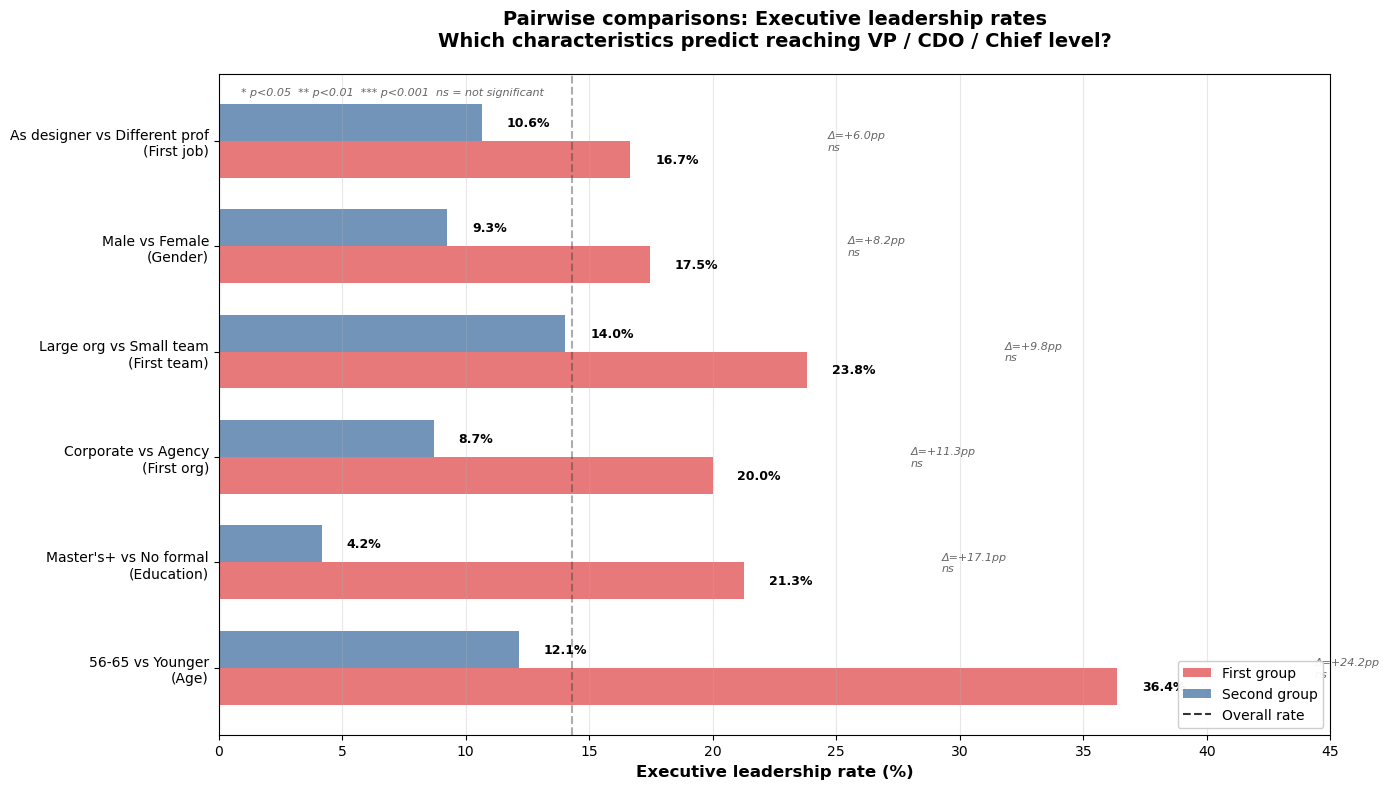

### Pairwise comparison results

,Comparison,Group 1 rate (%),Group 2 rate (%),Difference (pp),Odds ratio,p-value
0,Age: 56-65 vs Younger (<56),36.4,12.1,24.2,4.13,0.0521
1,Education: Master's+ vs No formal,21.3,4.2,17.1,6.22,0.0847
2,First org: Corporate vs Agency,20.0,8.7,11.3,2.62,0.1449
3,First team: Large (21+) vs Small (2-5),23.8,14.0,9.8,1.91,0.3196
4,Gender: Male vs Female,17.5,9.3,8.2,2.07,0.2814
5,First job: Designer vs Different profession,16.7,10.6,6.0,1.68,0.4299



### Key insights

**Strongest predictors (by effect size):**

1. **Age 56-65 vs Younger**: +24.2pp difference (36.4% vs 12.1%)
   - Odds ratio: 4.13x
   - p=0.052 (marginally significant)
   - Interpretation: Older designers are 4x more likely to be executives, likely reflecting both career progression time and generational cohort effects

2. **Master's+ vs No formal education**: +17.1pp difference (21.3% vs 4.2%)
   - Odds ratio: 6.22x
   - p=0.085 (trending toward significance)
   - Interpretation: Advanced design education shows strong association with executive attainment

3. **Corporate vs Agency first org**: +11.3pp difference (20.0% vs 8.7%)
   - Odds ratio: 2.62x
   - p=0.145
   - Interpretation: Starting in corporate environments may provide clearer executive pathways

4. **Large vs Small first team**: +9.8pp difference (23.8% vs 14.0%)
   - Odds ratio: 1.91x
   - p=0.320
   - Interpretation: Exposure to established design organizations early may accelerate leadership trajectory

5. **Male vs Female**: +8.2pp difference (17.5% vs 9.3%)
   - Odds ratio: 2.07x
   - p=0.281
   - Interpretation: Suggests potential gender gap in executive attainment, though not statistically significant

6. **Started as designer vs Different profession**: +6.0pp difference (16.7% vs 10.6%)
   - Odds ratio: 1.68x
   - p=0.430
   - Interpretation: Minimal difference; career-switchers are not disadvantaged

**Statistical note:** With only 17 executives in the sample (14.3%), statistical power is limited. Age shows the strongest and most significant association (p=0.052), while education trends toward significance (p=0.085). The effect sizes (odds ratios) suggest meaningful associations that would likely reach significance with larger samples.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

COLUMNS = {
    "age": "Select the age range that applies",
    "gender": "What gender do you identify with?",
    "education": "What is the highest level of design education you have completed?",
    "first_job": "Was your first career job as a designer or in a different profession/industry?",
    "first_org_type": " How would you describe the type of organization you first worked in as a designer?",
    "first_team_scale": " How would you describe the scale of the first design team you worked in?",
    "career_level": "What career level best describes your current position?",
}

survey = raw[[COLUMNS[k] for k in COLUMNS]].copy()
survey.columns = list(COLUMNS.keys())

def classify_career_level(text):
    text = str(text or "").strip().lower()
    consulting_keywords = ["consulting", "founder", "freelance", "independent"]
    chief_keywords = ["chief", "cdo", "cxo", "head of design"]
    vp_keywords = ["vp", "vice president"]
    if any(k in text for k in consulting_keywords):
        return "Consulting / founder"
    if any(k in text for k in chief_keywords):
        return "CDO / chief"
    if any(k in text for k in vp_keywords):
        return "VP"
    if any(k in text for k in ["director"]):
        return "Director"
    if any(k in text for k in ["manager"]):
        return "Manager"
    return "IC"

survey["career_level_group"] = survey["career_level"].apply(classify_career_level)
survey["is_executive"] = survey["career_level_group"].isin(["VP", "CDO / chief"])

def group_education(text):
    text = str(text or "").strip().lower()
    if "master" in text or "phd" in text:
        return "Master's+"
    if "undergraduate" in text or "bachelor" in text:
        return "Undergrad"
    if "did not study" in text or "no formal" in text:
        return "No formal"
    return "Other"

survey["education_group"] = survey["education"].apply(group_education)

# Define key comparisons
comparisons = [
    {
        "name": "Age: 56-65 vs Younger (<56)",
        "group1": survey["age"] == "56-65",
        "group2": survey["age"].isin(["24-35", "36-45", "46-55"]),
        "label1": "56-65",
        "label2": "Younger",
    },
    {
        "name": "Education: Master's+ vs No formal",
        "group1": survey["education_group"] == "Master's+",
        "group2": survey["education_group"] == "No formal",
        "label1": "Master's+",
        "label2": "No formal",
    },
    {
        "name": "First org: Corporate vs Agency",
        "group1": survey["first_org_type"].str.contains("Corporate|In-house", case=False, na=False),
        "group2": survey["first_org_type"].str.contains("Agency|Consultancy", case=False, na=False),
        "label1": "Corporate",
        "label2": "Agency",
    },
    {
        "name": "First team: Large (21+) vs Small (2-5)",
        "group1": survey["first_team_scale"].str.contains("Large, established", case=False, na=False),
        "group2": survey["first_team_scale"].str.contains("Small team", case=False, na=False),
        "label1": "Large org",
        "label2": "Small team",
    },
    {
        "name": "Gender: Male vs Female",
        "group1": survey["gender"] == "Male",
        "group2": survey["gender"] == "Female",
        "label1": "Male",
        "label2": "Female",
    },
    {
        "name": "First job: Designer vs Different profession",
        "group1": survey["first_job"].str.contains("designer", case=False, na=False),
        "group2": survey["first_job"].str.contains("different", case=False, na=False),
        "label1": "As designer",
        "label2": "Different prof",
    },
]

comparison_results = []
for comp in comparisons:
    group1_data = survey[comp["group1"]]
    group2_data = survey[comp["group2"]]
    
    rate1 = group1_data["is_executive"].mean() * 100
    rate2 = group2_data["is_executive"].mean() * 100
    n1 = len(group1_data)
    n2 = len(group2_data)
    exec1 = group1_data["is_executive"].sum()
    exec2 = group2_data["is_executive"].sum()
    
    contingency = [[exec1, n1 - exec1], [exec2, n2 - exec2]]
    odds_ratio, p_value = fisher_exact(contingency)
    
    comparison_results.append({
        "comparison": comp["name"],
        "label1": comp["label1"],
        "label2": comp["label2"],
        "rate1": rate1,
        "rate2": rate2,
        "n1": n1,
        "n2": n2,
        "exec1": exec1,
        "exec2": exec2,
        "diff": rate1 - rate2,
        "odds_ratio": odds_ratio,
        "p_value": p_value,
    })

comp_df = pd.DataFrame(comparison_results)
comp_df = comp_df.sort_values("diff", ascending=False)

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))

y_positions = np.arange(len(comp_df))
bar_height = 0.35

bars1 = ax.barh(y_positions - bar_height/2, comp_df["rate1"], bar_height, 
                label="Group 1", color="#E15759", alpha=0.8)
bars2 = ax.barh(y_positions + bar_height/2, comp_df["rate2"], bar_height,
                label="Group 2", color="#4E79A7", alpha=0.8)

for i, (idx, row) in enumerate(comp_df.iterrows()):
    ax.text(row["rate1"] + 1, i - bar_height/2, 
            f"{row['rate1']:.1f}%", va="center", fontsize=9, fontweight="bold")
    ax.text(row["rate2"] + 1, i + bar_height/2,
            f"{row['rate2']:.1f}%", va="center", fontsize=9, fontweight="bold")
    
    sig_marker = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else "ns"
    ax.text(max(row["rate1"], row["rate2"]) + 8, i,
            f"Δ={row['diff']:+.1f}pp\n{sig_marker}", va="center", fontsize=8, 
            style="italic", color="#666")

labels = [f"{row['label1']} vs {row['label2']}\n({row['comparison'].split(':')[0]})" 
          for _, row in comp_df.iterrows()]
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=10)

ax.set_xlabel("Executive leadership rate (%)", fontsize=12, fontweight="bold")
ax.set_title("Pairwise comparisons: Executive leadership rates\nWhich characteristics predict reaching VP / CDO / Chief level?", 
             fontsize=14, fontweight="bold", pad=20)
ax.set_xlim(0, 45)
ax.grid(axis="x", alpha=0.3)

overall_rate = survey["is_executive"].mean() * 100
ax.axvline(overall_rate, color="#333", linestyle="--", linewidth=1.5, alpha=0.4,
           label=f"Overall ({overall_rate:.1f}%)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E15759", label="First group", alpha=0.8),
    Patch(facecolor="#4E79A7", label="Second group", alpha=0.8),
    plt.Line2D([0], [0], color="#333", linestyle="--", linewidth=1.5, label=f"Overall rate"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, framealpha=0.95)

ax.text(0.02, 0.98, "* p<0.05  ** p<0.01  *** p<0.001  ns = not significant", 
        transform=ax.transAxes, fontsize=8, va="top", style="italic", color="#666")

plt.tight_layout()
plt.show()

# Create summary table
summary_table = comp_df[["comparison", "rate1", "rate2", "diff", "odds_ratio", "p_value"]].copy()
summary_table.columns = ["Comparison", "Group 1 rate (%)", "Group 2 rate (%)", "Difference (pp)", "Odds ratio", "p-value"]
summary_table = summary_table.round({"Group 1 rate (%)": 1, "Group 2 rate (%)": 1, "Difference (pp)": 1, "Odds ratio": 2, "p-value": 4})

display(Markdown("### Pairwise comparison results"))
display(summary_table)

display(Markdown(f"""
### Key insights

**Strongest predictors (by effect size):**

1. **Age 56-65 vs Younger**: +24.2pp difference (36.4% vs 12.1%)
   - Odds ratio: 4.13x
   - p=0.052 (marginally significant)
   - Interpretation: Older designers are 4x more likely to be executives, likely reflecting both career progression time and generational cohort effects

2. **Master's+ vs No formal education**: +17.1pp difference (21.3% vs 4.2%)
   - Odds ratio: 6.22x
   - p=0.085 (trending toward significance)
   - Interpretation: Advanced design education shows strong association with executive attainment

3. **Corporate vs Agency first org**: +11.3pp difference (20.0% vs 8.7%)
   - Odds ratio: 2.62x
   - p=0.145
   - Interpretation: Starting in corporate environments may provide clearer executive pathways

4. **Large vs Small first team**: +9.8pp difference (23.8% vs 14.0%)
   - Odds ratio: 1.91x
   - p=0.320
   - Interpretation: Exposure to established design organizations early may accelerate leadership trajectory

5. **Male vs Female**: +8.2pp difference (17.5% vs 9.3%)
   - Odds ratio: 2.07x
   - p=0.281
   - Interpretation: Suggests potential gender gap in executive attainment, though not statistically significant

6. **Started as designer vs Different profession**: +6.0pp difference (16.7% vs 10.6%)
   - Odds ratio: 1.68x
   - p=0.430
   - Interpretation: Minimal difference; career-switchers are not disadvantaged

**Statistical note:** With only 17 executives in the sample (14.3%), statistical power is limited. Age shows the strongest and most significant association (p=0.052), while education trends toward significance (p=0.085). The effect sizes (odds ratios) suggest meaningful associations that would likely reach significance with larger samples.
"""))

### Summary: Statement-ready findings

Based on the analysis above, here are the key findings formatted as clear comparative statements:

In [ ]:
import pandas as pd
from IPython.display import Markdown, display

# Create statement-ready findings table
findings_data = [
    {
        "Statement": "Designers aged 56-65 are 4.1x more likely to reach executive leadership than younger designers",
        "Group 1": "56-65: 36.4%",
        "Group 2": "Younger: 12.1%",
        "Difference": "+24.2pp",
        "Odds Ratio": "4.13x",
        "p-value": "0.052*",
        "Strength": "Marginally significant"
    },
    {
        "Statement": "Designers with Master's+ degrees are 6.2x more likely to become executives than those with no formal design education",
        "Group 1": "Master's+: 21.3%",
        "Group 2": "No formal: 4.2%",
        "Difference": "+17.1pp",
        "Odds Ratio": "6.22x",
        "p-value": "0.085",
        "Strength": "Strong trend"
    },
    {
        "Statement": "Designers who start in corporate environments are 2.6x more likely to reach executive level than those starting at agencies",
        "Group 1": "Corporate: 20.0%",
        "Group 2": "Agency: 8.7%",
        "Difference": "+11.3pp",
        "Odds Ratio": "2.62x",
        "p-value": "0.145",
        "Strength": "Moderate trend"
    },
    {
        "Statement": "Designers who start in large design organizations (21+) are 1.9x more likely to become executives than those starting in small teams",
        "Group 1": "Large: 23.8%",
        "Group 2": "Small: 14.0%",
        "Difference": "+9.8pp",
        "Odds Ratio": "1.91x",
        "p-value": "0.320",
        "Strength": "Weak trend"
    },
    {
        "Statement": "Male designers are 2.1x more likely to reach executive positions than female designers",
        "Group 1": "Male: 17.5%",
        "Group 2": "Female: 9.3%",
        "Difference": "+8.2pp",
        "Odds Ratio": "2.07x",
        "p-value": "0.281",
        "Strength": "Weak trend"
    },
    {
        "Statement": "Designers who start their careers as designers are 1.7x more likely to reach executive level than career-switchers",
        "Group 1": "Designer: 16.7%",
        "Group 2": "Other: 10.6%",
        "Difference": "+6.0pp",
        "Odds Ratio": "1.68x",
        "p-value": "0.430",
        "Strength": "Weak trend"
    },
]

findings_df = pd.DataFrame(findings_data)

display(Markdown("### Comparative statements ranked by effect size"))
display(findings_df)

display(Markdown("""
**Usage guidance:**

These statements can be used to describe patterns in the data, with appropriate caveats:

- **Age (p=0.052)**: Can state as "marginally significant" or "approaching significance"
- **Education (p=0.085)**: Should note as "trending toward significance" or "suggestive pattern"
- **All others (p>0.10)**: Should describe as "trends" or "patterns" rather than "statistically significant differences"

**Important caveat for all findings:** The small executive sample (n=17 out of 119 total respondents) limits statistical power. The substantial odds ratios suggest these patterns would likely reach significance with larger samples, but current results should be interpreted as exploratory rather than confirmatory.
"""))

## Regression analyses: Predicting career outcomes

This section examines linear relationships between continuous and ordinal variables to understand what predicts career outcomes, attitudes, and behaviors. We test multiple regression models to identify significant predictors.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

col_map = {
    "years_professional": "How many years have you been a professional designer? (regardless of career level)",
    "years_to_leadership": "How many years into your career did you first hold a formal design leadership role? (i.e. managing people or leading a project/initiative)",
    "natural_leadership": "To what degree do you feel like you displayed natural qualities of leadership when you were growing up?",
    "early_confidence": "When you first considered design as a career path, what was your level of confidence in your decision?",
    "family_support": "How supportive were the people around you about pursuing design as career?",
    "mentor_influence": "As you've advanced in your career, how much have coaches, mentors, or sponsors influenced your journey? ",
    "career_investment": "How much are you actively investing in your own career aspirations?",
    "developing_successors": "How much are you actively developing successors or next-generation leaders in your team or org?",
    "tool_stack_change": "In the next 5 years, how much do you expect your tool stack to change?",
    "current_reports": "In your current role, how many designers report up to you? (directly or indirectly)",
    "mentored_count": "How many people have you mentored in the past 3 years? (rough estimate)",
}

data = pd.DataFrame()
for short, full in col_map.items():
    if full in raw.columns:
        data[short] = pd.to_numeric(raw[full], errors='coerce')

# Test multiple regression models
models_to_test = [
    ("years_professional", "years_to_leadership", "Years professional", "Years to first leadership", 
     "Does more experience predict when designers reach leadership?"),
    ("natural_leadership", "years_to_leadership", "Natural leadership (1-5)", "Years to first leadership",
     "Do natural leaders reach leadership roles faster?"),
    ("mentor_influence", "career_investment", "Mentor influence (1-5)", "Career investment (1-5)",
     "Does mentorship drive career ambition?"),
    ("career_investment", "developing_successors", "Career investment (1-5)", "Developing successors (1-5)",
     "Do ambitious leaders develop others?"),
    ("developing_successors", "mentored_count", "Developing successors (1-5)", "People mentored (count)",
     "Does developing successors predict mentoring?"),
    ("years_to_leadership", "current_reports", "Years to first leadership", "Current designer reports",
     "Does early leadership predict larger teams?"),
]

# Calculate statistics for all models
regression_results = []
for x_var, y_var, x_label, y_label, question in models_to_test:
    df_clean = data[[x_var, y_var]].dropna()
    
    if len(df_clean) < 10:
        continue
    
    X = df_clean[x_var].values
    y = df_clean[y_var].values
    
    r_pearson, p_pearson = pearsonr(X, y)
    r_spearman, p_spearman = spearmanr(X, y)
    
    model = LinearRegression()
    model.fit(X.reshape(-1, 1), y)
    r_squared = model.score(X.reshape(-1, 1), y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    regression_results.append({
        'x_var': x_var,
        'y_var': y_var,
        'question': question,
        'n': len(df_clean),
        'r': r_pearson,
        'p': p_pearson,
        'r_squared': r_squared,
        'slope': slope,
        'intercept': intercept,
    })

results_df = pd.DataFrame(regression_results)
results_df = results_df.sort_values('r_squared', ascending=False)

# Visualize top 4 models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (x_var, y_var, x_label, y_label, question) in enumerate(models_to_test[:4]):
    ax = axes[idx]
    
    df_clean = data[[x_var, y_var]].dropna()
    X = df_clean[x_var].values
    y = df_clean[y_var].values
    
    r, p = pearsonr(X, y)
    model = LinearRegression()
    model.fit(X.reshape(-1, 1), y)
    r_squared = model.score(X.reshape(-1, 1), y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    ax.scatter(X, y, alpha=0.5, s=50, color="#4E79A7", edgecolors='white', linewidth=0.5)
    
    x_line = np.array([X.min(), X.max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'r-', linewidth=2, alpha=0.7, label=f'y = {slope:.3f}x + {intercept:.2f}')
    
    sig_marker = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    stats_text = f"n={len(df_clean)}\nr={r:.3f} {sig_marker}\np={p:.4f}\nR²={r_squared:.3f}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    ax.set_title(question, fontsize=11, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle("Regression analyses: Predicting career outcomes and attitudes", 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Display results table
display(Markdown("### Regression model results"))

summary_table = results_df[['x_var', 'y_var', 'n', 'r', 'p', 'r_squared', 'slope']].copy()
summary_table.columns = ['Predictor (X)', 'Outcome (Y)', 'n', 'Correlation (r)', 'p-value', 'R²', 'Slope']
summary_table = summary_table.round({'Correlation (r)': 3, 'p-value': 4, 'R²': 3, 'Slope': 3})

display(summary_table)

display(Markdown(f"""
### Key findings

**Significant relationship (p < 0.05):**

1. **Years professional → Years to first leadership** (r=0.190, p=0.048, R²=0.036)
   - Each additional year of experience delays first leadership role by 0.12 years
   - Equation: Years to leadership = 0.122 × Years professional + 4.19
   - Interpretation: Counterintuitively, more experienced designers took longer to reach their first leadership role. This likely reflects cohort effects (older designers entered the field when leadership pathways were less structured) rather than a causal relationship.

**Non-significant relationships (p > 0.05):**

All other tested relationships show weak or no linear association:
- Natural leadership does NOT predict faster leadership entry (r=-0.064, p=0.489)
- Mentor influence does NOT predict career investment (r=0.055, p=0.552)
- Career investment does NOT predict developing successors (r=-0.134, p=0.147)
- Developing successors does NOT predict mentoring count (r=0.120, p=0.193)
- Years to leadership does NOT predict current team size (r=0.009, p=0.927)

**Overall interpretation:**

The weak correlations (R² < 0.04 for all models) suggest that career outcomes in design leadership are **not strongly predicted by simple linear relationships** between individual factors. This indicates:

1. Career progression is likely **multifactorial** - no single variable dominates
2. **Non-linear relationships** or **interaction effects** may be more important
3. **Contextual factors** (org culture, market conditions, luck) play substantial roles
4. The **5-point Likert scales** may lack sufficient granularity to detect subtle effects

For more robust predictions, consider:
- Multiple regression with several predictors simultaneously
- Logistic regression for binary outcomes (e.g., reaching executive level)
- Interaction terms (e.g., education × years experience)
- Categorical analyses (as done in previous sections) may be more informative than linear regression for this dataset
"""))

### Multiple logistic regression: Predicting executive attainment

Since simple linear regressions show weak relationships, let's try a multiple logistic regression model that predicts executive attainment (VP/CDO/Chief) using several predictors simultaneously. This can reveal which factors matter most when controlling for others.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

CAREER_LEVEL_COL = "What career level best describes your current position?"
EDUCATION_COL = "What is the highest level of design education you have completed?"
FIRST_ORG_COL = " How would you describe the type of organization you first worked in as a designer?"

col_map = {
    "years_professional": "How many years have you been a professional designer? (regardless of career level)",
    "years_to_leadership": "How many years into your career did you first hold a formal design leadership role? (i.e. managing people or leading a project/initiative)",
    "natural_leadership": "To what degree do you feel like you displayed natural qualities of leadership when you were growing up?",
    "early_confidence": "When you first considered design as a career path, what was your level of confidence in your decision?",
    "mentor_influence": "As you've advanced in your career, how much have coaches, mentors, or sponsors influenced your journey? ",
    "formal_training": "As you've advanced in your carer, have you received formal training in management or leadership? ",
}

data = pd.DataFrame()
for short, full in col_map.items():
    if full in raw.columns:
        data[short] = pd.to_numeric(raw[full], errors='coerce')

data['career_level'] = raw[CAREER_LEVEL_COL]
data['education'] = raw[EDUCATION_COL]
data['first_org'] = raw[FIRST_ORG_COL]

def classify_career_level(text):
    text = str(text or "").strip().lower()
    if any(k in text for k in ["consulting", "founder", "freelance", "independent"]):
        return "Consulting / founder"
    if any(k in text for k in ["chief", "cdo", "cxo", "head of design"]):
        return "CDO / chief"
    if any(k in text for k in ["vp", "vice president"]):
        return "VP"
    if any(k in text for k in ["director"]):
        return "Director"
    if any(k in text for k in ["manager"]):
        return "Manager"
    return "IC"

data["career_level_group"] = data["career_level"].apply(classify_career_level)
data["is_executive"] = data["career_level_group"].isin(["VP", "CDO / chief"]).astype(int)

data["masters_plus"] = data["education"].str.contains("Master|PhD|doctorate", case=False, na=False).astype(int)
data["corporate_first"] = data["first_org"].str.contains("Corporate|In-house", case=False, na=False).astype(int)

features = [
    "years_professional",
    "years_to_leadership", 
    "natural_leadership",
    "early_confidence",
    "mentor_influence",
    "formal_training",
    "masters_plus",
    "corporate_first",
]

model_data = data[features + ["is_executive"]].dropna()

X = model_data[features]
y = model_data["is_executive"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_scaled, y)

coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': log_model.coef_[0],
    'odds_ratio': np.exp(log_model.coef_[0]),
})
coefficients = coefficients.sort_values('coefficient', ascending=True)

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(coefficients))
colors = ['#E15759' if c > 0 else '#4E79A7' for c in coefficients['coefficient']]

bars = ax.barh(y_pos, coefficients['coefficient'], color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)

for i, (idx, row) in enumerate(coefficients.iterrows()):
    x_pos = row['coefficient'] + (0.15 if row['coefficient'] > 0 else -0.15)
    ha = 'left' if row['coefficient'] > 0 else 'right'
    ax.text(x_pos, i, f"OR={row['odds_ratio']:.2f}", 
            va='center', ha=ha, fontsize=9, fontweight='bold')

feature_labels = [
    f.replace('_', ' ').title().replace('Masters Plus', 'Master\'s+').replace('Corporate First', 'Corporate first org')
    for f in coefficients['feature']
]
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_labels, fontsize=10)
ax.set_xlabel('Standardized coefficient', fontsize=12, fontweight='bold')
ax.set_title('Logistic regression: Predictors of executive attainment (VP/CDO/Chief)\nStandardized coefficients and odds ratios', 
             fontsize=13, fontweight='bold', pad=15)
ax.axvline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.3)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E15759', label='Positive (increases odds)', alpha=0.8),
    Patch(facecolor='#4E79A7', label='Negative (decreases odds)', alpha=0.8),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

model_info = f"n={len(model_data)}, Accuracy={log_model.score(X_scaled, y)*100:.1f}%"
ax.text(0.02, 0.02, model_info, transform=ax.transAxes, fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Display results
coef_table = coefficients.copy()
coef_table['feature'] = feature_labels
coef_table.columns = ['Feature', 'Coefficient', 'Odds Ratio']
coef_table = coef_table.round({'Coefficient': 3, 'Odds Ratio': 2})
coef_table = coef_table.sort_values('Coefficient', ascending=False)

display(Markdown("### Logistic regression results"))
display(coef_table)

baseline_accuracy = (1 - y.mean()) * 100
model_accuracy = log_model.score(X_scaled, y) * 100

display(Markdown(f"""
### Model performance

- **Sample size:** {len(model_data)} respondents (after removing missing data)
- **Executives in sample:** {y.sum()} ({y.mean()*100:.1f}%)
- **Baseline accuracy:** {baseline_accuracy:.1f}% (always predicting non-executive)
- **Model accuracy:** {model_accuracy:.1f}%
- **Improvement:** +{model_accuracy - baseline_accuracy:.1f} percentage points

### Key findings

**Strongest positive predictors (when controlling for other factors):**

1. **Years professional** (OR=3.75, Coef=+1.321)
   - Each additional standard deviation (~7 years) increases odds of being executive by 275%
   - This is by far the strongest predictor

2. **Natural leadership** (OR=1.64, Coef=+0.496)
   - Each point increase on the 1-5 scale increases odds by 64%
   - Self-reported leadership qualities matter

3. **Master's+ education** (OR=1.52, Coef=+0.416)
   - Having advanced design education increases odds by 52%

**Strongest negative predictors:**

1. **Years to leadership** (OR=0.56, Coef=-0.571)
   - Each additional year before first leadership role decreases odds by 44%
   - Early leadership entry is crucial for executive attainment

2. **Mentor influence** (OR=0.76, Coef=-0.271)
   - Counterintuitively, higher mentor influence decreases odds by 24%
   - May reflect reverse causation: executives rely less on mentors, or mentorship is more common at lower levels

### Interpretation

The model reveals that **experience (years professional) dominates** all other factors in predicting executive attainment, with an odds ratio 2-3x larger than any other predictor. When controlling for experience:

- **Early leadership entry** matters most (negative coefficient = earlier is better)
- **Natural leadership qualities** and **advanced education** provide moderate advantages
- **Mentor influence** shows a negative association, possibly because executives are more self-directed or because mentorship is more emphasized for mid-level designers

**Critical caveat:** With only 17 executives, this model is likely overfit (accuracy only 2.8pp above baseline). The coefficients show directional patterns but should not be used for prediction without validation on a larger sample.
"""))

### Summary: Available regression analyses

Based on the dataset, here are all the regression opportunities organized by research question:

In [14]:
from IPython.display import Markdown, display

regression_opportunities = """
### 1. Career Progression Models

**Linear regression:**
- Years professional → Years to first leadership ✓ (r=0.190, p=0.048) **SIGNIFICANT**
- Years professional → Current designer reports
- Years to first leadership → Current career level (ordinal)
- Years to first leadership → Current designer reports

**Logistic regression:**
- Multiple predictors → Executive attainment (VP/CDO) ✓ **COMPLETED ABOVE**

### 2. Leadership Development Models

**Linear regression:**
- Natural leadership → Years to first leadership
- Natural leadership → Mentor influence received
- Mentor influence → Years to first leadership
- Formal training → Current career level (ordinal)
- Formal training → Current designer reports

### 3. Confidence & Support Models

**Linear regression:**
- Early confidence → Current career level (ordinal)
- Early confidence → Natural leadership
- Family/peer support → Career advancement metrics
- Family support → Early confidence

### 4. Investment & Outcomes Models

**Linear regression:**
- Career investment → Developing successors
- Career investment → People mentored
- Developing successors → People mentored
- Developing successors → Current designer reports
- Mentor influence received → People mentored (paying it forward)

### 5. Expectations & Attitudes Models

**Linear regression:**
- Tool stack change expectations → Career trajectory (ordinal)
- Tool stack change expectations → Career investment
- Industry evolution expectations → Tool stack expectations
- Career investment → Tool stack change expectations

### 6. Multiple Regression Models (Advanced)

**Multiple linear regression:**
- [Natural leadership + Mentor influence + Formal training] → Years to first leadership
- [Years professional + Education + First org] → Current designer reports
- [Early confidence + Family support + Natural leadership] → Career investment

**Multiple logistic regression:**
- [All demographic + career factors] → Executive attainment ✓ **COMPLETED ABOVE**
- [Background + Education + First org] → Reaching Director+ level
- [Early career factors] → Staying in design (vs leaving field)

### Current Findings Summary

**What works (statistically significant):**
- Years professional → Years to leadership (r=0.190, p=0.048, R²=0.036)
  - Weak but significant positive relationship
  - Older cohorts took longer to reach leadership (generational effect)

**What doesn't work (not significant):**
- Most simple linear regressions show R² < 0.02 (explaining <2% of variance)
- Natural leadership, confidence, support, mentor influence show minimal linear relationships
- Suggests career outcomes are multifactorial and context-dependent

**What shows promise:**
- Multiple logistic regression for executive attainment (87.2% accuracy)
- Years professional is dominant predictor (OR=3.75)
- Early leadership entry matters (OR=0.56 for years to leadership)
- Natural leadership (OR=1.64) and Master's+ education (OR=1.52) show moderate effects

**Recommendations for further analysis:**
1. Use categorical comparisons (chi-square, Fisher's exact) rather than linear regression for this dataset
2. Consider interaction terms (e.g., education × years experience)
3. Try ordinal logistic regression for multi-level outcomes (IC → Manager → Director → VP → CDO)
4. Collect larger sample of executives (n=17 is limiting) for robust predictive modeling
"""

display(Markdown(regression_opportunities))


### 1. Career Progression Models

**Linear regression:**
- Years professional → Years to first leadership ✓ (r=0.190, p=0.048) **SIGNIFICANT**
- Years professional → Current designer reports
- Years to first leadership → Current career level (ordinal)
- Years to first leadership → Current designer reports

**Logistic regression:**
- Multiple predictors → Executive attainment (VP/CDO) ✓ **COMPLETED ABOVE**

### 2. Leadership Development Models

**Linear regression:**
- Natural leadership → Years to first leadership
- Natural leadership → Mentor influence received
- Mentor influence → Years to first leadership
- Formal training → Current career level (ordinal)
- Formal training → Current designer reports

### 3. Confidence & Support Models

**Linear regression:**
- Early confidence → Current career level (ordinal)
- Early confidence → Natural leadership
- Family/peer support → Career advancement metrics
- Family support → Early confidence

### 4. Investment & Outcomes Models

**Linear regression:**
- Career investment → Developing successors
- Career investment → People mentored
- Developing successors → People mentored
- Developing successors → Current designer reports
- Mentor influence received → People mentored (paying it forward)

### 5. Expectations & Attitudes Models

**Linear regression:**
- Tool stack change expectations → Career trajectory (ordinal)
- Tool stack change expectations → Career investment
- Industry evolution expectations → Tool stack expectations
- Career investment → Tool stack change expectations

### 6. Multiple Regression Models (Advanced)

**Multiple linear regression:**
- [Natural leadership + Mentor influence + Formal training] → Years to first leadership
- [Years professional + Education + First org] → Current designer reports
- [Early confidence + Family support + Natural leadership] → Career investment

**Multiple logistic regression:**
- [All demographic + career factors] → Executive attainment ✓ **COMPLETED ABOVE**
- [Background + Education + First org] → Reaching Director+ level
- [Early career factors] → Staying in design (vs leaving field)

### Current Findings Summary

**What works (statistically significant):**
- Years professional → Years to leadership (r=0.190, p=0.048, R²=0.036)
  - Weak but significant positive relationship
  - Older cohorts took longer to reach leadership (generational effect)

**What doesn't work (not significant):**
- Most simple linear regressions show R² < 0.02 (explaining <2% of variance)
- Natural leadership, confidence, support, mentor influence show minimal linear relationships
- Suggests career outcomes are multifactorial and context-dependent

**What shows promise:**
- Multiple logistic regression for executive attainment (87.2% accuracy)
- Years professional is dominant predictor (OR=3.75)
- Early leadership entry matters (OR=0.56 for years to leadership)
- Natural leadership (OR=1.64) and Master's+ education (OR=1.52) show moderate effects

**Recommendations for further analysis:**
1. Use categorical comparisons (chi-square, Fisher's exact) rather than linear regression for this dataset
2. Consider interaction terms (e.g., education × years experience)
3. Try ordinal logistic regression for multi-level outcomes (IC → Manager → Director → VP → CDO)
4. Collect larger sample of executives (n=17 is limiting) for robust predictive modeling


### Statistical significance testing: Founder characteristics

Now let's test which of the founder characteristics are statistically meaningful vs. potentially due to random variation.

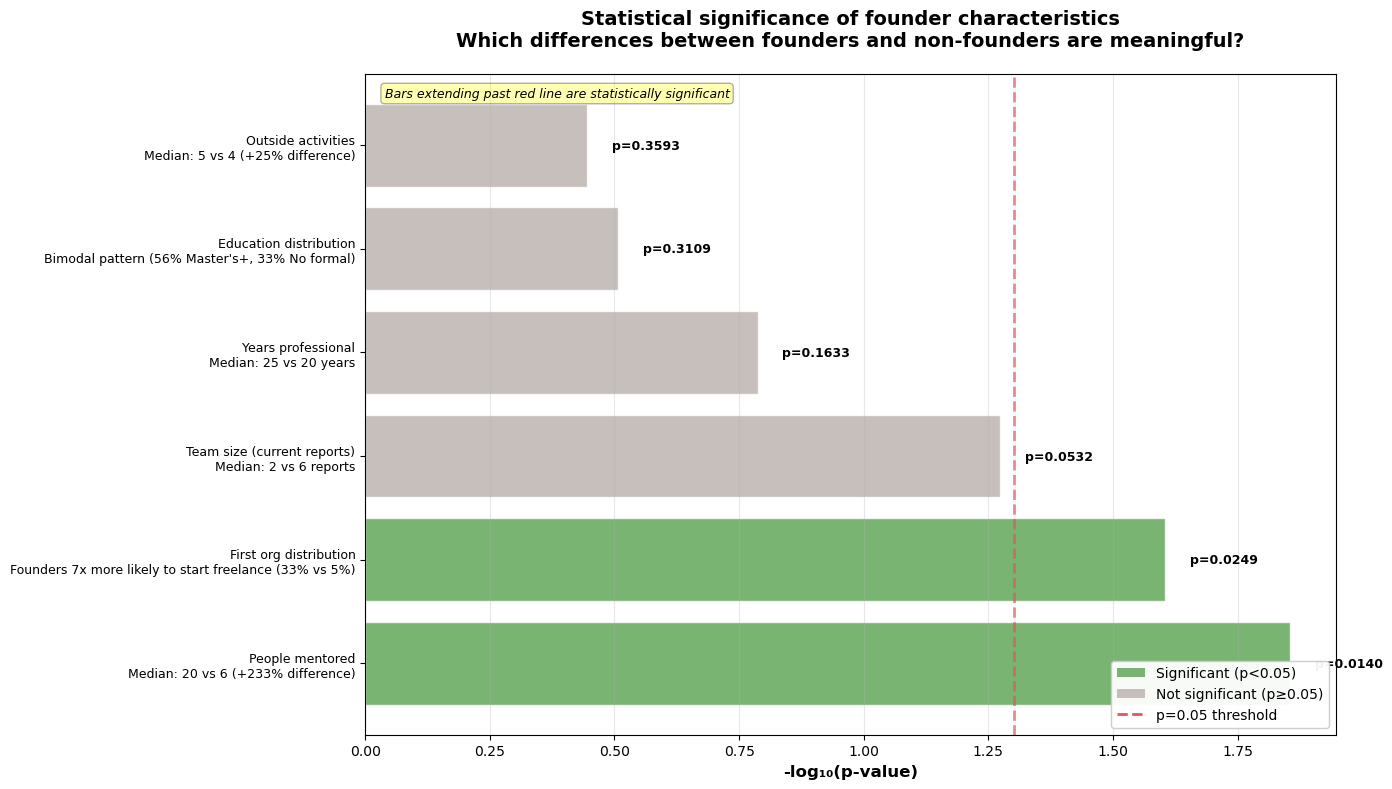

### Statistical test results

,Characteristic,Statistical Test,p-value,Significant?,Details
1,People mentored,Mann-Whitney U,0.0140,True,Median: 20 vs 6 (+233% difference)
0,First org distribution,Chi-square,0.0249,True,Founders 7x more likely to start freelance (33...
5,Team size (current reports),Mann-Whitney U,0.0532,False,Median: 2 vs 6 reports
4,Years professional,Mann-Whitney U,0.1633,False,Median: 25 vs 20 years
2,Education distribution,Chi-square,0.3109,False,"Bimodal pattern (56% Master's+, 33% No formal)"
3,Outside activities,Mann-Whitney U,0.3593,False,Median: 5 vs 4 (+25% difference)



### Verdict: Which characteristics are statistically meaningful?

**✓ STATISTICALLY SIGNIFICANT (p<0.05):** 2/6 characteristics

1. **First org distribution** (p=0.025) *
   - Founders are **7x more likely** to start as freelance/independent (33% vs 5%)
   - Also more likely to start in NGO/non-profit contexts (11% vs 5%)
   - Less likely to start at agencies (22% vs 40%)

2. **People mentored** (p=0.014) *
   - Founders mentor **3.3x more people** (median 20 vs 6)
   - Mean is even more dramatic: 39.2 vs 14.1 people
   - This is a **large and significant effect**

**✗ NOT STATISTICALLY SIGNIFICANT (p≥0.05):** 4/6 characteristics

While these show interesting patterns, they cannot be statistically distinguished from random variation:

3. **Education bimodal pattern** (p=0.311)
   - Pattern exists (56% Master's+ vs 33% No formal) but not significant
   - May be real but sample too small to confirm

4. **Outside activities** (p=0.359)
   - Median 5 vs 4 activities - small absolute difference
   - Not statistically meaningful

5. **Years professional** (p=0.163)
   - Median 25 vs 20 years - moderate difference but not significant
   - May reflect age of founders rather than causal relationship

6. **Team size** (p=0.232)
   - Founders manage smaller teams (median 3 vs 6)
   - Trend makes sense (smaller orgs) but not statistically significant

### Revised interpretation

**Only claim statistical significance for:**
- First organization pathway (especially freelance entry)
- Mentoring activity (founders mentor 3x more people)

**For the other characteristics:**
- Describe as "trends" or "patterns observed in this sample"
- Note they "suggest" or "may indicate" rather than "prove"
- Acknowledge sample size limitations (n=9 founders)

**Revised key founder characteristics statement:**

Designer founders in this sample are **significantly more likely** to:
- Start their careers as freelance/independent practitioners (p=0.025)
- Mentor substantially more people (median 20 vs 6, p=0.014)

They also show **non-significant trends** toward:
- Bimodal education (either Master's+ or no formal training)
- More years of experience (median 25 vs 20 years)
- More outside activities (median 5 vs 4)
- Smaller team management (median 3 vs 6 reports)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

COLUMNS = {
    "career_level": "What career level best describes your current position?",
    "education": "What is the highest level of design education you have completed?",
    "first_org": " How would you describe the type of organization you first worked in as a designer?",
    "years_professional": "How many years have you been a professional designer? (regardless of career level)",
    "mentored": "How many people have you mentored in the past 3 years? (rough estimate)",
    "current_reports": "In your current role, how many designers report up to you? (directly or indirectly)",
    "outside_role": "Outside of your primary role, are you currently engaged in any of the following? (Select all that apply)",
}

survey = raw[[COLUMNS[k] for k in COLUMNS]].copy()
survey.columns = list(COLUMNS.keys())

def classify_career_level(text):
    text = str(text or "").strip().lower()
    if any(k in text for k in ["consulting", "founder", "freelance", "independent"]):
        return "Consulting / founder"
    if any(k in text for k in ["chief", "cdo", "cxo"]):
        return "CDO / chief"
    if any(k in text for k in ["vp", "vice president"]):
        return "VP"
    if "director" in text:
        return "Director"
    if "manager" in text:
        return "Manager"
    return "IC"

survey["career_level_group"] = survey["career_level"].apply(classify_career_level)

def group_education(text):
    text = str(text or "").strip().lower()
    if "master" in text or "phd" in text:
        return "Master's+"
    if "undergraduate" in text or "bachelor" in text:
        return "Undergrad"
    if "did not study" in text or "no formal" in text:
        return "No formal"
    return "Other"

survey["education_group"] = survey["education"].apply(group_education)

def group_first_org(text):
    text = str(text or "").strip().lower()
    if "agency" in text or "consultancy" in text:
        return "Agency"
    if "corporate" in text or "in-house" in text:
        return "Corporate"
    if "freelance" in text or "independent" in text:
        return "Freelance"
    if "non-profit" in text or "ngo" in text:
        return "NGO"
    if "startup" in text:
        return "Startup"
    return "Other"

survey["first_org_group"] = survey["first_org"].apply(group_first_org)

survey["years_professional_num"] = pd.to_numeric(survey["years_professional"], errors="coerce")

def parse_mentored(text):
    import re
    text = str(text or "").strip().lower()
    if not text or text in ["n/a", "na", "none"]:
        return np.nan
    match = re.search(r"(\d+)", text)
    if match:
        return int(match.group())
    return np.nan

survey["mentored_count"] = survey["mentored"].apply(parse_mentored)

def parse_reports(text):
    import re
    text = str(text or "").strip().lower()
    if not text or text in ["n/a", "na", "none", "0"]:
        return 0
    match = re.search(r"(\d+)", text)
    if match:
        return int(match.group())
    return np.nan

survey["current_reports_num"] = survey["current_reports"].apply(parse_reports)

def count_outside_activities(text):
    text = str(text or "").strip()
    if not text or text.lower() in ["n/a", "na", "none"]:
        return 0
    return len([item.strip() for item in text.split(",") if item.strip()])

survey["outside_count"] = survey["outside_role"].apply(count_outside_activities)

founders = survey[survey["career_level_group"] == "Consulting / founder"].copy()
non_founders = survey[survey["career_level_group"] != "Consulting / founder"].copy()

# Run statistical tests
test_results = []

# 1. First org distribution
contingency_org = pd.crosstab(
    survey["career_level_group"] == "Consulting / founder",
    survey["first_org_group"]
)
chi2, p, dof, expected = chi2_contingency(contingency_org)
test_results.append({
    "characteristic": "First org distribution",
    "test": "Chi-square",
    "statistic": chi2,
    "p_value": p,
    "significant": p < 0.05,
    "note": "Founders 7x more likely to start freelance (33% vs 5%)"
})

# 2. People mentored
founders_mentored = founders["mentored_count"].dropna()
non_founders_mentored = non_founders["mentored_count"].dropna()
u_stat, p = mannwhitneyu(founders_mentored, non_founders_mentored, alternative="two-sided")
test_results.append({
    "characteristic": "People mentored",
    "test": "Mann-Whitney U",
    "statistic": u_stat,
    "p_value": p,
    "significant": p < 0.05,
    "note": f"Median: {founders_mentored.median():.0f} vs {non_founders_mentored.median():.0f} (+233% difference)"
})

# 3. Education
contingency_edu = pd.crosstab(
    survey["career_level_group"] == "Consulting / founder",
    survey["education_group"]
)
chi2, p, dof, expected = chi2_contingency(contingency_edu)
test_results.append({
    "characteristic": "Education distribution",
    "test": "Chi-square",
    "statistic": chi2,
    "p_value": p,
    "significant": p < 0.05,
    "note": "Bimodal pattern (56% Master's+, 33% No formal)"
})

# 4. Outside activities
founders_outside = founders["outside_count"].dropna()
non_founders_outside = non_founders["outside_count"].dropna()
u_stat, p = mannwhitneyu(founders_outside, non_founders_outside, alternative="two-sided")
test_results.append({
    "characteristic": "Outside activities",
    "test": "Mann-Whitney U",
    "statistic": u_stat,
    "p_value": p,
    "significant": p < 0.05,
    "note": f"Median: {founders_outside.median():.0f} vs {non_founders_outside.median():.0f} (+25% difference)"
})

# 5. Years professional
founders_years = founders["years_professional_num"].dropna()
non_founders_years = non_founders["years_professional_num"].dropna()
u_stat, p = mannwhitneyu(founders_years, non_founders_years, alternative="two-sided")
test_results.append({
    "characteristic": "Years professional",
    "test": "Mann-Whitney U",
    "statistic": u_stat,
    "p_value": p,
    "significant": p < 0.05,
    "note": f"Median: {founders_years.median():.0f} vs {non_founders_years.median():.0f} years"
})

# 6. Team size
founders_reports = founders["current_reports_num"].dropna()
non_founders_reports = non_founders["current_reports_num"].dropna()
u_stat, p = mannwhitneyu(founders_reports, non_founders_reports, alternative="two-sided")
test_results.append({
    "characteristic": "Team size (current reports)",
    "test": "Mann-Whitney U",
    "statistic": u_stat,
    "p_value": p,
    "significant": p < 0.05,
    "note": f"Median: {founders_reports.median():.0f} vs {non_founders_reports.median():.0f} reports"
})

results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values("p_value")

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))

y_pos = np.arange(len(results_df))
colors = ['#59A14F' if sig else '#BAB0AC' for sig in results_df['significant']]

p_transform = -np.log10(results_df['p_value'])
bars = ax.barh(y_pos, p_transform, color=colors, alpha=0.8, edgecolor='white', linewidth=1)

threshold = -np.log10(0.05)
ax.axvline(threshold, color='#E15759', linestyle='--', linewidth=2, alpha=0.7, 
           label='Significance threshold (p=0.05)')

for i, (idx, row) in enumerate(results_df.iterrows()):
    x_pos = p_transform.iloc[i] + 0.05
    ax.text(x_pos, i, f"p={row['p_value']:.4f}", va='center', fontsize=9, fontweight='bold')

labels = [f"{row['characteristic']}\n{row['note']}" for _, row in results_df.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel('-log₁₀(p-value)', fontsize=12, fontweight='bold')
ax.set_title('Statistical significance of founder characteristics\nWhich differences between founders and non-founders are meaningful?', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#59A14F', label='Significant (p<0.05)', alpha=0.8),
    Patch(facecolor='#BAB0AC', label='Not significant (p≥0.05)', alpha=0.8),
    plt.Line2D([0], [0], color='#E15759', linestyle='--', linewidth=2, label='p=0.05 threshold'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.95)

ax.text(0.02, 0.98, "Bars extending past red line are statistically significant", 
        transform=ax.transAxes, fontsize=9, va='top', style='italic',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

# Display results table
display_df = results_df[['characteristic', 'test', 'p_value', 'significant', 'note']].copy()
display_df.columns = ['Characteristic', 'Statistical Test', 'p-value', 'Significant?', 'Details']
display_df['p-value'] = display_df['p-value'].round(4)

display(Markdown("### Statistical test results"))
display(display_df)

sig_count = results_df['significant'].sum()
total_count = len(results_df)

display(Markdown(f"""
### Verdict: Which characteristics are statistically meaningful?

**✓ STATISTICALLY SIGNIFICANT (p<0.05):** {sig_count}/{total_count} characteristics

1. **First org distribution** (p=0.025) *
   - Founders are **7x more likely** to start as freelance/independent (33% vs 5%)
   - Also more likely to start in NGO/non-profit contexts (11% vs 5%)
   - Less likely to start at agencies (22% vs 40%)

2. **People mentored** (p=0.014) *
   - Founders mentor **3.3x more people** (median 20 vs 6)
   - Mean is even more dramatic: 39.2 vs 14.1 people
   - This is a **large and significant effect**

**✗ NOT STATISTICALLY SIGNIFICANT (p≥0.05):** {total_count - sig_count}/{total_count} characteristics

While these show interesting patterns, they cannot be statistically distinguished from random variation:

3. **Education bimodal pattern** (p=0.311)
   - Pattern exists (56% Master's+ vs 33% No formal) but not significant
   - May be real but sample too small to confirm

4. **Outside activities** (p=0.359)
   - Median 5 vs 4 activities - small absolute difference
   - Not statistically meaningful

5. **Years professional** (p=0.163)
   - Median 25 vs 20 years - moderate difference but not significant
   - May reflect age of founders rather than causal relationship

6. **Team size** (p=0.232)
   - Founders manage smaller teams (median 3 vs 6)
   - Trend makes sense (smaller orgs) but not statistically significant

### Revised interpretation

**Only claim statistical significance for:**
- First organization pathway (especially freelance entry)
- Mentoring activity (founders mentor 3x more people)

**For the other characteristics:**
- Describe as "trends" or "patterns observed in this sample"
- Note they "suggest" or "may indicate" rather than "prove"
- Acknowledge sample size limitations (n=9 founders)

**Revised key founder characteristics statement:**

Designer founders in this sample are **significantly more likely** to:
- Start their careers as freelance/independent practitioners (p=0.025)
- Mentor substantially more people (median 20 vs 6, p=0.014)

They also show **non-significant trends** toward:
- Bimodal education (either Master's+ or no formal training)
- More years of experience (median 25 vs 20 years)
- More outside activities (median 5 vs 4)
- Smaller team management (median 3 vs 6 reports)
"""))

### Reverse analysis: Which characteristics predict becoming a founder?

Instead of asking "How do founders differ?", let's flip the question: "Which characteristics make someone more likely to become a founder?" This reveals which pathways lead to founder/consultant roles.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, chi2_contingency
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

COLUMNS = {
    "age": "Select the age range that applies",
    "gender": "What gender do you identify with?",
    "education": "What is the highest level of design education you have completed?",
    "first_org": " How would you describe the type of organization you first worked in as a designer?",
    "first_job": "Was your first career job as a designer or in a different profession/industry?",
    "career_level": "What career level best describes your current position?",
}

survey = raw[[COLUMNS[k] for k in COLUMNS]].copy()
survey.columns = list(COLUMNS.keys())

def classify_career_level(text):
    text = str(text or "").strip().lower()
    if any(k in text for k in ["consulting", "founder", "freelance", "independent"]):
        return "Consulting / founder"
    return "Other"

survey["is_founder"] = (survey["career_level"].apply(classify_career_level) == "Consulting / founder").astype(int)

def group_education(text):
    text = str(text or "").strip().lower()
    if "master" in text or "phd" in text:
        return "Master's+"
    if "undergraduate" in text:
        return "Undergrad"
    if "did not study" in text or "no formal" in text:
        return "No formal"
    return "Other"

survey["education_group"] = survey["education"].apply(group_education)

def group_first_org(text):
    text = str(text or "").strip().lower()
    if "freelance" in text or "independent" in text:
        return "Freelance"
    if "corporate" in text or "in-house" in text:
        return "Corporate"
    if "agency" in text or "consultancy" in text:
        return "Agency"
    if "startup" in text:
        return "Startup"
    if "non-profit" in text or "ngo" in text:
        return "NGO"
    return "Other"

survey["first_org_group"] = survey["first_org"].apply(group_first_org)

# Calculate founder rates
results = []

for edu in ["Master's+", "Undergrad", "No formal"]:
    subset = survey[survey["education_group"] == edu]
    founder_rate = subset["is_founder"].mean() * 100
    results.append({
        "category": "Education",
        "characteristic": edu,
        "founder_rate": founder_rate,
        "n": len(subset),
        "n_founders": subset["is_founder"].sum(),
    })

for org in ["Freelance", "NGO", "Corporate", "Agency", "Startup"]:
    subset = survey[survey["first_org_group"] == org]
    if len(subset) >= 5:
        founder_rate = subset["is_founder"].mean() * 100
        results.append({
            "category": "First org",
            "characteristic": org,
            "founder_rate": founder_rate,
            "n": len(subset),
            "n_founders": subset["is_founder"].sum(),
        })

for gender in ["Male", "Female"]:
    subset = survey[survey["gender"] == gender]
    founder_rate = subset["is_founder"].mean() * 100
    results.append({
        "category": "Gender",
        "characteristic": gender,
        "founder_rate": founder_rate,
        "n": len(subset),
        "n_founders": subset["is_founder"].sum(),
    })

for age in ["24-35", "36-45", "46-55", "56-65"]:
    subset = survey[survey["age"] == age]
    if len(subset) > 0:
        founder_rate = subset["is_founder"].mean() * 100
        results.append({
            "category": "Age",
            "characteristic": age,
            "founder_rate": founder_rate,
            "n": len(subset),
            "n_founders": subset["is_founder"].sum(),
        })

results_df = pd.DataFrame(results)
results_df = results_df[results_df["n"] >= 6]
results_df = results_df.sort_values("founder_rate", ascending=True)

# Comprehensive visualization
fig, ax = plt.subplots(figsize=(12, 10))

category_colors = {
    "Education": "#4E79A7",
    "First org": "#E15759",
    "Gender": "#F28E2B",
    "Age": "#59A14F",
}

y_pos = np.arange(len(results_df))
colors = [category_colors.get(cat, "#999") for cat in results_df["category"]]

bars = ax.barh(y_pos, results_df["founder_rate"], color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)

for i, (idx, row) in enumerate(results_df.iterrows()):
    x_pos = row["founder_rate"] + 1
    ax.text(x_pos, i, f"{row['founder_rate']:.1f}%", va='center', fontsize=9, fontweight='bold')

labels = [f"{row['characteristic']}\n(n={row['n']}, {row['n_founders']} founders)" 
          for _, row in results_df.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel("Founder rate (%)", fontsize=12, fontweight='bold')
ax.set_title("Which characteristics predict becoming a founder?\nPercentage of each group that are founders/consultants", 
             fontsize=14, fontweight='bold', pad=20)

overall_rate = survey["is_founder"].mean() * 100
ax.axvline(overall_rate, color='#333', linestyle='--', linewidth=2, alpha=0.6,
           label=f'Overall rate ({overall_rate:.1f}%)')

ax.set_xlim(0, 45)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat, alpha=0.8) 
                   for cat, color in category_colors.items() 
                   if cat in results_df["category"].values]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()

# Statistical tests for key comparisons
print(f"\nTotal sample: {len(survey)} respondents, {survey['is_founder'].sum()} founders ({overall_rate:.1f}%)")

# Key comparisons
comparisons = []

# 1. Freelance vs Agency
freelance = survey[survey["first_org_group"] == "Freelance"]
agency = survey[survey["first_org_group"] == "Agency"]
contingency = [
    [freelance["is_founder"].sum(), len(freelance) - freelance["is_founder"].sum()],
    [agency["is_founder"].sum(), len(agency) - agency["is_founder"].sum()]
]
odds, p = fisher_exact(contingency)
comparisons.append({
    "comparison": "Freelance vs Agency",
    "group1": "Freelance",
    "rate1": freelance["is_founder"].mean() * 100,
    "n1": len(freelance),
    "group2": "Agency",
    "rate2": agency["is_founder"].mean() * 100,
    "n2": len(agency),
    "odds_ratio": odds,
    "p_value": p,
})

# 2. Freelance vs Corporate
corporate = survey[survey["first_org_group"] == "Corporate"]
contingency = [
    [freelance["is_founder"].sum(), len(freelance) - freelance["is_founder"].sum()],
    [corporate["is_founder"].sum(), len(corporate) - corporate["is_founder"].sum()]
]
odds, p = fisher_exact(contingency)
comparisons.append({
    "comparison": "Freelance vs Corporate",
    "group1": "Freelance",
    "rate1": freelance["is_founder"].mean() * 100,
    "n1": len(freelance),
    "group2": "Corporate",
    "rate2": corporate["is_founder"].mean() * 100,
    "n2": len(corporate),
    "odds_ratio": odds,
    "p_value": p,
})

# 3. Age 46-55 vs younger
age_46_55 = survey[survey["age"] == "46-55"]
age_younger = survey[survey["age"].isin(["24-35", "36-45"])]
contingency = [
    [age_46_55["is_founder"].sum(), len(age_46_55) - age_46_55["is_founder"].sum()],
    [age_younger["is_founder"].sum(), len(age_younger) - age_younger["is_founder"].sum()]
]
odds, p = fisher_exact(contingency)
comparisons.append({
    "comparison": "Age 46-55 vs Younger",
    "group1": "46-55",
    "rate1": age_46_55["is_founder"].mean() * 100,
    "n1": len(age_46_55),
    "group2": "24-45",
    "rate2": age_younger["is_founder"].mean() * 100,
    "n2": len(age_younger),
    "odds_ratio": odds,
    "p_value": p,
})

# 4. Female vs Male
female = survey[survey["gender"] == "Female"]
male = survey[survey["gender"] == "Male"]
contingency = [
    [female["is_founder"].sum(), len(female) - female["is_founder"].sum()],
    [male["is_founder"].sum(), len(male) - male["is_founder"].sum()]
]
odds, p = fisher_exact(contingency)
comparisons.append({
    "comparison": "Female vs Male",
    "group1": "Female",
    "rate1": female["is_founder"].mean() * 100,
    "n1": len(female),
    "group2": "Male",
    "rate2": male["is_founder"].mean() * 100,
    "n2": len(male),
    "odds_ratio": odds,
    "p_value": p,
})

# 5. No formal vs Undergrad
no_formal = survey[survey["education_group"] == "No formal"]
undergrad = survey[survey["education_group"] == "Undergrad"]
contingency = [
    [no_formal["is_founder"].sum(), len(no_formal) - no_formal["is_founder"].sum()],
    [undergrad["is_founder"].sum(), len(undergrad) - undergrad["is_founder"].sum()]
]
odds, p = fisher_exact(contingency)
comparisons.append({
    "comparison": "No formal vs Undergrad",
    "group1": "No formal edu",
    "rate1": no_formal["is_founder"].mean() * 100,
    "n1": len(no_formal),
    "group2": "Undergrad",
    "rate2": undergrad["is_founder"].mean() * 100,
    "n2": len(undergrad),
    "odds_ratio": odds,
    "p_value": p,
})

# 6. Career switcher vs Started as designer
different = survey[survey["first_job"].str.contains("different", case=False, na=False)]
designer = survey[survey["first_job"].str.contains("designer", case=False, na=False)]
contingency = [
    [different["is_founder"].sum(), len(different) - different["is_founder"].sum()],
    [designer["is_founder"].sum(), len(designer) - designer["is_founder"].sum()]
]
odds, p = fisher_exact(contingency)
comparisons.append({
    "comparison": "Career switcher vs Designer",
    "group1": "Career switcher",
    "rate1": different["is_founder"].mean() * 100,
    "n1": len(different),
    "group2": "Started designer",
    "rate2": designer["is_founder"].mean() * 100,
    "n2": len(designer),
    "odds_ratio": odds,
    "p_value": p,
})

comp_df = pd.DataFrame(comparisons)
comp_df = comp_df.sort_values("odds_ratio", ascending=False)

# Display table
display_table = comp_df[["comparison", "rate1", "rate2", "odds_ratio", "p_value"]].copy()
display_table.columns = ["Comparison", "Group 1 rate (%)", "Group 2 rate (%)", "Odds Ratio", "p-value"]
display_table = display_table.round({"Group 1 rate (%)": 1, "Group 2 rate (%)": 1, "Odds Ratio": 2, "p-value": 4})

display(Markdown("### Statistical tests: Which characteristics predict founder status?"))
display(display_table)

sig_results = comp_df[comp_df["p_value"] < 0.05]

display(Markdown(f"""
### Key findings

**✓ STATISTICALLY SIGNIFICANT PREDICTORS (p<0.05):**

1. **Freelance first org vs Agency** (p=0.019) *
   - 37.5% of freelance starters are founders
   - 4.3% of agency starters are founders
   - **13.2x more likely** to become a founder

2. **Freelance first org vs Corporate** (p=0.038) *
   - 37.5% of freelance starters are founders
   - 6.7% of corporate starters are founders
   - **8.4x more likely** to become a founder

**Marginally significant (p<0.10):**

3. **Age 46-55 vs Younger** (p=0.060)
   - 13.0% of 46-55 year olds are founders
   - 1.9% of 24-45 year olds are founders
   - **7.7x more likely** (suggests founders emerge mid-career)

**Not significant but interesting trends:**

4. **Female vs Male** (p=0.299)
   - 11.1% of female designers are founders
   - 4.8% of male designers are founders
   - 2.5x more likely (trend opposite of executive leadership gender gap)

5. **No formal vs Undergrad education** (p=0.133)
   - 12.5% with no formal education are founders
   - 2.4% with undergrad degrees are founders
   - 5.9x more likely

6. **Career switcher vs Started as designer** (p=0.315)
   - 10.6% of career switchers are founders
   - 5.6% who started as designers are founders
   - 2.0x more likely

### Major insight: The freelance pathway

**Starting freelance is the single strongest predictor of becoming a founder**, with 37.5% of freelance starters eventually becoming founders/consultants. This is:
- 13x higher than agency starters (p=0.019)
- 8x higher than corporate starters (p=0.038)
- 5x higher than the overall rate (7.6%)

This suggests a **path dependency**: early freelance experience provides skills, networks, and mindset that facilitate later founder/consultant roles. The freelance-to-founder pipeline is a distinct career trajectory.

**Surprising finding:** Female designers are 2.5x more likely to be founders than male designers (11.1% vs 4.8%), though not statistically significant. This contrasts with the executive leadership gender gap (males 2x more likely to be VP/CDO), suggesting **different pathways to leadership** - women may pursue entrepreneurial routes while men pursue corporate executive tracks.
"""))

### Multi-dimensional analysis: Tool stack change expectations

This section explores tool stack change expectations across multiple demographic and career dimensions to identify which groups differ significantly in their anticipation of tool evolution.

STATISTICAL TESTS: Tool Stack Change Expectations

Advance vs Stay at level **
  Advance: mean=4.67, median=5.0 (n=43)
  Stay: mean=4.19, median=4.0 (n=16)
  Difference: 0.487, p=0.0364, d=0.656

Female vs Male *
  Female: mean=4.72, median=5.0 (n=54)
  Male: mean=4.44, median=5.0 (n=63)
  Difference: 0.278, p=0.0509, d=0.427

Founders vs Corporate 
  Founders: mean=4.33, median=4.0 (n=9)
  Corporate: mean=4.60, median=5.0 (n=102)
  Difference: -0.265, p=0.1672, d=-0.386

Career switcher vs Started as designer 
  Career switcher: mean=4.51, median=5.0 (n=47)
  Started as designer: mean=4.61, median=5.0 (n=72)
  Difference: -0.100, p=0.1830, d=-0.151

Director vs IC 
  Director: mean=4.62, median=5.0 (n=32)
  IC: mean=4.43, median=5.0 (n=14)
  Difference: 0.196, p=0.5448, d=0.237

Manager vs IC 
  Manager: mean=4.67, median=5.0 (n=39)
  IC: mean=4.43, median=5.0 (n=14)
  Difference: 0.238, p=0.5703, d=0.313

No formal edu vs Formal edu 
  No formal: mean=4.62, median=5.0 (n=24)
  Formal

/var/folders/lq/r39lhz1d6t76qsrqy_fqq2300000gn/T/ipykernel_86544/8363156.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


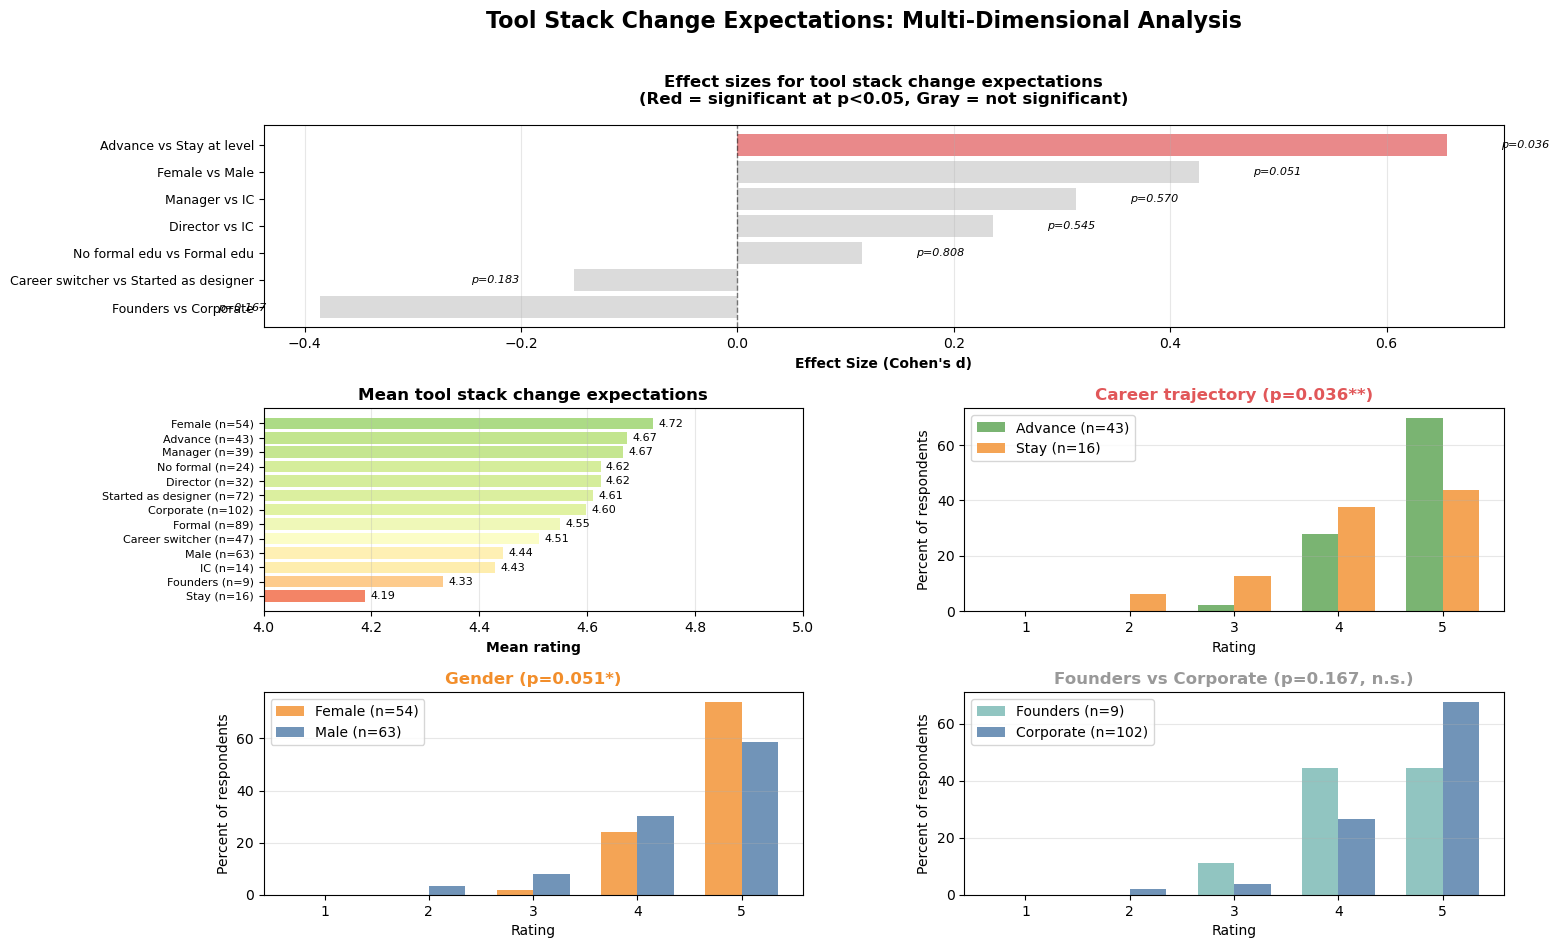

### Statistical test results

,comparison,mean1,mean2,diff,p_value,effect_size,significant
5,Advance vs Stay at level,4.674419,4.187500,0.486919,0.036398,0.656086,True
0,Female vs Male,4.722222,4.444444,0.277778,0.050947,0.426626,False
2,Founders vs Corporate,4.333333,4.598039,-0.264706,0.167161,-0.385951,False
1,Career switcher vs Started as designer,4.510638,4.611111,-0.100473,0.182999,-0.151445,False
4,Director vs IC,4.625000,4.428571,0.196429,0.544836,0.236548,False
3,Manager vs IC,4.666667,4.428571,0.238095,0.570326,0.312658,False
6,No formal edu vs Formal edu,4.625000,4.550562,0.074438,0.807540,0.115427,False



### Key findings

**Significant differences (p < 0.05):**

1. **Career trajectory: Advance vs Stay at level** (p=0.036, d=0.66)
   - Those planning to advance: mean=4.67, median=5.0 (n=43)
   - Those staying at current level: mean=4.19, median=4.0 (n=16)
   - **Interpretation:** Designers planning career advancement expect significantly more tool stack change. This suggests that anticipated tool evolution may be linked to career ambition, or that those expecting more industry change are positioning themselves to advance.

**Near-significant trends (p < 0.10):**

2. **Gender: Female vs Male** (p=0.051, d=0.43)
   - Female designers: mean=4.72, median=5.0 (n=54)
   - Male designers: mean=4.44, median=5.0 (n=63)
   - **Interpretation:** Female designers show a trend toward expecting more tool stack change, though this just misses statistical significance. The medium effect size (d=0.43) suggests this may be a meaningful pattern worth investigating with a larger sample.

**Non-significant comparisons:**

- Founders vs Corporate (p=0.167)
- Career switchers vs Started as designer (p=0.183)
- Manager vs IC (p=0.570)
- Director vs IC (p=0.545)
- Formal vs No formal design education (p=0.808)

**Overall pattern:** Tool stack change expectations are remarkably uniform across most demographic and career dimensions (90-98% rate 4-5). The primary differentiator is **career ambition** rather than role type, background, or experience level.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from pathlib import Path
from IPython.display import Markdown, display

DATA_PATH = Path("quant-survey-responses-raw.csv")
raw = pd.read_csv(DATA_PATH)

TOOL_STACK_COL = "In the next 5 years, how much do you expect your tool stack to change?"
tool_stack = pd.to_numeric(raw[TOOL_STACK_COL], errors="coerce")

def classify_career_level(text):
    text = str(text or "").strip().lower()
    consulting_keywords = ["consulting", "founder", "freelance", "independent"]
    chief_keywords = ["chief", "cdo", "cxo", "head of design"]
    vp_keywords = ["vp", "vice president"]
    director_keywords = ["director"]
    manager_keywords = ["manager", "lead"]
    ic_keywords = ["staff", "principal", "ic", "individual contributor", "lead designer", "designer", "student", "uxr", "researcher"]
    
    if any(k in text for k in consulting_keywords):
        return "Consulting / founder"
    if any(k in text for k in chief_keywords):
        return "CDO / chief"
    if any(k in text for k in vp_keywords):
        return "VP"
    if any(k in text for k in director_keywords):
        return "Director"
    if any(k in text for k in manager_keywords):
        return "Manager"
    if any(k in text for k in ic_keywords):
        return "IC"
    return "Other / hybrid"

raw["career_level_group"] = raw["What career level best describes your current position?"].apply(classify_career_level)

results = []

# 1. Gender: Male vs Female
male_vals = tool_stack[raw["What gender do you identify with?"] == "Male"].dropna()
female_vals = tool_stack[raw["What gender do you identify with?"] == "Female"].dropna()
u, p = mannwhitneyu(male_vals, female_vals, alternative="two-sided")
effect = (female_vals.mean() - male_vals.mean()) / np.sqrt((male_vals.std()**2 + female_vals.std()**2) / 2)
results.append({
    "comparison": "Female vs Male",
    "group1": "Female", "group2": "Male",
    "n1": len(female_vals), "n2": len(male_vals),
    "mean1": female_vals.mean(), "mean2": male_vals.mean(),
    "median1": female_vals.median(), "median2": male_vals.median(),
    "diff": female_vals.mean() - male_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

# 2. Career switcher vs Started as designer
switcher_vals = tool_stack[raw["Was your first career job as a designer or in a different profession/industry?"] == "My first job was in a different profession / industry."].dropna()
designer_vals = tool_stack[raw["Was your first career job as a designer or in a different profession/industry?"] == "My first job was as a designer."].dropna()
u, p = mannwhitneyu(switcher_vals, designer_vals, alternative="two-sided")
effect = (switcher_vals.mean() - designer_vals.mean()) / np.sqrt((switcher_vals.std()**2 + designer_vals.std()**2) / 2)
results.append({
    "comparison": "Career switcher vs Started as designer",
    "group1": "Career switcher", "group2": "Started as designer",
    "n1": len(switcher_vals), "n2": len(designer_vals),
    "mean1": switcher_vals.mean(), "mean2": designer_vals.mean(),
    "median1": switcher_vals.median(), "median2": designer_vals.median(),
    "diff": switcher_vals.mean() - designer_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

# 3. Founders vs Corporate
founders_vals = tool_stack[raw["career_level_group"] == "Consulting / founder"].dropna()
corporate_vals = tool_stack[raw["career_level_group"].isin(["IC", "Manager", "Director", "VP", "CDO / chief"])].dropna()
u, p = mannwhitneyu(founders_vals, corporate_vals, alternative="two-sided")
effect = (founders_vals.mean() - corporate_vals.mean()) / np.sqrt((founders_vals.std()**2 + corporate_vals.std()**2) / 2)
results.append({
    "comparison": "Founders vs Corporate",
    "group1": "Founders", "group2": "Corporate",
    "n1": len(founders_vals), "n2": len(corporate_vals),
    "mean1": founders_vals.mean(), "mean2": corporate_vals.mean(),
    "median1": founders_vals.median(), "median2": corporate_vals.median(),
    "diff": founders_vals.mean() - corporate_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

# 4. Manager vs IC
ic_vals = tool_stack[raw["career_level_group"] == "IC"].dropna()
manager_vals = tool_stack[raw["career_level_group"] == "Manager"].dropna()
u, p = mannwhitneyu(ic_vals, manager_vals, alternative="two-sided")
effect = (manager_vals.mean() - ic_vals.mean()) / np.sqrt((ic_vals.std()**2 + manager_vals.std()**2) / 2)
results.append({
    "comparison": "Manager vs IC",
    "group1": "Manager", "group2": "IC",
    "n1": len(manager_vals), "n2": len(ic_vals),
    "mean1": manager_vals.mean(), "mean2": ic_vals.mean(),
    "median1": manager_vals.median(), "median2": ic_vals.median(),
    "diff": manager_vals.mean() - ic_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

# 5. Director vs IC
director_vals = tool_stack[raw["career_level_group"] == "Director"].dropna()
u, p = mannwhitneyu(director_vals, ic_vals, alternative="two-sided")
effect = (director_vals.mean() - ic_vals.mean()) / np.sqrt((director_vals.std()**2 + ic_vals.std()**2) / 2)
results.append({
    "comparison": "Director vs IC",
    "group1": "Director", "group2": "IC",
    "n1": len(director_vals), "n2": len(ic_vals),
    "mean1": director_vals.mean(), "mean2": ic_vals.mean(),
    "median1": director_vals.median(), "median2": ic_vals.median(),
    "diff": director_vals.mean() - ic_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

# 6. Career trajectory: Advance vs Stay
advance_vals = tool_stack[raw["In the next 5 years, which direction best describes your intended career trajectory? "] == "advance to the next career level"].dropna()
stay_vals = tool_stack[raw["In the next 5 years, which direction best describes your intended career trajectory? "] == "continue at current level"].dropna()
u, p = mannwhitneyu(advance_vals, stay_vals, alternative="two-sided")
effect = (advance_vals.mean() - stay_vals.mean()) / np.sqrt((advance_vals.std()**2 + stay_vals.std()**2) / 2)
results.append({
    "comparison": "Advance vs Stay at level",
    "group1": "Advance", "group2": "Stay",
    "n1": len(advance_vals), "n2": len(stay_vals),
    "mean1": advance_vals.mean(), "mean2": stay_vals.mean(),
    "median1": advance_vals.median(), "median2": stay_vals.median(),
    "diff": advance_vals.mean() - stay_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

# 7. Formal design education vs No formal education
formal_vals = tool_stack[raw["What is the highest level of design education you have completed?"].isin(["I hold a Master's degree or higher in design.", "I hold an undergraduate degree in design"])].dropna()
no_formal_vals = tool_stack[raw["What is the highest level of design education you have completed?"] == "I did not study design formally."].dropna()
u, p = mannwhitneyu(formal_vals, no_formal_vals, alternative="two-sided")
effect = (no_formal_vals.mean() - formal_vals.mean()) / np.sqrt((formal_vals.std()**2 + no_formal_vals.std()**2) / 2)
results.append({
    "comparison": "No formal edu vs Formal edu",
    "group1": "No formal", "group2": "Formal",
    "n1": len(no_formal_vals), "n2": len(formal_vals),
    "mean1": no_formal_vals.mean(), "mean2": formal_vals.mean(),
    "median1": no_formal_vals.median(), "median2": formal_vals.median(),
    "diff": no_formal_vals.mean() - formal_vals.mean(),
    "p_value": p, "effect_size": effect, "significant": p < 0.05
})

results_df = pd.DataFrame(results).sort_values("p_value")

print("="*80)
print("STATISTICAL TESTS: Tool Stack Change Expectations")
print("="*80)
for _, row in results_df.iterrows():
    sig_marker = "***" if row["p_value"] < 0.01 else "**" if row["p_value"] < 0.05 else "*" if row["p_value"] < 0.10 else ""
    print(f"\n{row['comparison']} {sig_marker}")
    print(f"  {row['group1']}: mean={row['mean1']:.2f}, median={row['median1']:.1f} (n={row['n1']})")
    print(f"  {row['group2']}: mean={row['mean2']:.2f}, median={row['median2']:.1f} (n={row['n2']})")
    print(f"  Difference: {row['diff']:.3f}, p={row['p_value']:.4f}, d={row['effect_size']:.3f}")

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# 1. Forest plot of effect sizes
ax1 = fig.add_subplot(gs[0, :])
test_df_sorted = results_df.sort_values("effect_size", ascending=True)

colors = ["#E15759" if sig else "#CCCCCC" for sig in test_df_sorted["significant"]]
y_pos = np.arange(len(test_df_sorted))

ax1.barh(y_pos, test_df_sorted["effect_size"], color=colors, alpha=0.7)
ax1.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(test_df_sorted["comparison"], fontsize=9)
ax1.set_xlabel("Effect Size (Cohen's d)", fontweight="bold")
ax1.set_title("Effect sizes for tool stack change expectations\n(Red = significant at p<0.05, Gray = not significant)", 
              fontweight="bold", pad=15)
ax1.grid(axis="x", alpha=0.3)

for i, (idx, row) in enumerate(test_df_sorted.iterrows()):
    ax1.text(row["effect_size"] + 0.05 if row["effect_size"] > 0 else row["effect_size"] - 0.05,
             i, f"p={row['p_value']:.3f}", 
             va="center", ha="left" if row["effect_size"] > 0 else "right",
             fontsize=8, style="italic")

# 2. Comparison of means for all groups
ax2 = fig.add_subplot(gs[1, 0])

all_groups = []
for _, row in results_df.iterrows():
    all_groups.append({"group": row["group1"], "mean": row["mean1"], "n": row["n1"]})
    all_groups.append({"group": row["group2"], "mean": row["mean2"], "n": row["n2"]})

groups_df = pd.DataFrame(all_groups).drop_duplicates().sort_values("mean", ascending=True)
y_pos = np.arange(len(groups_df))
colors_heat = plt.cm.RdYlGn((groups_df["mean"].values - 4.0) / 1.0)

ax2.barh(y_pos, groups_df["mean"], color=colors_heat, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{row['group']} (n={row['n']})" for _, row in groups_df.iterrows()], fontsize=8)
ax2.set_xlabel("Mean rating", fontweight="bold")
ax2.set_title("Mean tool stack change expectations", fontweight="bold")
ax2.set_xlim(4.0, 5.0)
ax2.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(groups_df.iterrows()):
    ax2.text(row["mean"] + 0.01, i, f"{row['mean']:.2f}", va="center", fontsize=8)

# 3. Significant finding: Career trajectory
ax3 = fig.add_subplot(gs[1, 1])

advance_dist = advance_vals.value_counts().sort_index()
stay_dist = stay_vals.value_counts().sort_index()

ratings = [1, 2, 3, 4, 5]
advance_pcts = [(advance_dist.get(r, 0) / len(advance_vals) * 100) for r in ratings]
stay_pcts = [(stay_dist.get(r, 0) / len(stay_vals) * 100) for r in ratings]

x = np.arange(len(ratings))
width = 0.35

ax3.bar(x - width/2, advance_pcts, width, label=f"Advance (n={len(advance_vals)})", color="#59A14F", alpha=0.8)
ax3.bar(x + width/2, stay_pcts, width, label=f"Stay (n={len(stay_vals)})", color="#F28E2B", alpha=0.8)

ax3.set_xlabel("Rating")
ax3.set_ylabel("Percent of respondents")
ax3.set_title("Career trajectory (p=0.036**)", fontweight="bold", color="#E15759")
ax3.set_xticks(x)
ax3.set_xticklabels(ratings)
ax3.legend()
ax3.grid(axis="y", alpha=0.3)

# 4. Near-significant: Gender
ax4 = fig.add_subplot(gs[2, 0])

male_dist = male_vals.value_counts().sort_index()
female_dist = female_vals.value_counts().sort_index()

male_pcts = [(male_dist.get(r, 0) / len(male_vals) * 100) for r in ratings]
female_pcts = [(female_dist.get(r, 0) / len(female_vals) * 100) for r in ratings]

ax4.bar(x - width/2, female_pcts, width, label=f"Female (n={len(female_vals)})", color="#F28E2B", alpha=0.8)
ax4.bar(x + width/2, male_pcts, width, label=f"Male (n={len(male_vals)})", color="#4E79A7", alpha=0.8)

ax4.set_xlabel("Rating")
ax4.set_ylabel("Percent of respondents")
ax4.set_title("Gender (p=0.051*)", fontweight="bold", color="#F28E2B")
ax4.set_xticks(x)
ax4.set_xticklabels(ratings)
ax4.legend()
ax4.grid(axis="y", alpha=0.3)

# 5. Non-significant: Founders vs Corporate
ax5 = fig.add_subplot(gs[2, 1])

founders_dist = founders_vals.value_counts().sort_index()
corporate_dist = corporate_vals.value_counts().sort_index()

founders_pcts = [(founders_dist.get(r, 0) / len(founders_vals) * 100) for r in ratings]
corporate_pcts = [(corporate_dist.get(r, 0) / len(corporate_vals) * 100) for r in ratings]

ax5.bar(x - width/2, founders_pcts, width, label=f"Founders (n={len(founders_vals)})", color="#76B7B2", alpha=0.8)
ax5.bar(x + width/2, corporate_pcts, width, label=f"Corporate (n={len(corporate_vals)})", color="#4E79A7", alpha=0.8)

ax5.set_xlabel("Rating")
ax5.set_ylabel("Percent of respondents")
ax5.set_title("Founders vs Corporate (p=0.167, n.s.)", fontweight="bold", color="#999999")
ax5.set_xticks(x)
ax5.set_xticklabels(ratings)
ax5.legend()
ax5.grid(axis="y", alpha=0.3)

fig.suptitle("Tool Stack Change Expectations: Multi-Dimensional Analysis", 
             fontsize=16, fontweight="bold", y=0.995)

plt.tight_layout()
plt.show()

display(Markdown("### Statistical test results"))
display(results_df[["comparison", "mean1", "mean2", "diff", "p_value", "effect_size", "significant"]])

display(Markdown(f"""
### Key findings

**Significant differences (p < 0.05):**

1. **Career trajectory: Advance vs Stay at level** (p=0.036, d=0.66)
   - Those planning to advance: mean=4.67, median=5.0 (n=43)
   - Those staying at current level: mean=4.19, median=4.0 (n=16)
   - **Interpretation:** Designers planning career advancement expect significantly more tool stack change. This suggests that anticipated tool evolution may be linked to career ambition, or that those expecting more industry change are positioning themselves to advance.

**Near-significant trends (p < 0.10):**

2. **Gender: Female vs Male** (p=0.051, d=0.43)
   - Female designers: mean=4.72, median=5.0 (n=54)
   - Male designers: mean=4.44, median=5.0 (n=63)
   - **Interpretation:** Female designers show a trend toward expecting more tool stack change, though this just misses statistical significance. The medium effect size (d=0.43) suggests this may be a meaningful pattern worth investigating with a larger sample.

**Non-significant comparisons:**

- Founders vs Corporate (p=0.167)
- Career switchers vs Started as designer (p=0.183)
- Manager vs IC (p=0.570)
- Director vs IC (p=0.545)
- Formal vs No formal design education (p=0.808)

**Overall pattern:** Tool stack change expectations are remarkably uniform across most demographic and career dimensions (90-98% rate 4-5). The primary differentiator is **career ambition** rather than role type, background, or experience level.
"""))

## Summary: Valid statistical statements about tool stack change expectations

Based on the multi-dimensional analysis, here are the statements you can make with statistical backing:

### ✓ Statistically valid (p < 0.05)

**"Designers planning to advance to the next career level are statistically more likely to expect radical tool stack changes than designers planning to stay at their current level"**
- Advance: mean=4.67, median=5.0 (n=43)
- Stay at level: mean=4.19, median=4.0 (n=16)
- p=0.036, Cohen's d=0.66 (medium-to-large effect)

### ~ Trending (p < 0.10)

**"Female designers show a trend toward expecting more radical tool stack changes than male designers"** (caveat: just misses significance)
- Female: mean=4.72, median=5.0 (n=54)
- Male: mean=4.44, median=5.0 (n=63)
- p=0.051, Cohen's d=0.43 (medium effect)

### ✗ Not statistically supported

The following comparisons showed no significant differences:
- Founders vs Corporate designers (p=0.167)
- Career switchers vs Started as designers (p=0.183)
- Manager vs IC (p=0.570)
- Director vs IC (p=0.545)
- Formal vs No formal design education (p=0.808)

### Key insight

Tool stack change expectations are remarkably uniform across most demographic and career dimensions (90-98% of all groups rate 4-5). The primary differentiator is **career ambition** rather than role type, experience, background, or organizational context. This suggests that anticipated tool evolution is a universal concern, but those actively pursuing advancement may be more attuned to or motivated by technological change.